In [1]:
import numpy as np
import astropy.units as u
import astropy.wcs.utils as utils
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
from scipy.ndimage import shift
import warnings
from astropy.wcs import FITSFixedWarning
warnings.simplefilter('ignore', FITSFixedWarning)

# **Start Values**

In [2]:
path_image_1 = "/home/wesley/Desktop/JWST_REU/2025_stage_2_data/"
path_image_2 = "/home/wesley/Desktop/JWST_REU/2026_stage_2_data/"

# **Distortion**

In [3]:
def distortion_correction(x_coord, y_coord, header):
    u =  np.array(x_coord) - header['CRPIX1']
    v =  np.array(y_coord) - header['CRPIX2']

    yf02 = (header['B_0_2'] * (u ** 0) * (v ** 2))
    yf03 = (header['B_0_3'] * (u ** 0) * (v ** 3))
    yf04 = (header['B_0_4'] * (u ** 0) * (v ** 4))
    yf05 = (header['B_0_5'] * (u ** 0) * (v ** 5))
    yf11 = (header['B_1_1'] * (u ** 1) * (v ** 1))
    yf12 = (header['B_1_2'] * (u ** 1) * (v ** 2))
    yf13 = (header['B_1_3'] * (u ** 1) * (v ** 3))
    yf14 = (header['B_1_4'] * (u ** 1) * (v ** 4))
    yf20 = (header['B_2_0'] * (u ** 2) * (v ** 0))
    yf21 = (header['B_2_1'] * (u ** 2) * (v ** 1))
    yf22 = (header['B_2_2'] * (u ** 2) * (v ** 2))
    yf23 = (header['B_2_3'] * (u ** 2) * (v ** 3))
    yf30 = (header['B_3_0'] * (u ** 3) * (v ** 0))
    yf31 = (header['B_3_1'] * (u ** 3) * (v ** 1))
    yf32 = (header['B_3_2'] * (u ** 3) * (v ** 2))
    yf40 = (header['B_4_0'] * (u ** 4) * (v ** 0))
    yf41 = (header['B_4_1'] * (u ** 4) * (v ** 1))
    yf50 = (header['B_5_0'] * (u ** 5) * (v ** 0))

    xf02 = (header['A_0_2'] * (u ** 0) * (v ** 2))
    xf03 = (header['A_0_3'] * (u ** 0) * (v ** 3))
    xf04 = (header['A_0_4'] * (u ** 0) * (v ** 4))
    xf05 = (header['A_0_5'] * (u ** 0) * (v ** 5))
    xf11 = (header['A_1_1'] * (u ** 1) * (v ** 1))
    xf12 = (header['A_1_2'] * (u ** 1) * (v ** 2))
    xf13 = (header['A_1_3'] * (u ** 1) * (v ** 3))
    xf14 = (header['A_1_4'] * (u ** 1) * (v ** 4))  
    xf20 = (header['A_2_0'] * (u ** 2) * (v ** 0))
    xf21 = (header['A_2_1'] * (u ** 2) * (v ** 1))
    xf22 = (header['A_2_2'] * (u ** 2) * (v ** 2))
    xf23 = (header['A_2_3'] * (u ** 2) * (v ** 3))
    xf30 = (header['A_3_0'] * (u ** 3) * (v ** 0))
    xf31 = (header['A_3_1'] * (u ** 3) * (v ** 1))
    xf32 = (header['A_3_2'] * (u ** 3) * (v ** 2))
    xf40 = (header['A_4_0'] * (u ** 4) * (v ** 0))
    xf41 = (header['A_4_1'] * (u ** 4) * (v ** 1))
    xf50 = (header['A_5_0'] * (u ** 5) * (v ** 0))

    function_f = xf02 + xf03 + xf04 + xf05 + xf11 + xf12 + xf13 + xf14 + xf20 + xf21 + xf22 + xf23 + xf30 + xf31 + xf32 + xf40 + xf41 + xf50
    function_g = yf02 + yf03 + yf04 + yf05 + yf11 + yf12 + yf13 + yf14 + yf20 + yf21 + yf22 + yf23 + yf30 + yf31 + yf32 + yf40 + yf41 + yf50

    corrected_x = function_f + x_coord
    corrected_y = function_g + y_coord
    return(corrected_x, corrected_y)


# **"Chi Method"**

In [4]:
i = 0

In [5]:
def chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, image_1, image_2, header_1, header_2):
    
    im_1 = image_1
    im_2 = image_2
        
    #allows for the h varable to be acessed from within the definition
    global h, i
    #allows all plots to be made without warning
    plt.rcParams['figure.max_open_warning'] = 200
    #temporary arrays used for the process 
    pvalues = []
    chi_velocity = []
    chi_squ = []
    #sets the tital colors i use
    origin_color = 'green'
    lowest_color = 'red'
    two_color = 'blue'    
    # Define slice boundaries
    #i subtract 3 from the left and add four to the right
    #this ensures that when i shift the real data is conserved 
    #then after the shifting the added size is subtracted off
    #right side is larger due to the middle being defined as the 0,0 point with the size_chi being added to both sides
    ymin1 = cy_chi[i] - size_chi[i] - 3
    ymax1 = cy_chi[i] + size_chi[i] + 4
    xmin1 = cx_chi[i] - size_chi[i] - 3
    xmax1 = cx_chi[i] + size_chi[i] + 4
    #array_1 pulls image_1 from the defined size and center position
    #the median of that image in an area "median_factor" time bigger is then subtracted from the array
    array_1 = im_1[ymin1:ymax1, xmin1:xmax1] - np.median(
        im_1[
            cy_chi[i] - (median_factor * size_chi[i]) - 3 : cy_chi[i] + (median_factor * size_chi[i]) + 4,
            cx_chi[i] - (median_factor * size_chi[i]) - 3 : cx_chi[i] + (median_factor * size_chi[i]) + 4
        ]
    )
    #a zoomed in version of array_1 used for image displaying purposes
    zoom_sub1 = array_1[3:4 + (2 * size_chi[i]), 3:4 + (2 * size_chi[i])]

    #This does the same process for the second image
    # Define slice boundaries
    ymin2 = cy_chi[i+1] - size_chi[i+1] - 3
    ymax2 = cy_chi[i+1] + size_chi[i+1] + 4
    xmin2 = cx_chi[i+1] - size_chi[i+1] - 3
    xmax2 = cx_chi[i+1] + size_chi[i+1] + 4
    #array_2 pulls image_2
    array_2 = im_2[ymin2:ymax2, xmin2:xmax2] - np.median(
        im_2[
            cy_chi[i+1] - (median_factor * size_chi[i+1]) - 3 : cy_chi[i+1] + (median_factor * size_chi[i+1]) + 4,
            cx_chi[i+1] - (median_factor * size_chi[i+1]) - 3 : cx_chi[i+1] + (median_factor * size_chi[i+1]) + 4
        ]
    )
    #a zoomed in version of array_2
    zoom_sub2 = array_2[3:4 + (2 * size_chi[i]), 3:4 + (2 * size_chi[i])]

    
    #systematically runs through all values defined by the height and width and asigns them a diffrent shift amount that is incrmented by the "shift amount"
    #the hight and width says how many time the shift amount will be the max shift
    #it then appends all of the shift amounts to pvalues which is the shifts that are made
    for p in range(-width, width + 1, +1):
        for j in range(height, -height - 1, -1):
            pvalues.append([j*shift_amount, p*shift_amount])
    #this creates a deviation for the slice of the image
    ndev2 = (deviation / np.sum(array_2[3:4+(2*size_chi[i]), 3:4+(2*size_chi[i])]))**2  + .01/np.sum(array_2[3:4+(2*size_chi[i]), 3:4+(2*size_chi[i])])
    #creates a normalized array for the second image
    sub2 = (array_2[3:4+(2*size_chi[i]), 3:4+(2*size_chi[i])])/np.sum(array_2[3:4+(2*size_chi[i]), 3:4+(2*size_chi[i])])
    #runs through all shift amounts and shift the first image by every amount and then subtracts that from the second image
    for k, pv in enumerate(pvalues):
        #this shifts array_1 by the amount pv
        shift_array = (shift(array_1, pv, mode='nearest'))
        #this then cuts out the extra data
        zoom_shift = shift_array[3:4+(2*size_chi[i]), 3:4+(2*size_chi[i])]
        #normalizes the zoomed in array
        zoom_array_nrom = zoom_shift/np.sum(zoom_shift)
        #subtracts the normalized second image from the shifted normalized first image
        subtracted_array = sub2 - zoom_array_nrom
        #creates a "chi squared" value for every shift amount that is used to quantitatively analize each shift 
        squared = np.sum(np.square(subtracted_array)/ndev2) /   (((size_chi[i]*2+1)**2) - 2)
        chi_squ.append(squared)
    #defines the amount where in the array the chi squared value is the lowest
    min_value = np.argwhere(chi_squ == np.min(chi_squ))
    #defines the shift amount that gives the lowest chi value
    index = min_value[0, 0]    

    new_cx_1, new_cy_1 = distortion_correction(cx_chi[0], cy_chi[0], header_1)
    new_cx_2, new_cy_2 = distortion_correction(cx_chi[1], cy_chi[1], header_2)

    distortion_diffrence_x = (new_cx_1 - cx_chi[0]) - (new_cx_2 - cx_chi[1]) 
    distortion_diffrence_y = (new_cy_1 - cy_chi[0]) - (new_cy_2 - cy_chi[1])
    distortion_correction_x = distortion_diffrence_x 
    distortion_correction_y = distortion_diffrence_y 


    x_axis_correction = cx_chi[1] - cx_chi[0] + x_offset - distortion_correction_x
    y_axis_correction = cy_chi[1] - cy_chi[0] + y_offset - distortion_correction_y


    

    #converts the pixles shift of the lowest chi squared into kilometers per second
    delta_x = ((((x_axis_correction + pvalues[index][1]))))
    delta_y = ((((y_axis_correction + pvalues[index][0]))))


    #define the overall velocity using pythagorean theorem
    velocity = (np.sqrt((delta_x) * (delta_x)+((delta_y)* (delta_y))))
    #prints the important information for determining fit strength
    print ('minimum chi squared value = ', np.min(chi_squ), ',', 'X shift = ', x_axis_correction + pvalues[index][1], ',', 'Y shift = ', y_axis_correction + pvalues[index][0])
    #redefines the chi squared data into a 2d array with the correct dimentions  
    chi_squ_2d = np.array(chi_squ).reshape((2 * height + 1, 2 * width + 1))
    #makes blank grids that the velocity data is used for the axies of the chi sqared space
    x_grid = []
    y_grid = []
    for k, pv in enumerate(pvalues):
        x_grid.append(pv[1] + x_axis_correction)
        y_grid.append(pv[0] + y_axis_correction)
    #converts arrays into a numpy array because python
    x_grid = np.array(x_grid)
    y_grid = np.array(y_grid)
    #defines the boundries of a square confidence region that overestimates the actual uncertainty
    #if the "chi squared" value is less than two time the minimum value it is the area of error
    vx_left = np.min(x_grid[np.argwhere((chi_squ/(np.min(chi_squ)) <= 2))])
    vx_right = np.max(x_grid[np.argwhere((chi_squ/(np.min(chi_squ)) <= 2))])


    vy_bottom = np.min(y_grid[np.argwhere((chi_squ/(np.min(chi_squ)) <= 2))])
    vy_top = np.max(y_grid[np.argwhere((chi_squ/(np.min(chi_squ)) <= 2))])
    #creates the square using the dimensions above
    error_bar.append(np.sqrt((((delta_x)/velocity)**2) * ((vx_right-vx_left)/2)**2 + (((delta_y)/velocity)**2) * ((vy_top-vy_bottom)/2)**2))
    print ('Error ±', np.sqrt((((delta_x)/velocity)**2) * ((vx_right-vx_left)/2)**2 + (((delta_y)/velocity)**2) * ((vy_top-vy_bottom)/2)**2))
    print ('x error ±', ((vx_right-vx_left)/2), 'y error ±', ((vy_top-vy_bottom)/2))
    print ('angle =',((180*np.arctan2(-1*(pvalues[index][1] + x_axis_correction ),(pvalues[index][0] + y_axis_correction))/np.pi)))
    print ('angle error ±',(180/np.pi)*np.sqrt(((((-1*(delta_y))/((delta_y)**2 + (delta_x)**2))**2)*((vx_right - vx_left) / 2)**2) +((((delta_x)/(delta_y**2 + delta_x**2))**2)*(((vy_top - vy_bottom) / 2))**2)))
    #reshapes the grid into the correct shape
    x_grid_2d = np.array(x_grid).reshape((2 * height + 1, 2 * width + 1))
    y_grid_2d = np.array(y_grid).reshape((2 * height + 1, 2 * width + 1))
    #image 1
    #places an arrow on the image from the brightest pixel in the first image
    #to the amount of shift that was measured 
    fig = plt.figure(figsize=(18, 5))
    ax1 = fig.add_subplot(1, 3, 1)  # WCS projection projection=wcs_1
    ax2 = fig.add_subplot(1, 3, 2) #, projection=wcs_2
    ax3 = fig.add_subplot(1, 3, 3) #, projection=wcs_2
    for ax in [ax1, ax2, ax3]:
        ax.tick_params(axis='both', labelsize=8)
        ax.xaxis.label.set_fontsize(8)
        ax.yaxis.label.set_fontsize(8)
    plt.subplot(131)
    # ax1.coords['ra'].set_axislabel('Right Ascension')
    # ax1.coords['dec'].set_axislabel('Declination')
    im = ax1.imshow(zoom_sub1, vmin=np.min(zoom_sub1), vmax=np.max(zoom_sub1), origin="lower")
    cbar1 = plt.colorbar(im, ax=ax1)
    cbar1.ax.tick_params(labelsize=7)
    title_1 = "2026 Star "
    ax1.set_title(title_1)  
    ax1.arrow(
        np.argmax(np.max(zoom_sub1, axis=0)),  # x start
        np.argmax(np.max(zoom_sub1, axis=1)),  # y start
        pvalues[index][1] + x_axis_correction,  # dx
        pvalues[index][0] + y_axis_correction,  # dy
        head_width=.1,
        head_length=.1,
        overhang=1,
        color='red',
        width=0.01
    )


    #image 2
    plt.subplot(132)

    im = ax2.imshow(zoom_sub2, vmin=np.min(zoom_sub2), vmax=np.max(zoom_sub2), origin="lower")
    cbar2 = plt.colorbar(im, ax=ax2)
    cbar2.ax.tick_params(labelsize=7)  
    ax2.set_title("2026 Star but different dither")

    bx1 = np.argmax(np.max(zoom_sub1, axis=0))
    by1 = np.argmax(np.max(zoom_sub1, axis=1))

    # Position in im_1 full frame
    full_x1 = bx1 + 3 + xmin1
    full_y1 = by1 + 3 + ymin1

    # The center of image 1's cutout in im_1 is (cx_chi[i], cy_chi[i])
    # The center of image 2's cutout in im_2 is (cx_chi[i+1], cy_chi[i+1])
    # Offset of bright pixel from center in im_1:
    dx_from_center = full_x1 - cx_chi[i]
    dy_from_center = full_y1 - cy_chi[i]

    # Same offset applied in zoom_sub2 frame (center of zoom_sub2 is at size_chi[i])
    ax2_x = size_chi[i] + dx_from_center
    ax2_y = size_chi[i] + dy_from_center

    ax2.arrow(
        ax2_x,
        ax2_y,
        pvalues[index][1] +  x_axis_correction,
        pvalues[index][0] + y_axis_correction,
        head_width=.1,
        head_length=.1,
        overhang=1,
        color='red',
        width=0.01
    )

    #shifts by the best amount for displaying
    best_fit_array = (shift(array_1, (pvalues[index][0],pvalues[index][1]), mode='nearest')[3:4+(2*size_chi[i]), 3:4+(2*size_chi[i])])
    #normalizes the best fit
    best_fit_array_norm = best_fit_array/np.sum(best_fit_array)
    #subtracts the best fit normalized second image from the best fit shifted normalized first image
    best_subtracted = (sub2 - best_fit_array_norm)
    #best image plot
    plt.subplot(133)
    im3 = ax3.imshow(best_subtracted, origin='lower', vmin=np.min(best_subtracted), vmax=np.max(best_subtracted), cmap='viridis')
    cbar3 = plt.colorbar(im3, ax=ax3)
    cbar3.ax.tick_params(labelsize=7)
    title_2_1 = "2026 Star - 2026 Star "
    ax3.set_title(title_2_1)  


    plt.show()  
    #plots a contour of the chi squared values on the velocity grid
    fig, ax = plt.subplots(1, 1, figsize=(16, 9))
    levels = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12 ,13 ,14, 15, 16, 17,18, 19, 20]
    #plots the countour
    plt.contour(x_grid_2d, y_grid_2d, chi_squ_2d/np.min(chi_squ_2d), levels, origin='lower')
    plt.contour(x_grid_2d, y_grid_2d, chi_squ_2d/np.min(chi_squ_2d), [2], colors = 'red', origin='lower')
    plt.scatter(delta_x, delta_y,  marker='.', s=40, color='red',  label=f"Movement: {velocity:.2f} pixels, Error: ± {(np.sqrt((((delta_x)/velocity)**2) * ((vx_right-vx_left)/2)**2 + (((delta_y)/velocity)**2) * ((vy_top-vy_bottom)/2)**2)):.2f} pixels")
    plt.colorbar()        
    plt.rc('font', size=10)
    ax.set_xlim([-np.max(np.abs(x_grid)), np.max(np.abs(x_grid))])
    ax.set_ylim([-np.max(np.abs(y_grid)), np.max(np.abs(y_grid))])       
    plt.legend(loc='upper left')

    plt.show()
    #converts the position of the knots on the first image grid into sky coords

    velocity_storage_x.append(delta_x) 
    velocity_storage_y.append(delta_y)

    if (vx_right-vx_left) == 0:
        x_error.append(shift_amount/2)
    else:
        x_error.append((vx_right-vx_left)/2)
        
    if (vy_top-vy_bottom) == 0:
        y_error.append(shift_amount/2)
    else:
        y_error.append((vy_top-vy_bottom)/2)

# **Dither 1 to Dither 2**

In [6]:
hdu_1_A = fits.open((path_image_2 + 'nan_rm_jwst_2026_f444w_f470n_d1_frame_A.fits'))[1]
hdu_2_A = fits.open((path_image_2 + 'nan_rm_jwst_2026_f444w_f470n_d2_frame_A.fits'))[1]

In [7]:
x_offset = -3.146400952472002
y_offset  = 171.1674105445781

0.5823348 0.50891876 0.5443906


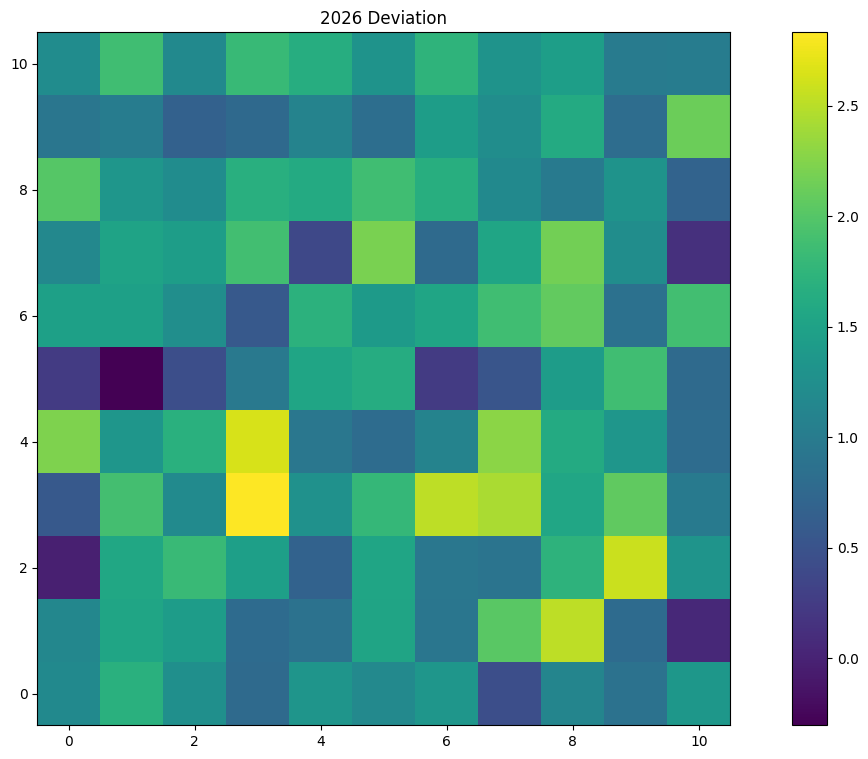

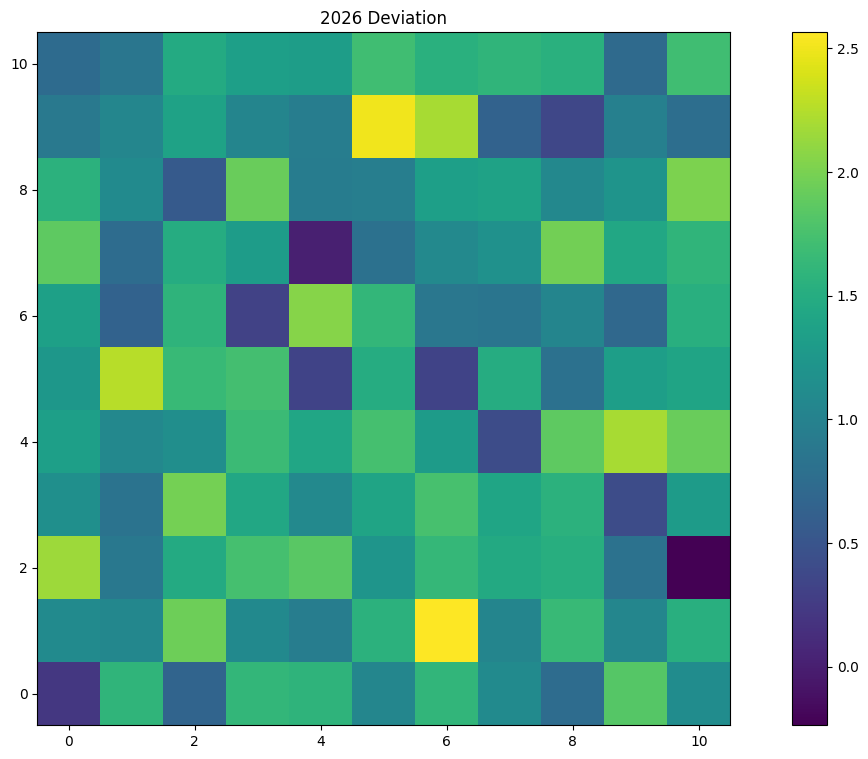

In [8]:
#define the x, y position of the knot
dev_x = [473, round(473 - x_offset)]
dev_y = [1240, round(1240 - y_offset)]
#define the size of the image
size_dev = [5, 5]
i=0
#creates the first image
std_04 = hdu_1_A.data[dev_y[i]-size_dev[i]:dev_y[i]+size_dev[i]+1, dev_x[i]-size_dev[i]:dev_x[i]+size_dev[i]+1]
#this normalizes the data to elimnate the changes in brightness and reduces error
fig, ax = plt.subplots(1, 1, figsize=(16, 9))
plt.imshow(std_04, vmin=np.min(std_04), vmax=np.max(std_04), origin="lower")
plt.colorbar()
title_1 = "2026 Deviation"
ax.set_title(title_1)
std_17 = hdu_2_A.data[dev_y[i+1]-size_dev[i+1]:dev_y[i+1]+size_dev[i+1]+1, dev_x[i+1]-size_dev[i+1]:dev_x[i+1]+size_dev[i+1]+1]
#this normalizes the data to elimnate the changes in brightness and reduces error
fig, ax = plt.subplots(1, 1, figsize=(16, 9))
plt.imshow(std_17, vmin=np.min(std_17), vmax=np.max(std_17), origin="lower")
plt.colorbar()
title_2 = "2026 Deviation"
ax.set_title(title_2)
dev_04 = np.std(std_04)
dev_17 = np.std(std_17)
deviation = np.sqrt(dev_04*dev_17)
print (dev_04, dev_17, deviation)

In [9]:
#this is where the data is stored for processing graphs at the end of calculating all of the knots
velocity_storage_x = []
velocity_storage_y = []
x_error = []
y_error = []
error_bar = []

minimum chi squared value =  139.84026 , X shift =  0.0625682529009132 , Y shift =  0.0759345124977131
Error ± 0.22500000000000003
x error ± 0.22500000000000003 y error ± 0.225
angle = -39.487720206378434
angle error ± 131.0233528615338


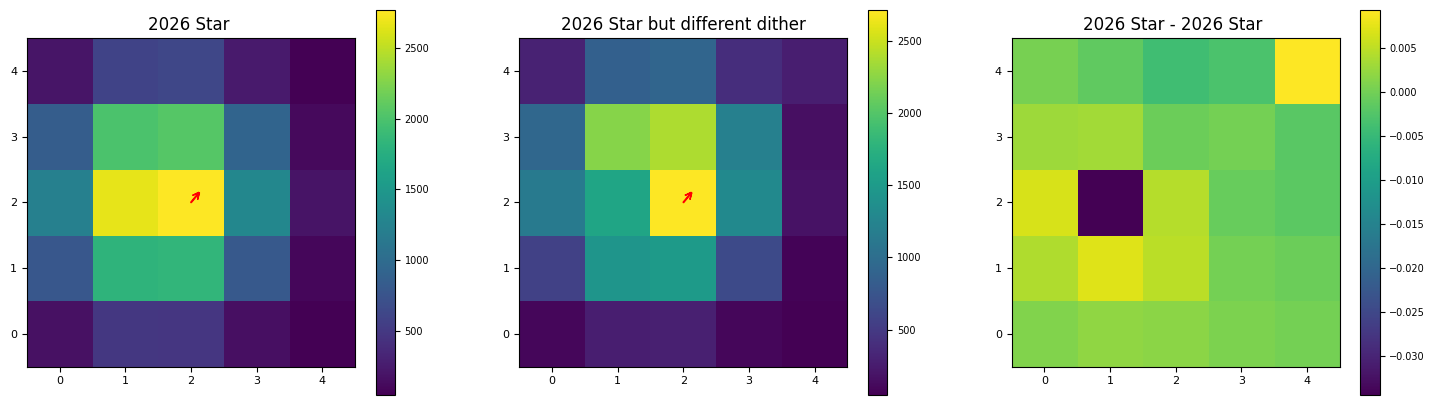

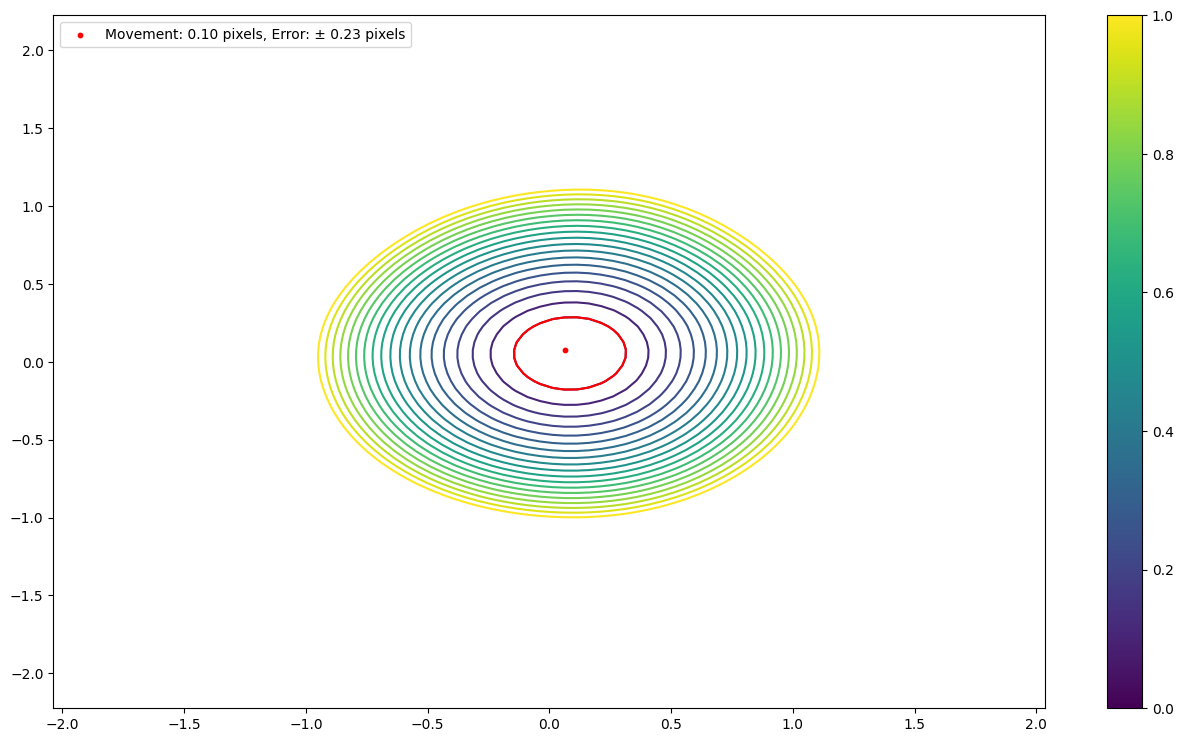

In [10]:
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [185, round(185 - x_offset)+ 1]
cy_chi = [1910, round(1910 - y_offset) -2]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  3.4449646 , X shift =  0.016814410075678354 , Y shift =  -0.0202861671204686
Error ± 0.02499999999999998
x error ± 0.024999999999999994 y error ± 0.024999999999999967
angle = -140.34599346010037
angle error ± 54.36304445422157


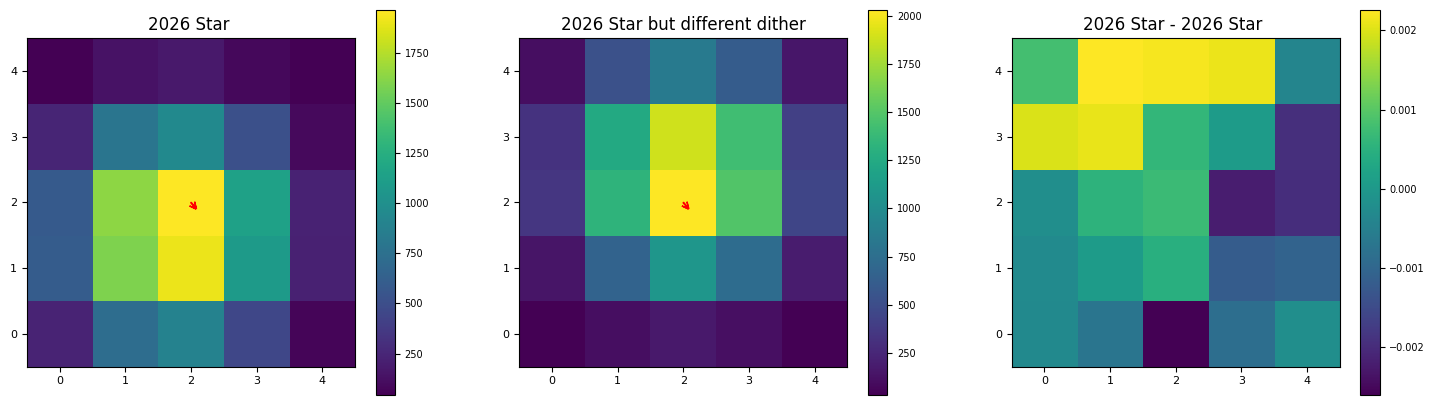

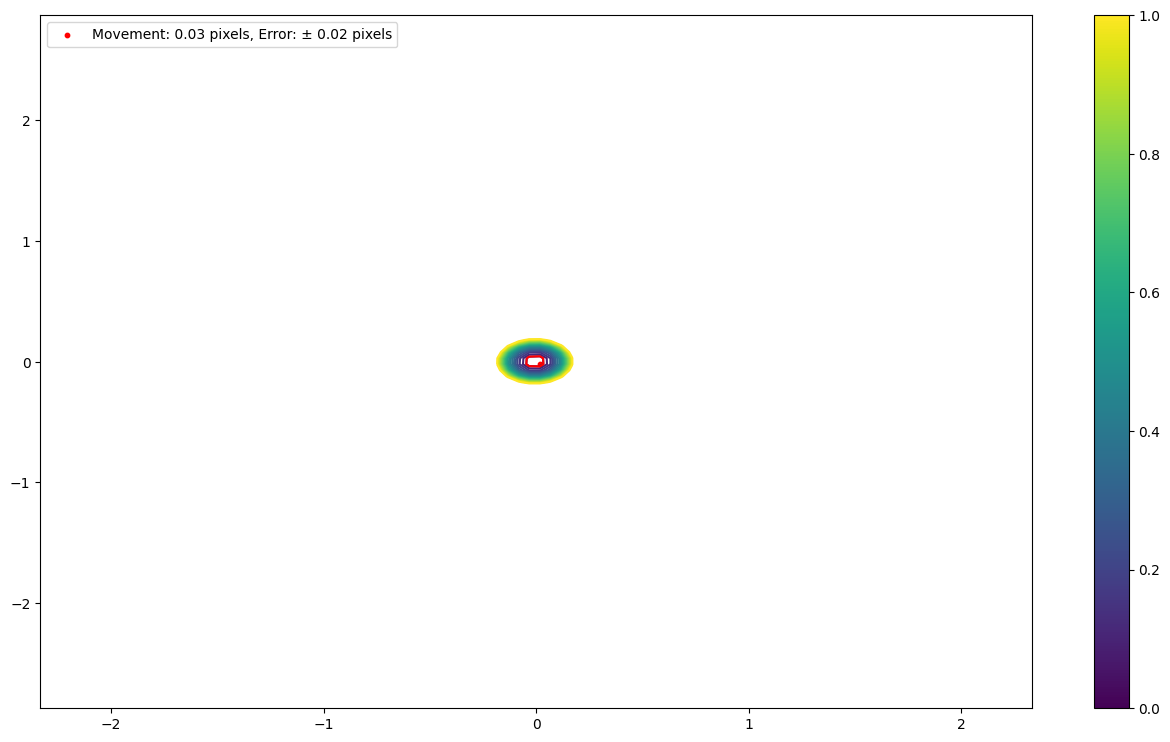

In [11]:
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [1321, round(1321 - x_offset) - 1]
cy_chi = [1753, round(1753 - y_offset) - 2]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  11.27973 , X shift =  0.0002725222935643923 , Y shift =  0.005515695510291518
Error ± 0.04995431808435743
x error ± 0.024999999999999994 y error ± 0.04999999999999999
angle = -2.8285988322230504
angle error ± 260.32361355613307


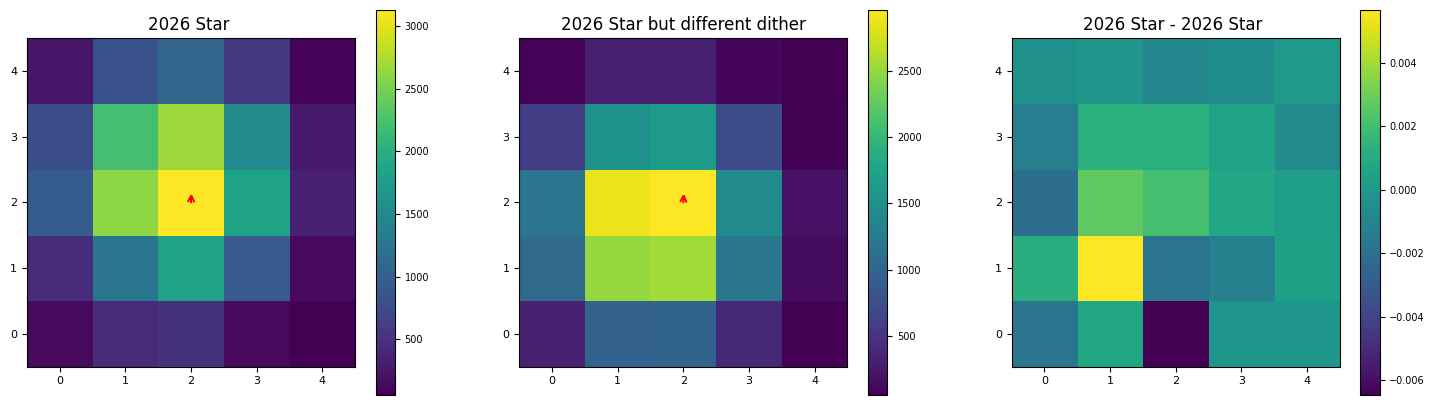

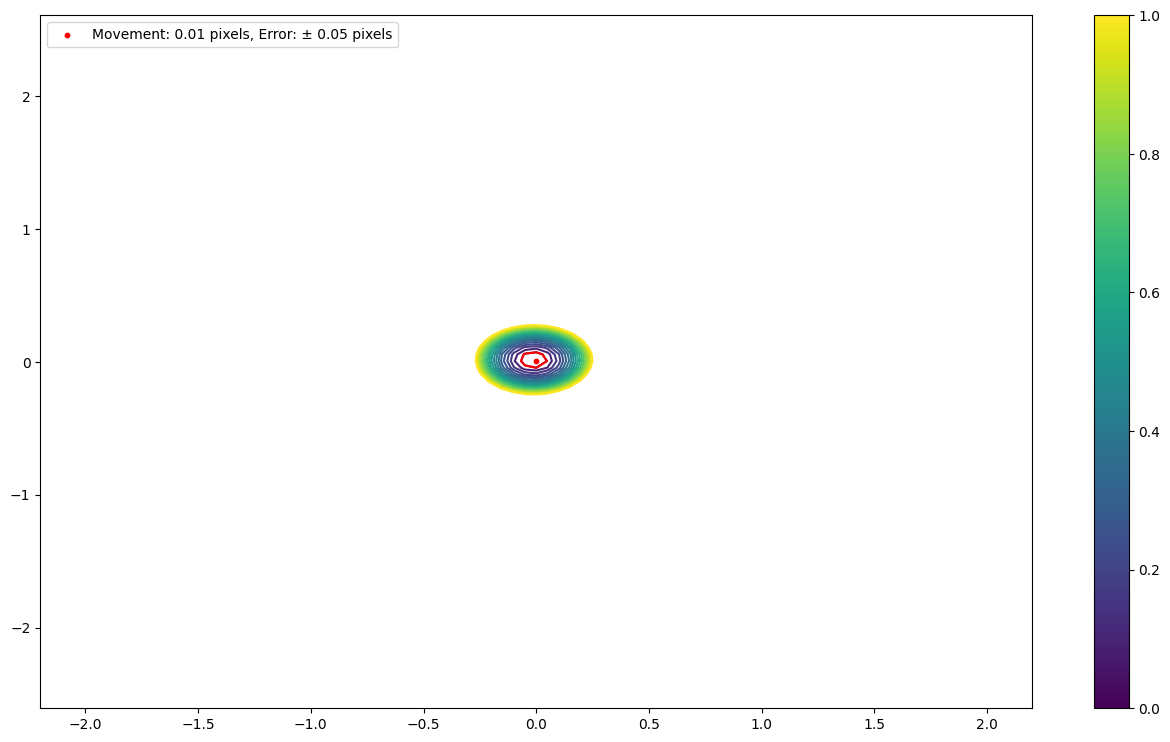

In [12]:
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [1697, round(1697 - x_offset) - 1]
cy_chi = [1091, round(1091 - y_offset) +1]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  0.20884645 , X shift =  0.016612126191650756 , Y shift =  -0.017187616655348847
Error ± 0.039930131324754974
x error ± 0.025000000000000022 y error ± 0.05000000000000002
angle = -135.97545088157307
angle error ± 93.77562417408345


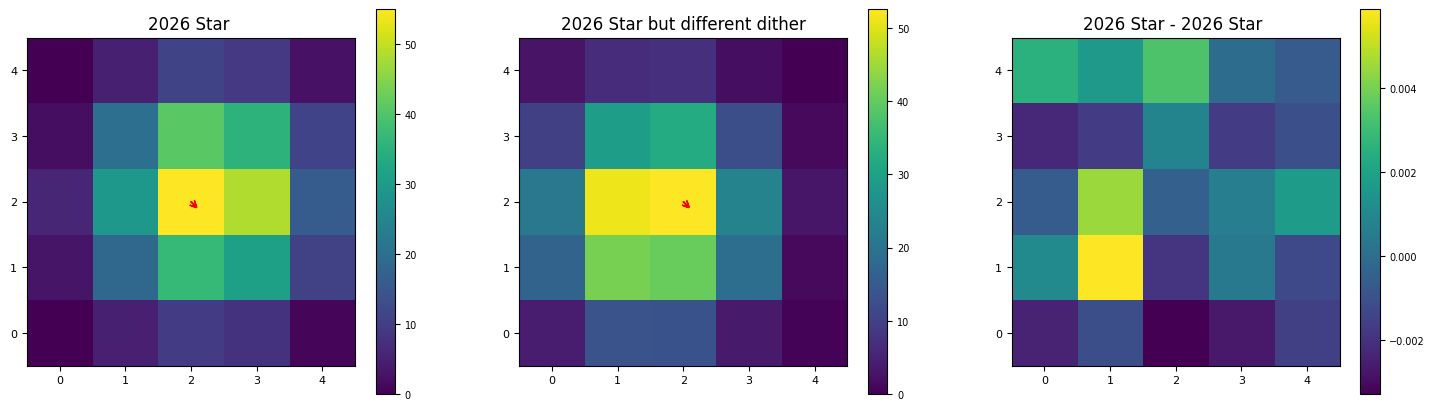

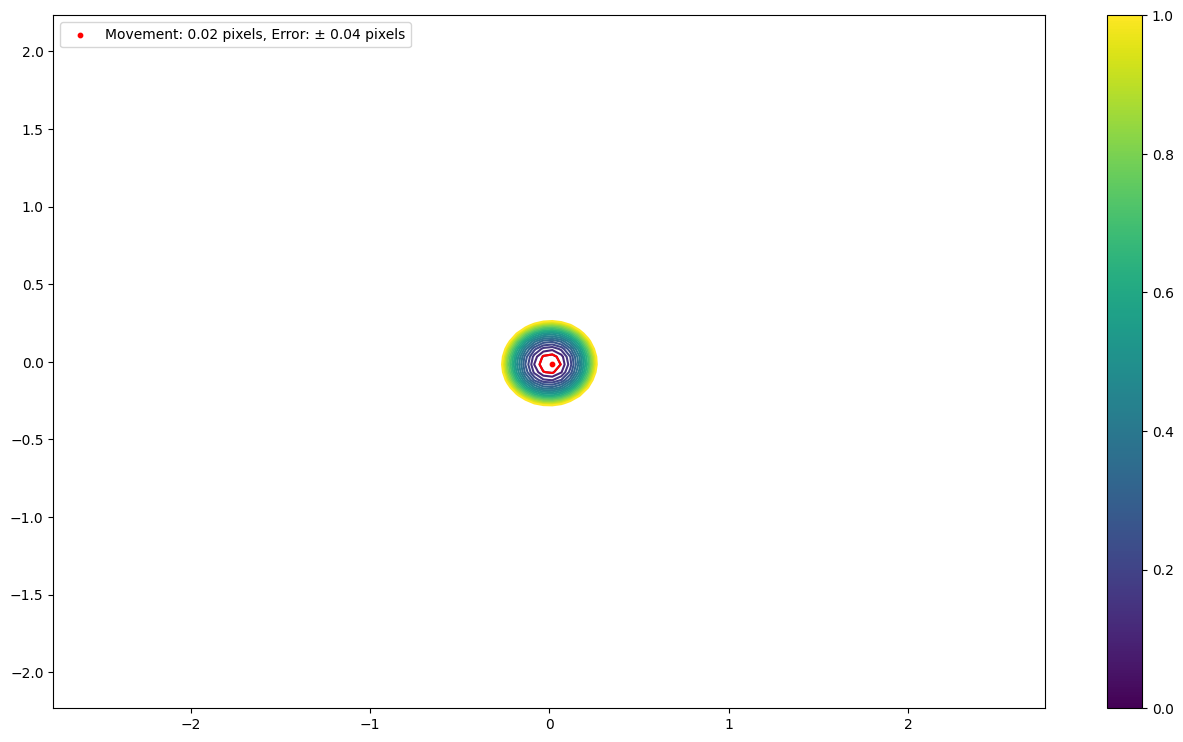

In [13]:
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [1974, round(1974 - x_offset) -1]
cy_chi = [1055, round(1055 - y_offset) +1]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  4.326164 , X shift =  0.03396612919932723 , Y shift =  -0.0432115688637964
Error ± 0.01965482423716325
x error ± 0.0 y error ± 0.025000000000000022
angle = -141.83114836245028
angle error ± 16.105230367191382


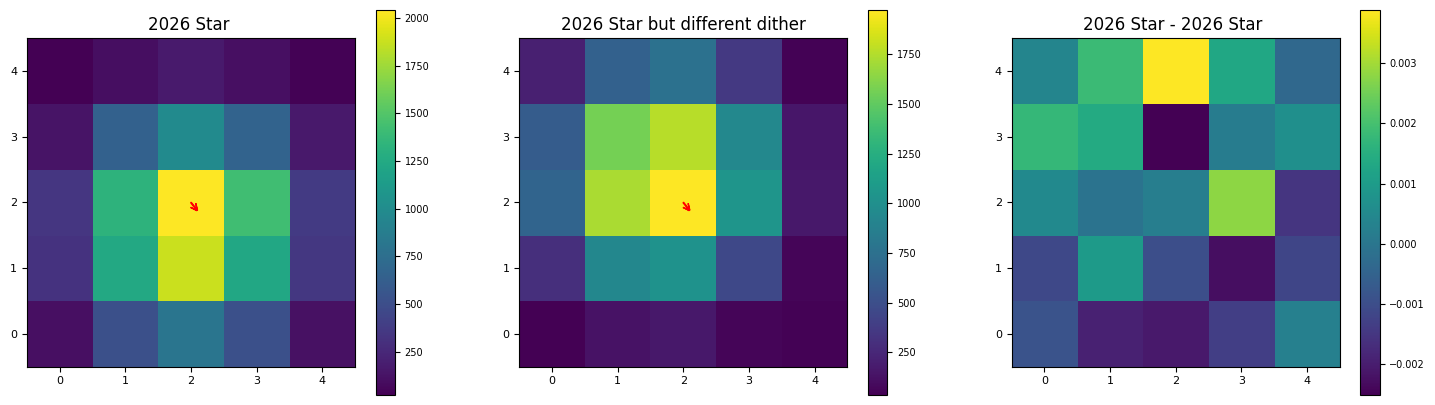

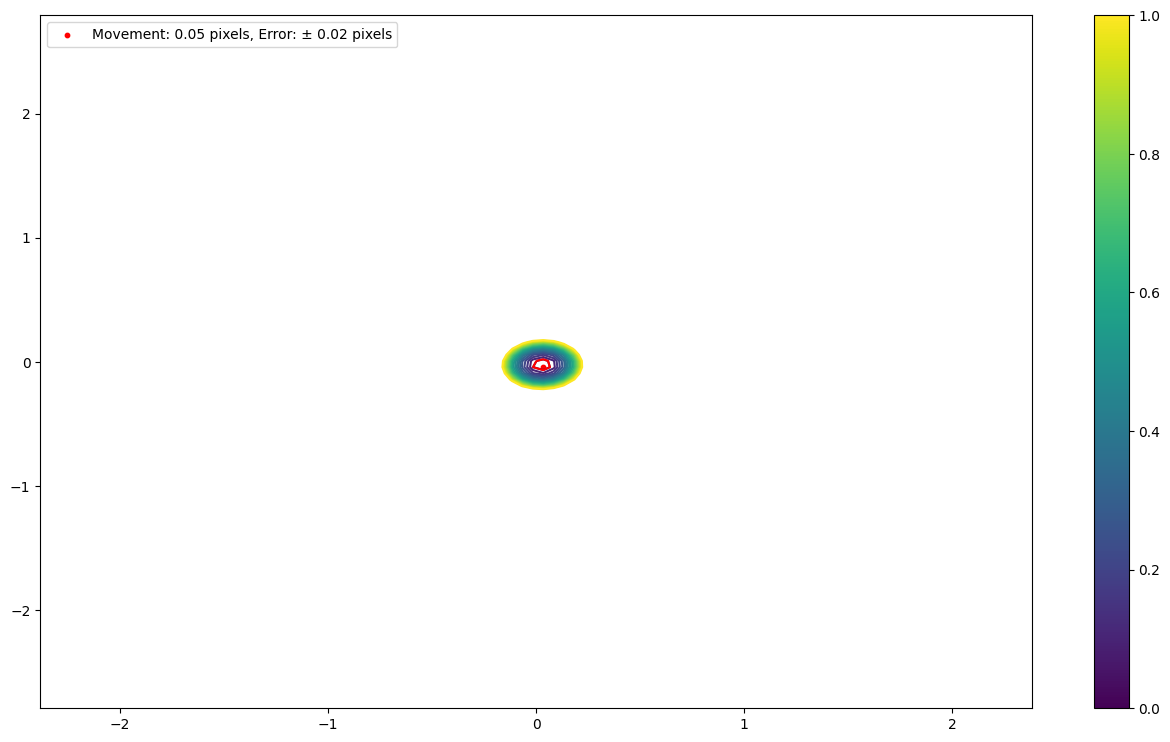

In [14]:
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [1786, round(1786 - x_offset) -1]
cy_chi = [967, round(967 - y_offset)]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  11.334723 , X shift =  0.0029048602405985086 , Y shift =  -0.026358527279228383
Error ± 0.024999999999999994
x error ± 0.025 y error ± 0.024999999999999994
angle = -173.71105630702726
angle error ± 54.015707460598406


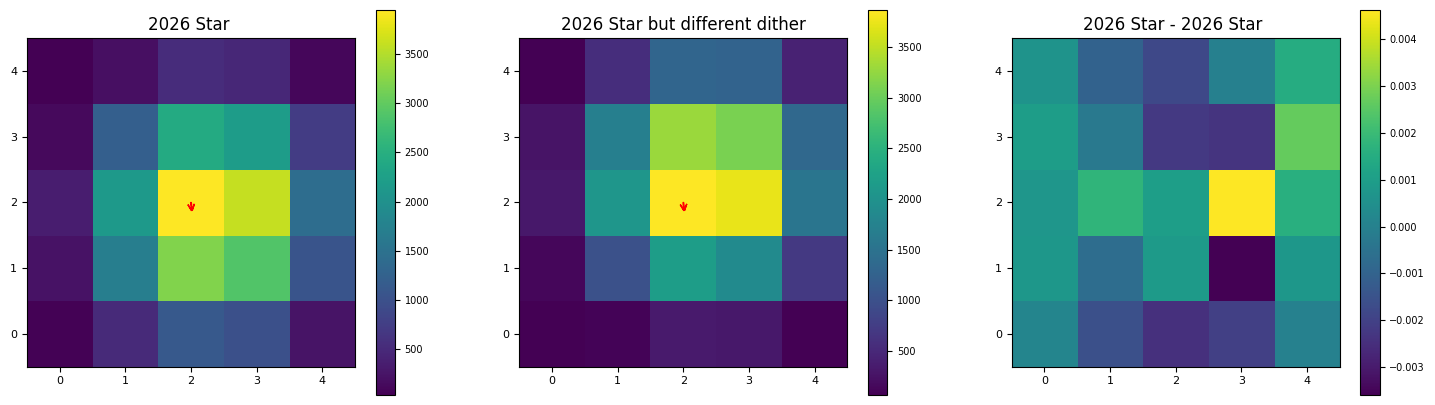

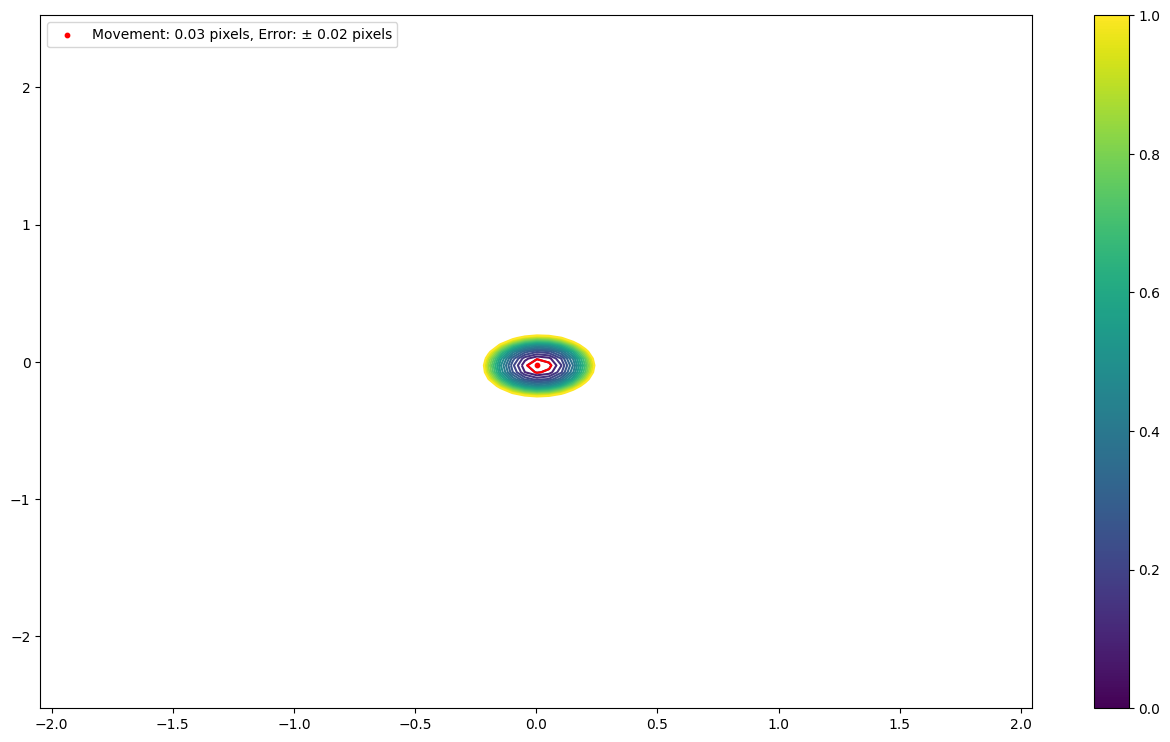

In [15]:
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [682, round(682 - x_offset) +1]
cy_chi = [779, round(779 - y_offset)]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  15.143006 , X shift =  0.003314471237901892 , Y shift =  -0.015143878902506458
Error ± 0.051408667521383365
x error ± 0.07500000000000001 y error ± 0.05000000000000002
angle = -167.65460243466305
angle error ± 273.65322427392914


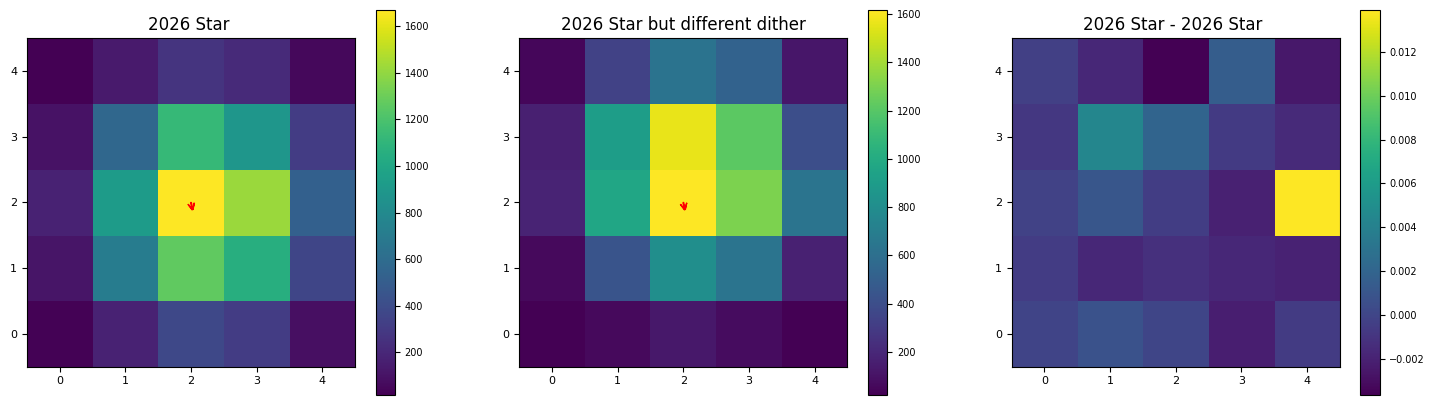

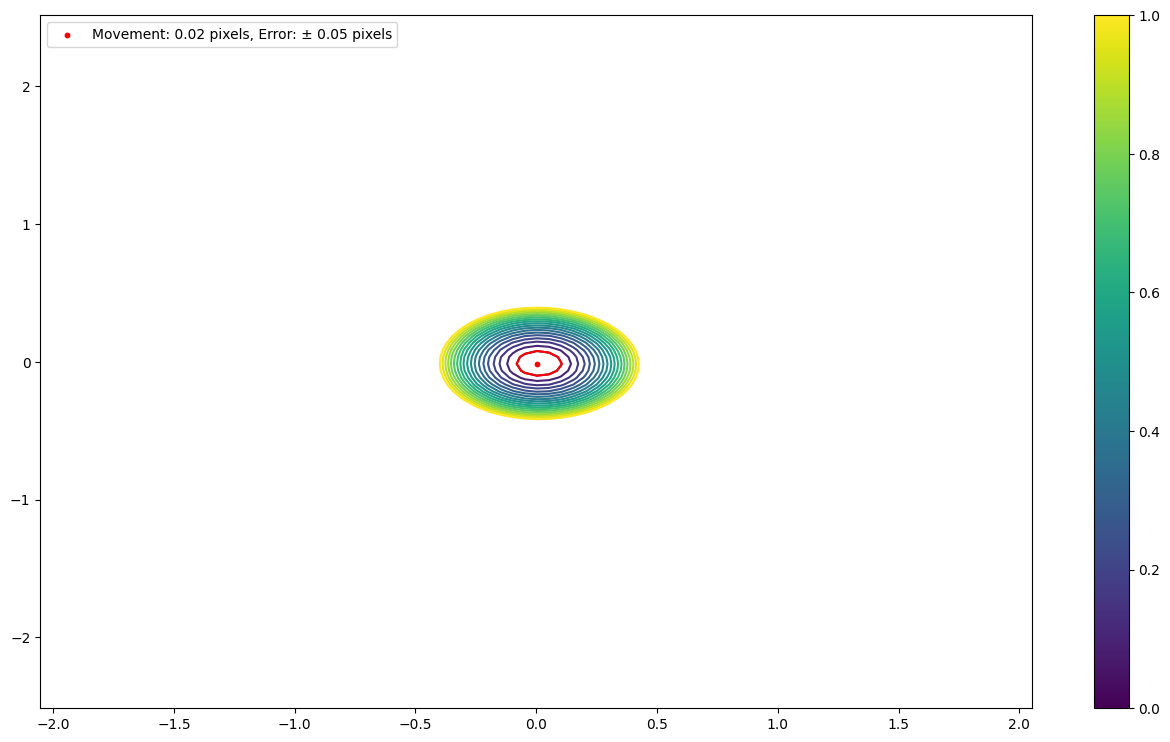

In [16]:
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [1170, round(1170 - x_offset) ]
cy_chi = [875, round(875 - y_offset)]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  87.594406 , X shift =  -0.03479935407346568 , Y shift =  0.02951279948227925
Error ± 0.06170368273992008
x error ± 0.04999999999999999 y error ± 0.07500000000000004
angle = 49.69923285223996
angle error ± 82.50993141345123


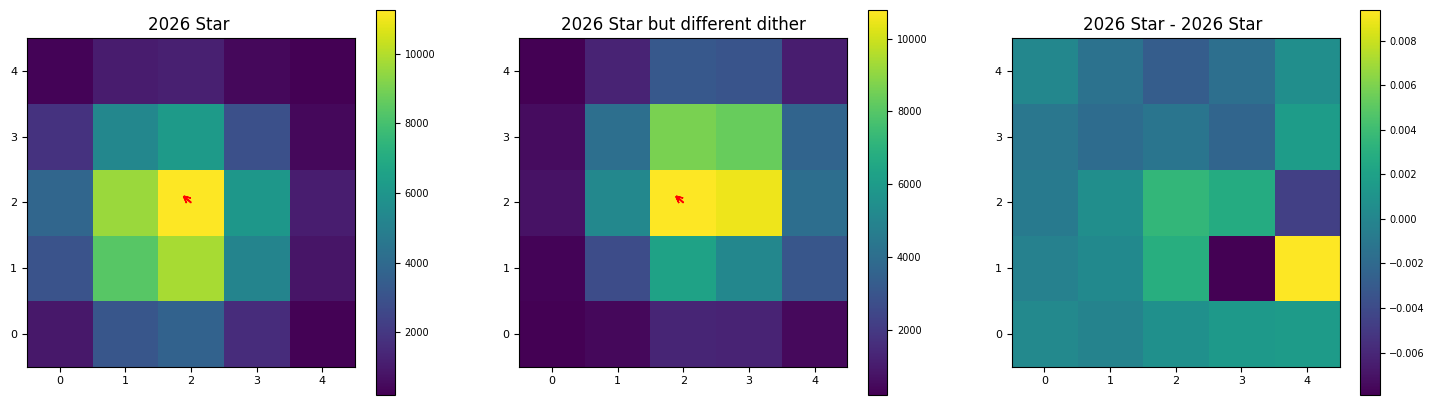

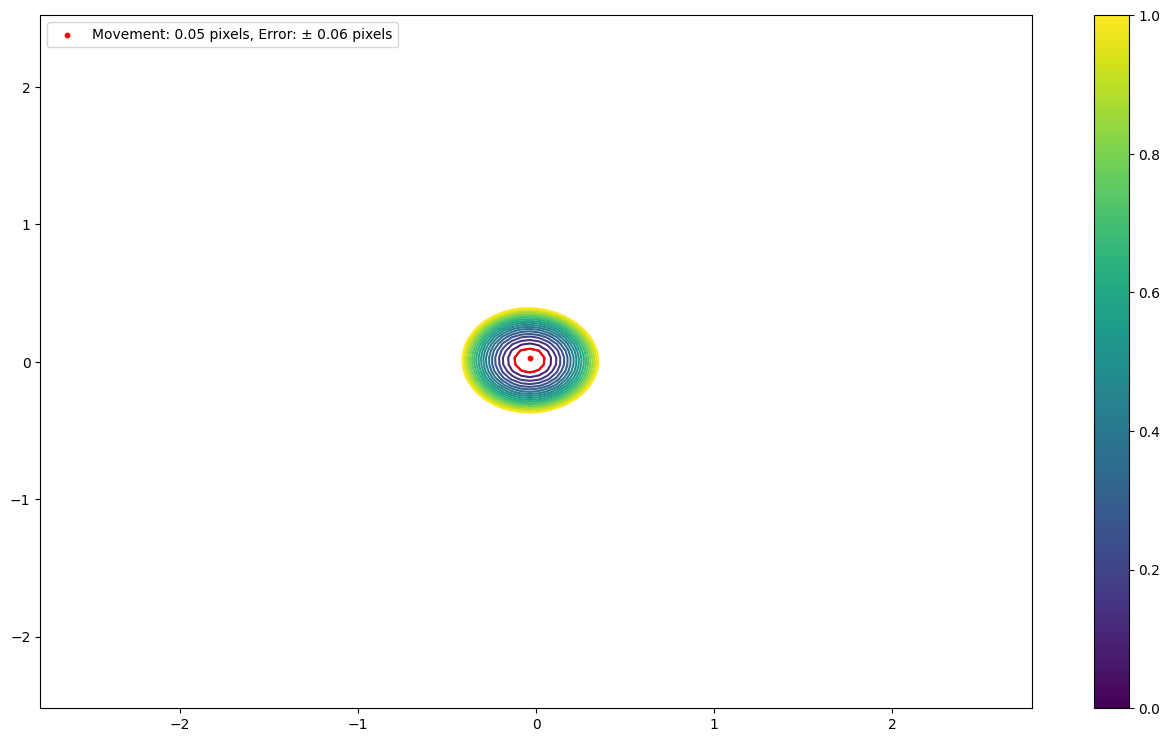

In [17]:
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [51, round(51 - x_offset) +2]
cy_chi = [431, round(431 - y_offset)+1]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  8.831494 , X shift =  -0.01495162420286611 , Y shift =  0.005663554819238914
Error ± 0.02500000000000002
x error ± 0.025000000000000022 y error ± 0.024999999999999994
angle = 69.25371595911237
angle error ± 89.58996106447174


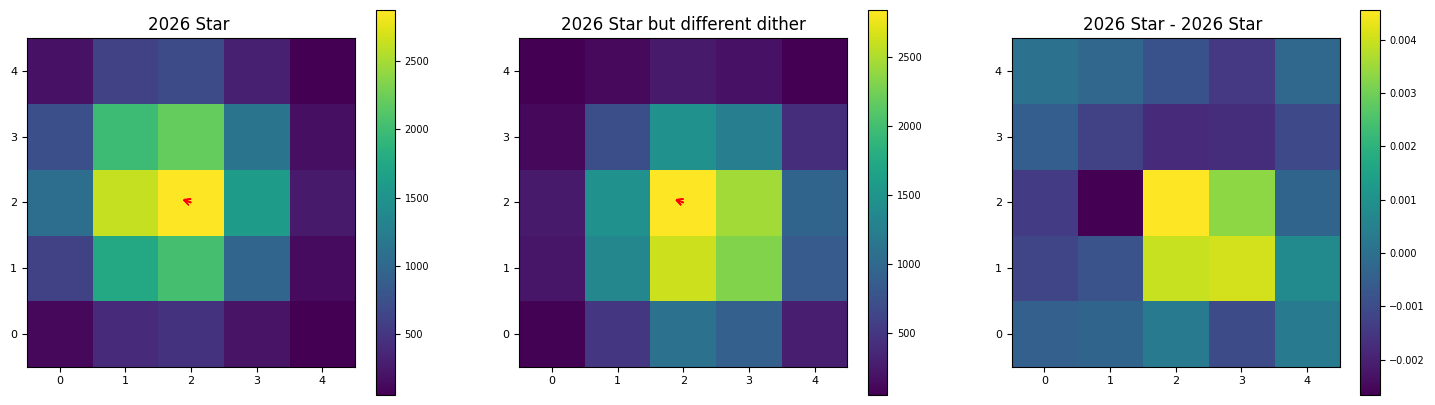

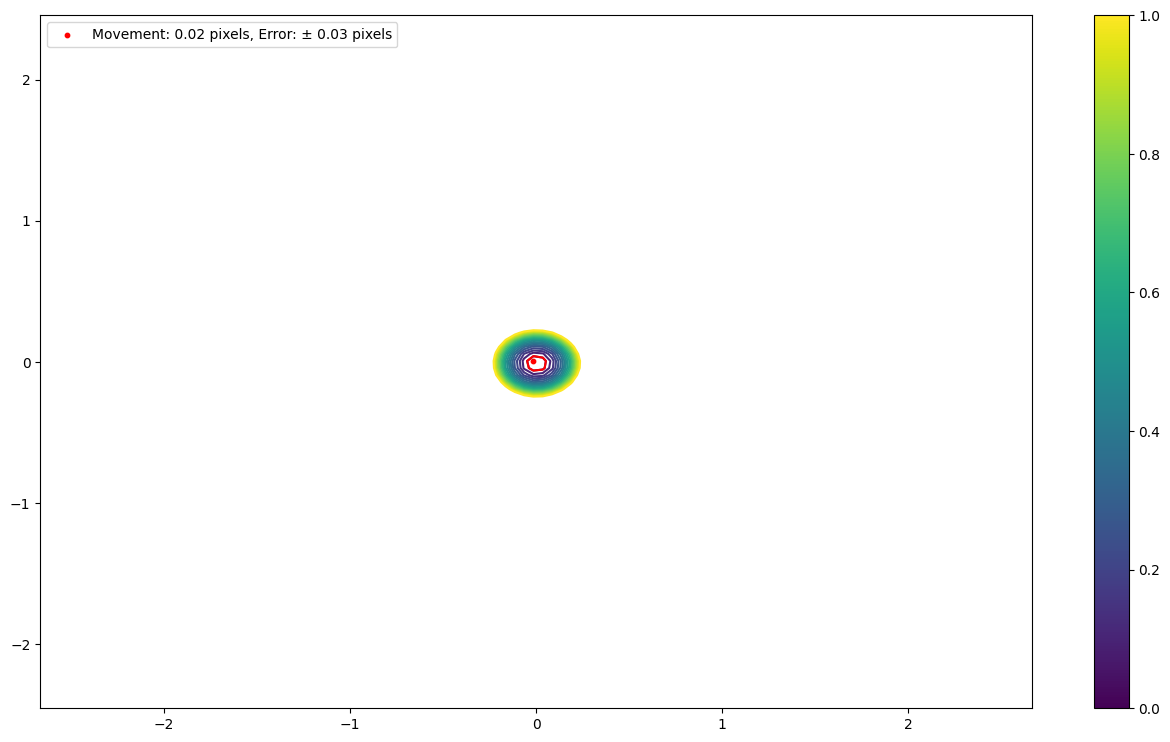

In [18]:
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [98, round(98 - x_offset) +2]
cy_chi = [421, round(421 - y_offset)+2]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  0.29635862 , X shift =  0.014563555197255273 , Y shift =  -0.0228334507000284
Error ± 0.04424706202897828
x error ± 0.02500000000000001 y error ± 0.04999999999999999
angle = -147.46959089594995
angle error ± 72.277899192175


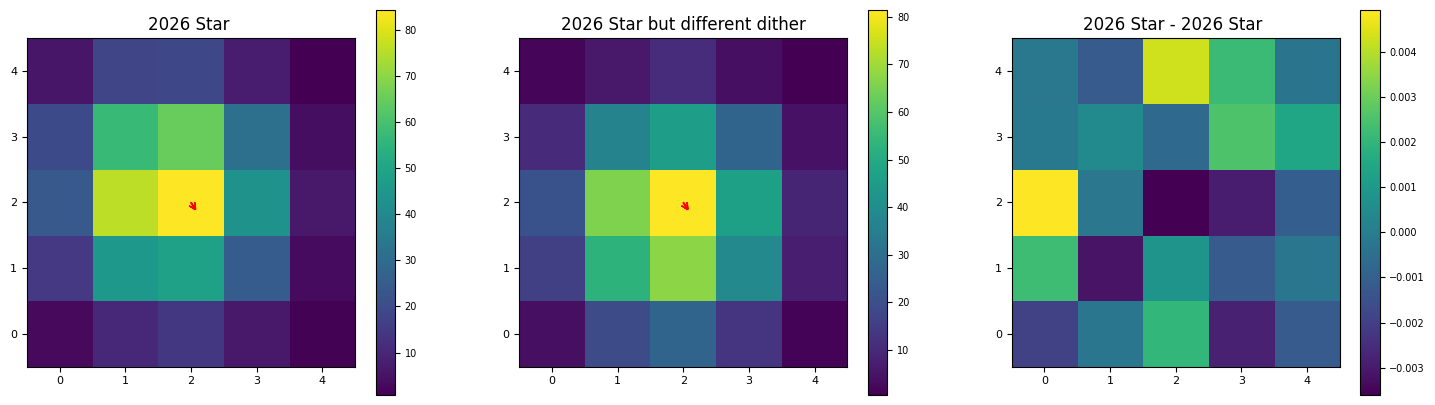

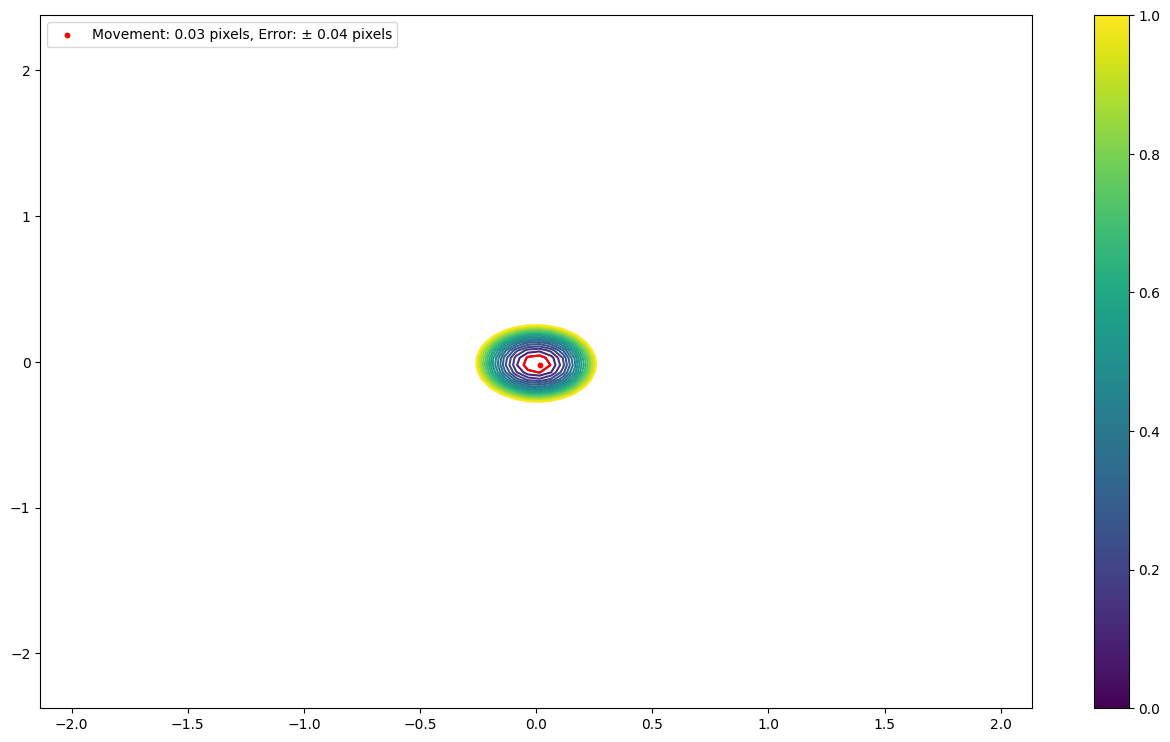

In [19]:
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [324, round(324 - x_offset) +2]
cy_chi = [404, round(404 - y_offset)+2]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  1.0796586 , X shift =  -0.02086775629374893 , Y shift =  -0.012475788104615027
Error ± 0.08232244494323769
x error ± 0.07500000000000001 y error ± 0.09999999999999998
angle = 120.87309273254901
angle error ± 221.67256238772694


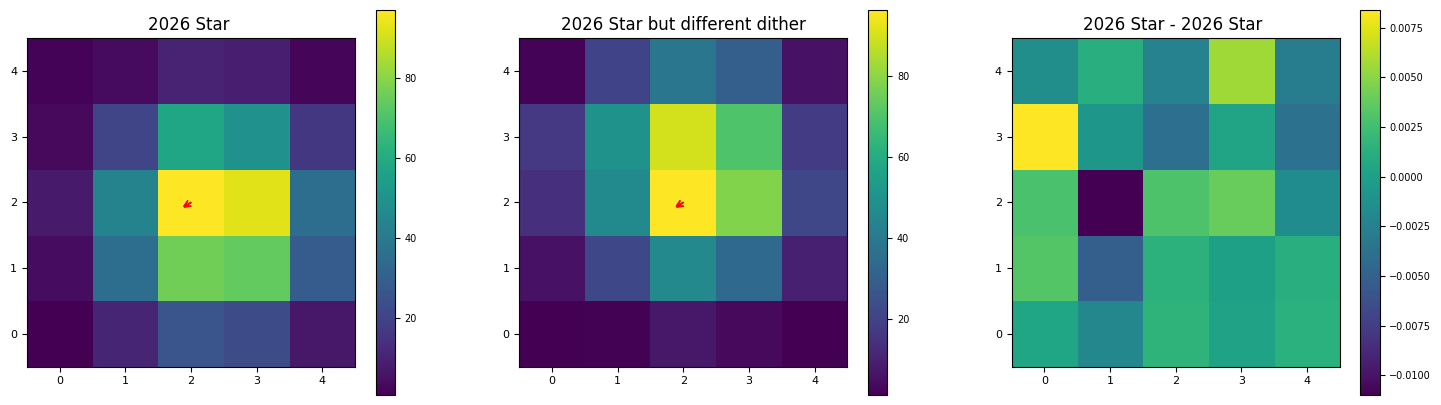

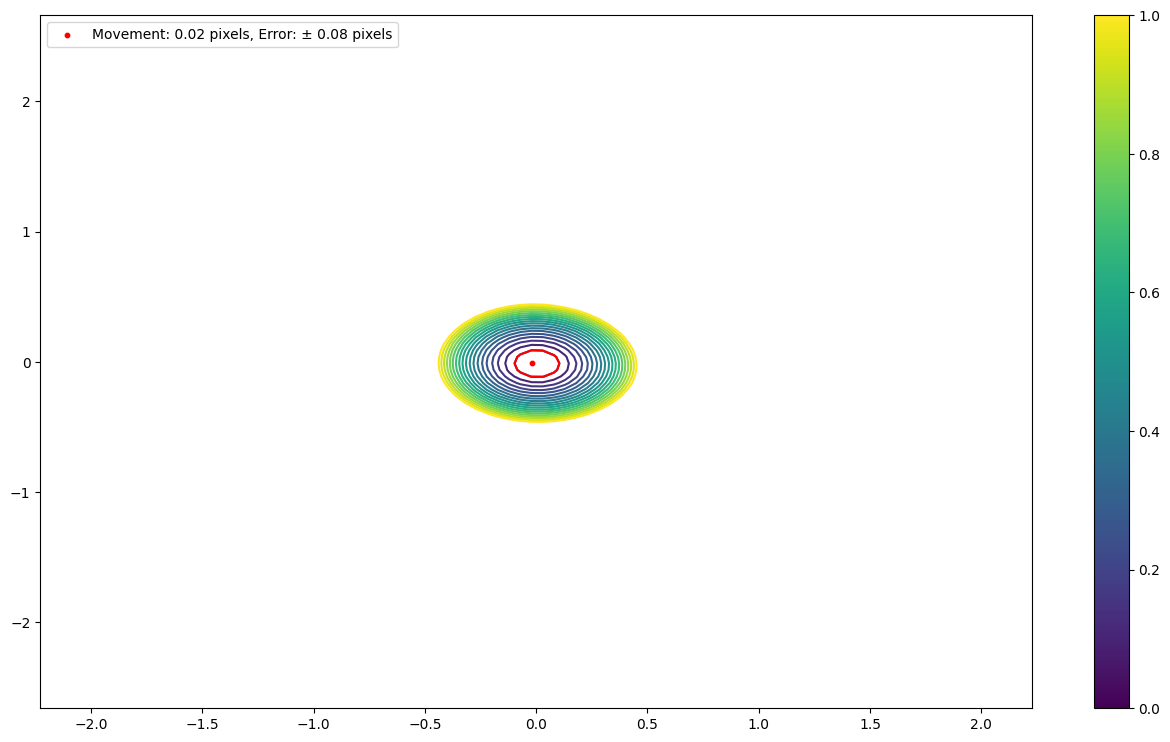

In [20]:
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [480, round(480 - x_offset) +2]
cy_chi = [405, round(405 - y_offset)+1]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  1.8998163 , X shift =  -0.03843673765445396 , Y shift =  0.02655932930633753
Error ± 0.025000000000000012
x error ± 0.02500000000000001 y error ± 0.025000000000000022
angle = 55.35598742507036
angle error ± 30.65897145520611


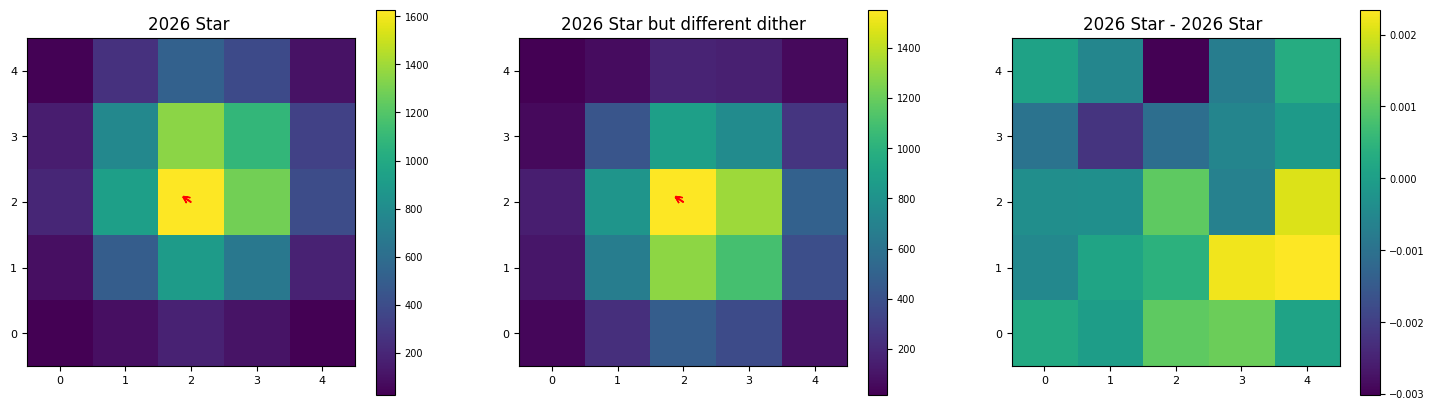

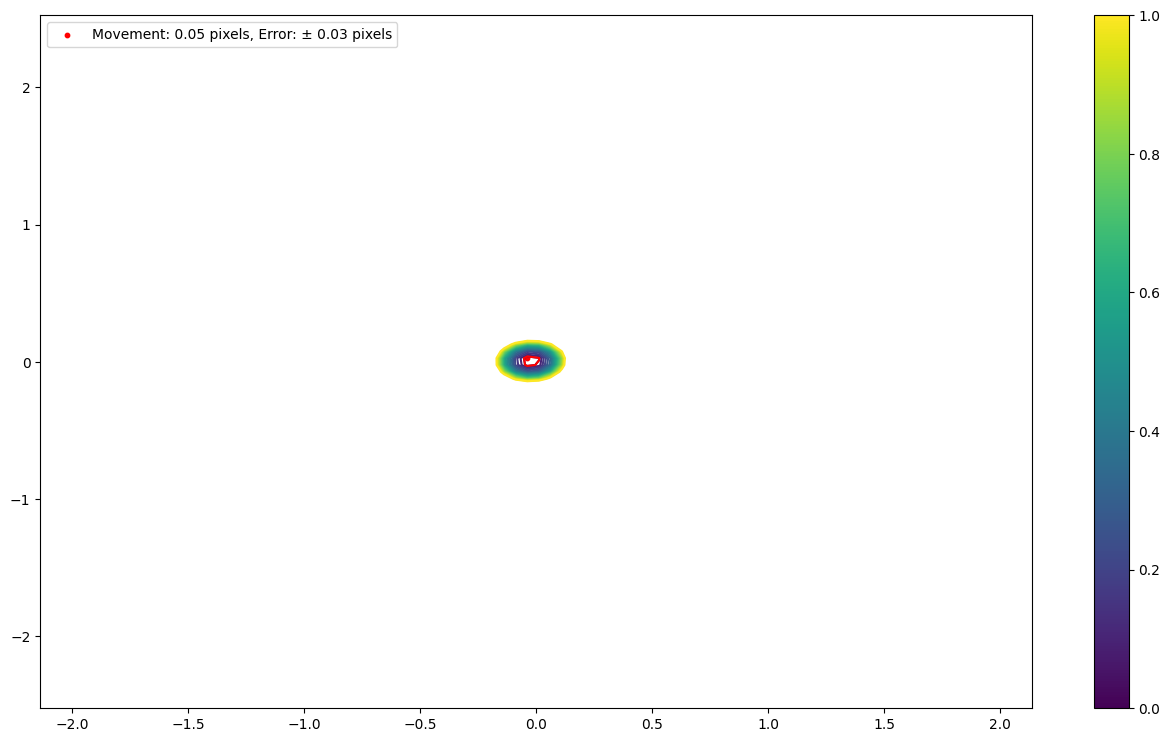

In [21]:
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [2010, round(2010 - x_offset)-2]
cy_chi = [482, round(482 - y_offset)+3]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

In [22]:
velocity_storage_x_dither_1_2 = velocity_storage_x
velocity_storage_y_dither_1_2 = velocity_storage_y
x_error_dither_1_2 = x_error
y_error_dither_1_2 = y_error
error_bar_dither_1_2 = error_bar

# **Dither 1 to Dither 3**

In [23]:
hdu_1_A = fits.open((path_image_2 + 'nan_rm_jwst_2026_f444w_f470n_d1_frame_A.fits'))[1]
hdu_2_A = fits.open((path_image_2 + 'nan_rm_jwst_2026_f444w_f470n_d3_frame_A.fits'))[1]

In [24]:
x_offset = -388.6176458155897
y_offset  = 83.4196445952572

0.5823348 0.49426225 0.5364943


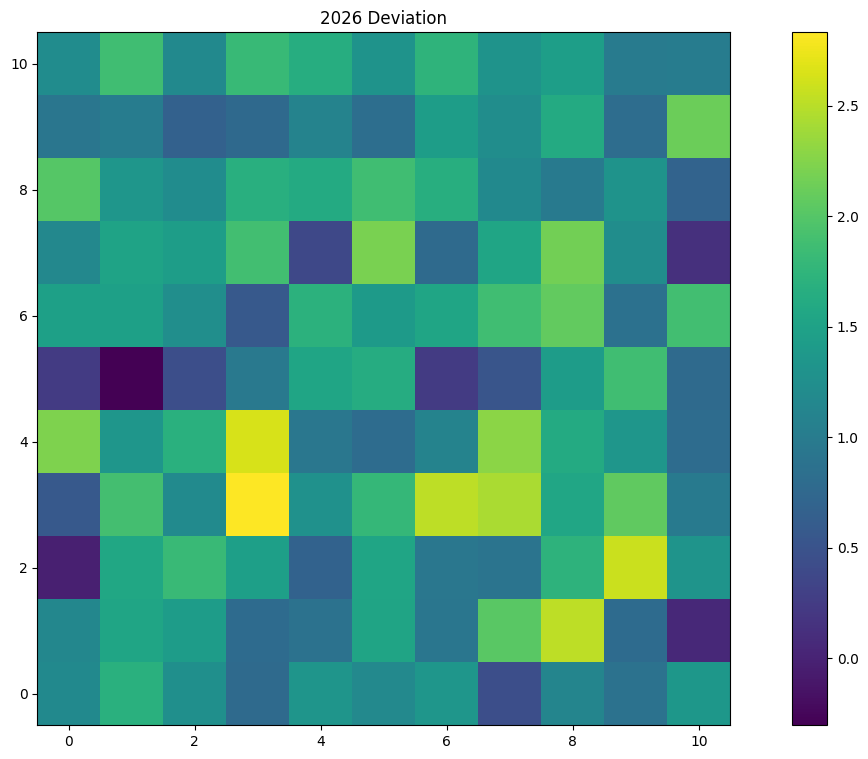

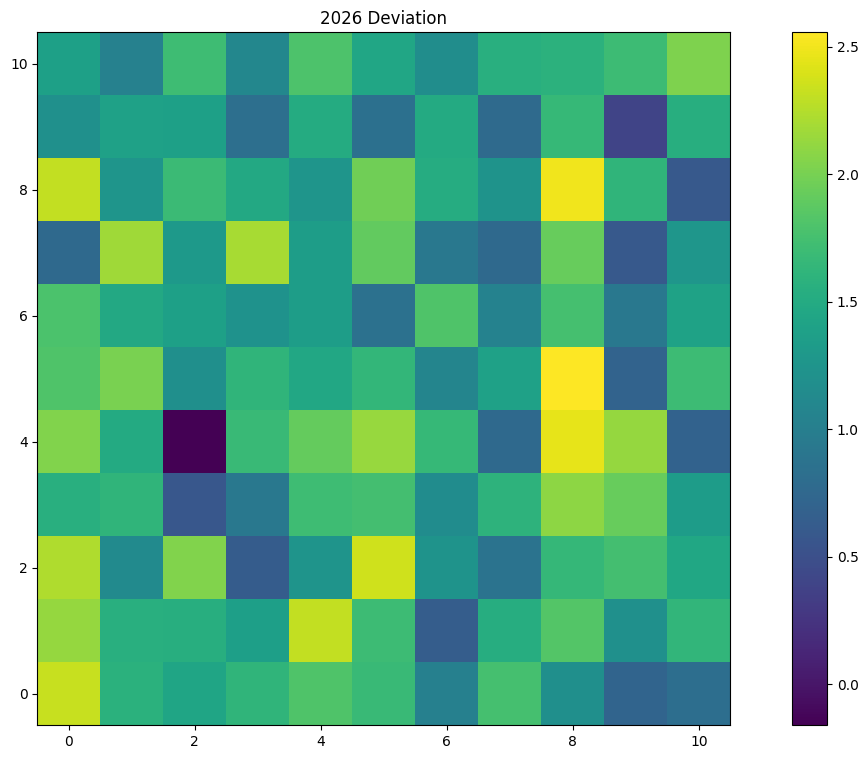

In [25]:
#define the x, y position of the knot
dev_x = [473, round(473 - x_offset)]
dev_y = [1240, round(1240 - y_offset)]
#define the size of the image
size_dev = [5, 5]
i=0
#creates the first image
std_04 = hdu_1_A.data[dev_y[i]-size_dev[i]:dev_y[i]+size_dev[i]+1, dev_x[i]-size_dev[i]:dev_x[i]+size_dev[i]+1]
#this normalizes the data to elimnate the changes in brightness and reduces error
fig, ax = plt.subplots(1, 1, figsize=(16, 9))
plt.imshow(std_04, vmin=np.min(std_04), vmax=np.max(std_04), origin="lower")
plt.colorbar()
title_1 = "2026 Deviation"
ax.set_title(title_1)
std_17 = hdu_2_A.data[dev_y[i+1]-size_dev[i+1]:dev_y[i+1]+size_dev[i+1]+1, dev_x[i+1]-size_dev[i+1]:dev_x[i+1]+size_dev[i+1]+1]
#this normalizes the data to elimnate the changes in brightness and reduces error
fig, ax = plt.subplots(1, 1, figsize=(16, 9))
plt.imshow(std_17, vmin=np.min(std_17), vmax=np.max(std_17), origin="lower")
plt.colorbar()
title_2 = "2026 Deviation"
ax.set_title(title_2)
dev_04 = np.std(std_04)
dev_17 = np.std(std_17)
deviation = np.sqrt(dev_04*dev_17)
print (dev_04, dev_17, deviation)

In [26]:
#this is where the data is stored for processing graphs at the end of calculating all of the knots
velocity_storage_x = []
velocity_storage_y = []
x_error = []
y_error = []
error_bar = []

minimum chi squared value =  4.2591357 , X shift =  -0.00851179148437492 , Y shift =  0.00803273905852675
Error ± 0.024999999999999994
x error ± 0.024999999999999994 y error ± 0.024999999999999994
angle = 46.65855508169892
angle error ± 122.38866795169187


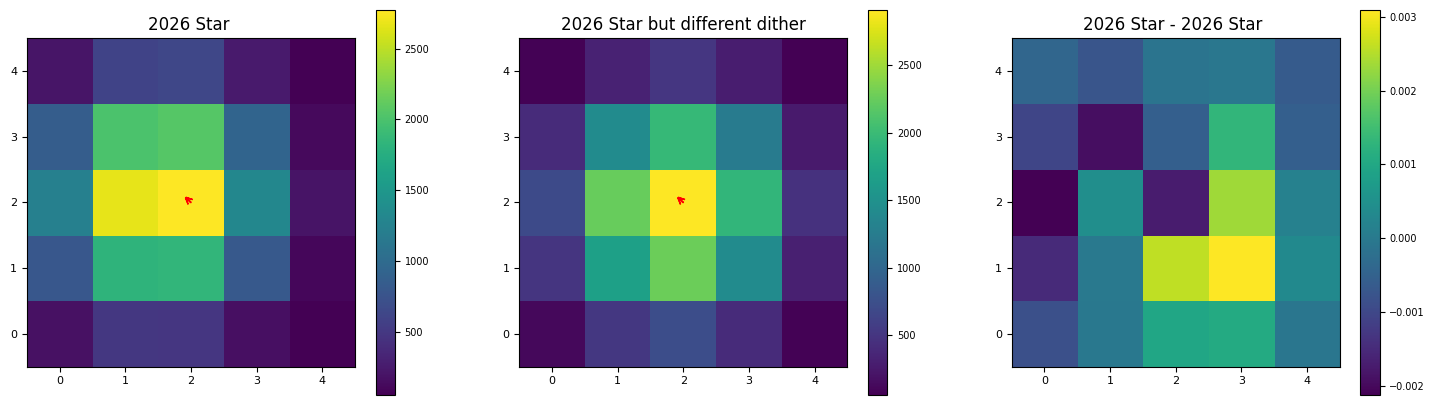

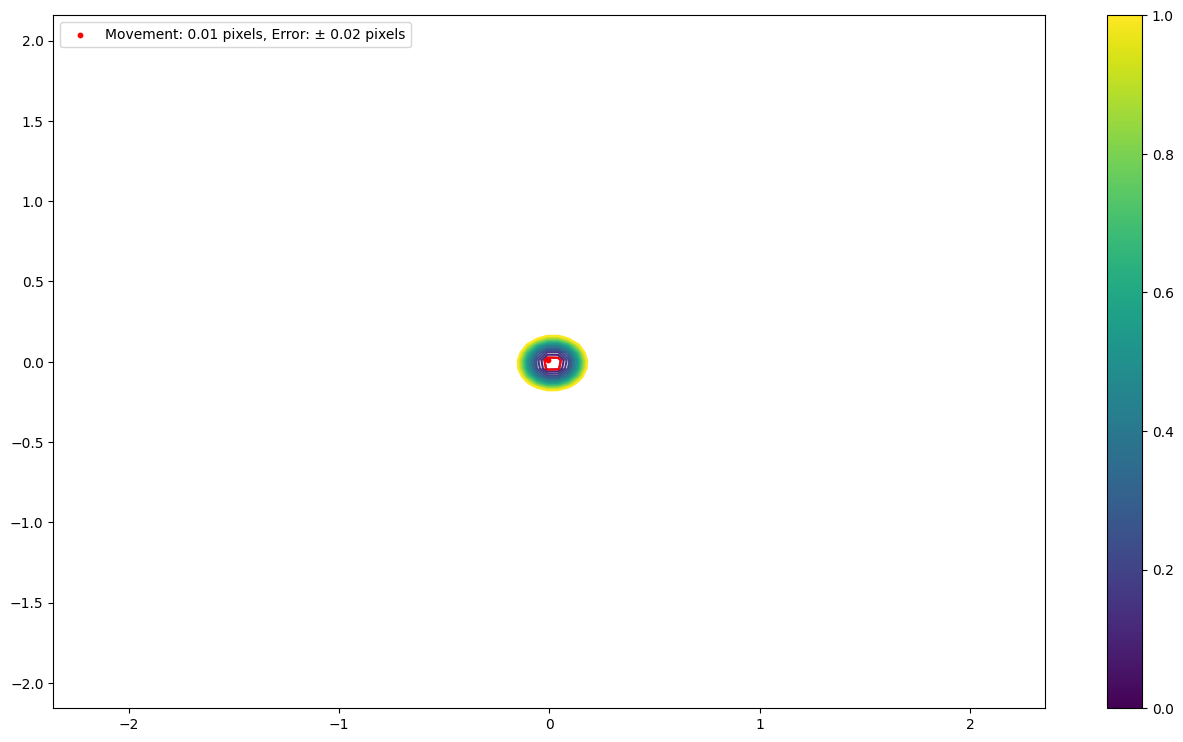

In [27]:
#1
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [185, round(185 - x_offset) +3]
cy_chi = [1910, round(1910 - y_offset) +1]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 3
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  2.4202008 , X shift =  0.02416054005456092 , Y shift =  0.009895863815054917
Error ± 0.024999999999999967
x error ± 0.024999999999999967 y error ± 0.024999999999999967
angle = -67.72658956591434
angle error ± 54.86290432055567


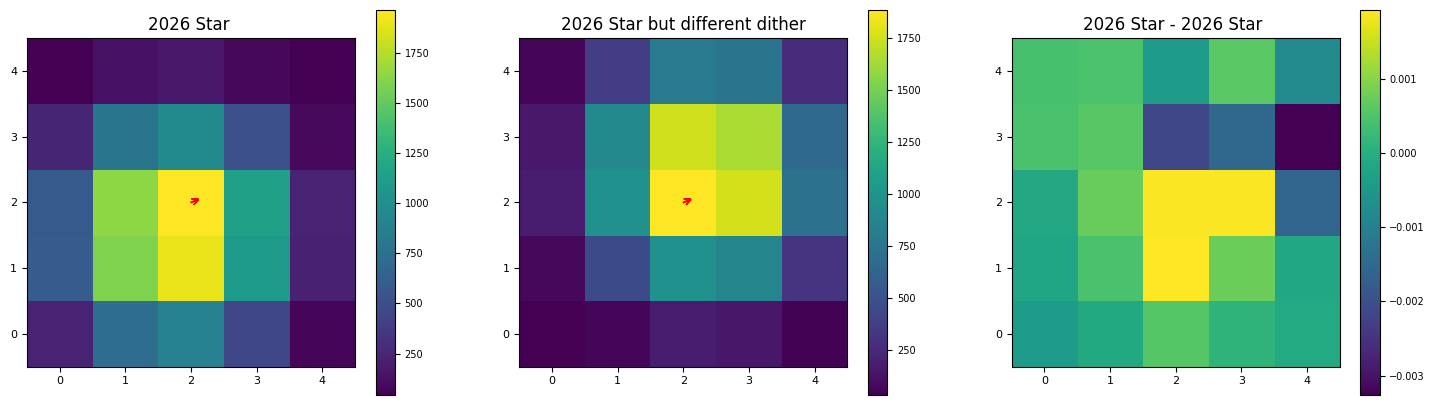

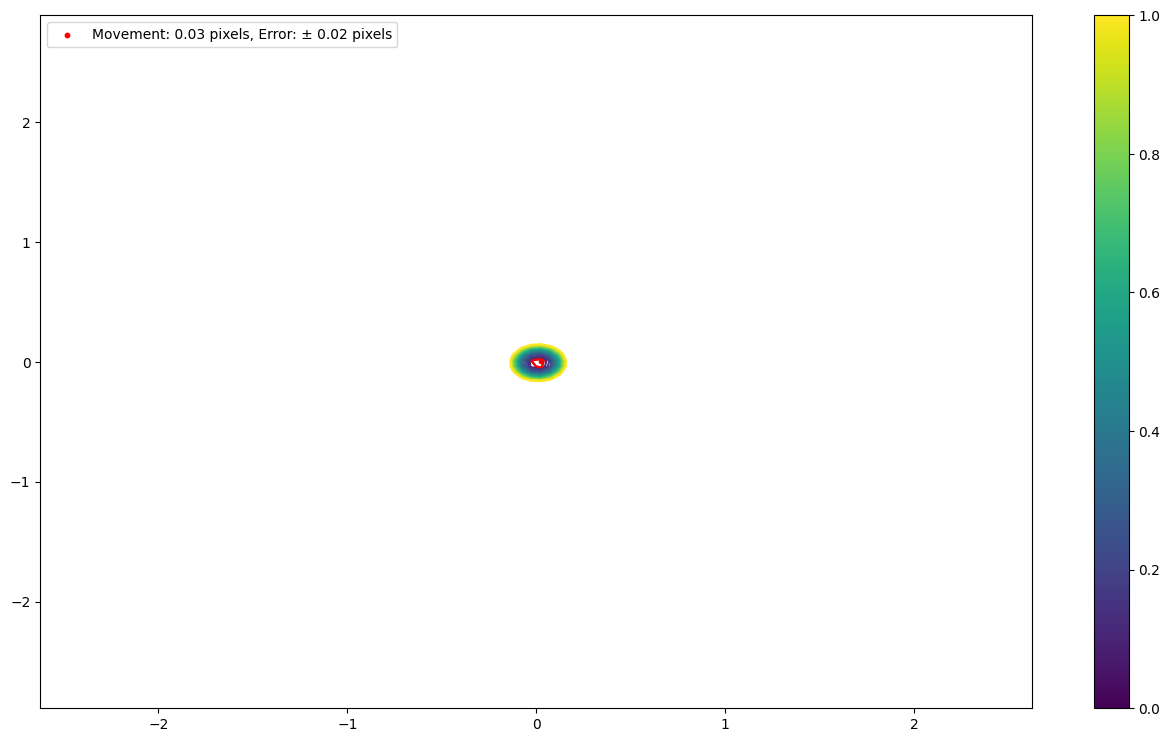

In [28]:
#2
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [1321, round(1321 - x_offset) ]
cy_chi = [1753, round(1753 - y_offset) -5]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

In [29]:
#3
# plt.rcParams['figure.max_open_warning'] = 200
# #define the x, y position of the knot
# cx_chi = [1697, round(1697 - x_offset) - 1]
# cy_chi = [1091, round(1091 - y_offset) +1]
# #define the size of the image
# size_chi = [2, 2]
# #how much bigger the median subtraction is from the image size
# median_factor = 2
# #sets how much each chi is offset by. should be kept small to increase how accurate it is 
# shift_amount = .05
# #sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
# width = 40
# height = 40
# direction = 1
# chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

In [30]:
# #4
# plt.rcParams['figure.max_open_warning'] = 200
# #define the x, y position of the knot
# cx_chi = [1974, round(1974 - x_offset) -1]
# cy_chi = [1055, round(1055 - y_offset) +1]
# #define the size of the image
# size_chi = [2, 2]
# #how much bigger the median subtraction is from the image size
# median_factor = 2
# #sets how much each chi is offset by. should be kept small to increase how accurate it is 
# shift_amount = .05
# #sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
# width = 40
# height = 40
# direction = 1
# chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

In [31]:
# #5
# plt.rcParams['figure.max_open_warning'] = 200
# #define the x, y position of the knot
# cx_chi = [1786, round(1786 - x_offset) -1]
# cy_chi = [967, round(967 - y_offset)]
# #define the size of the image
# size_chi = [2, 2]
# #how much bigger the median subtraction is from the image size
# median_factor = 2
# #sets how much each chi is offset by. should be kept small to increase how accurate it is 
# shift_amount = .05
# #sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
# width = 40
# height = 40
# direction = 1
# chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  16.285547 , X shift =  -0.005204583701049648 , Y shift =  -0.021401476170976208
Error ± 0.048941837699400255
x error ± 0.024999999999999994 y error ± 0.050000000000000044
angle = 166.33167746862588
angle error ± 70.27053596330619


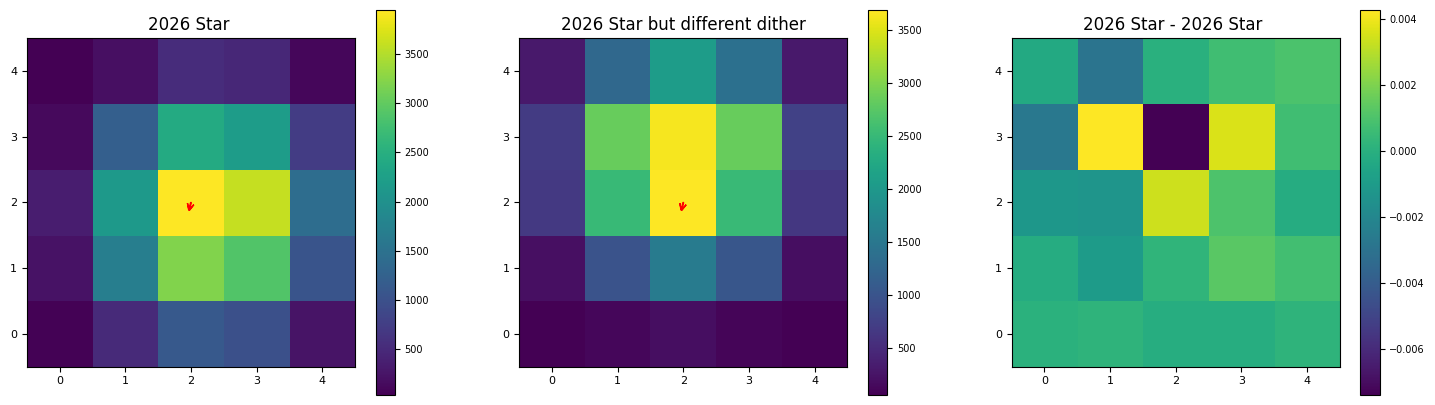

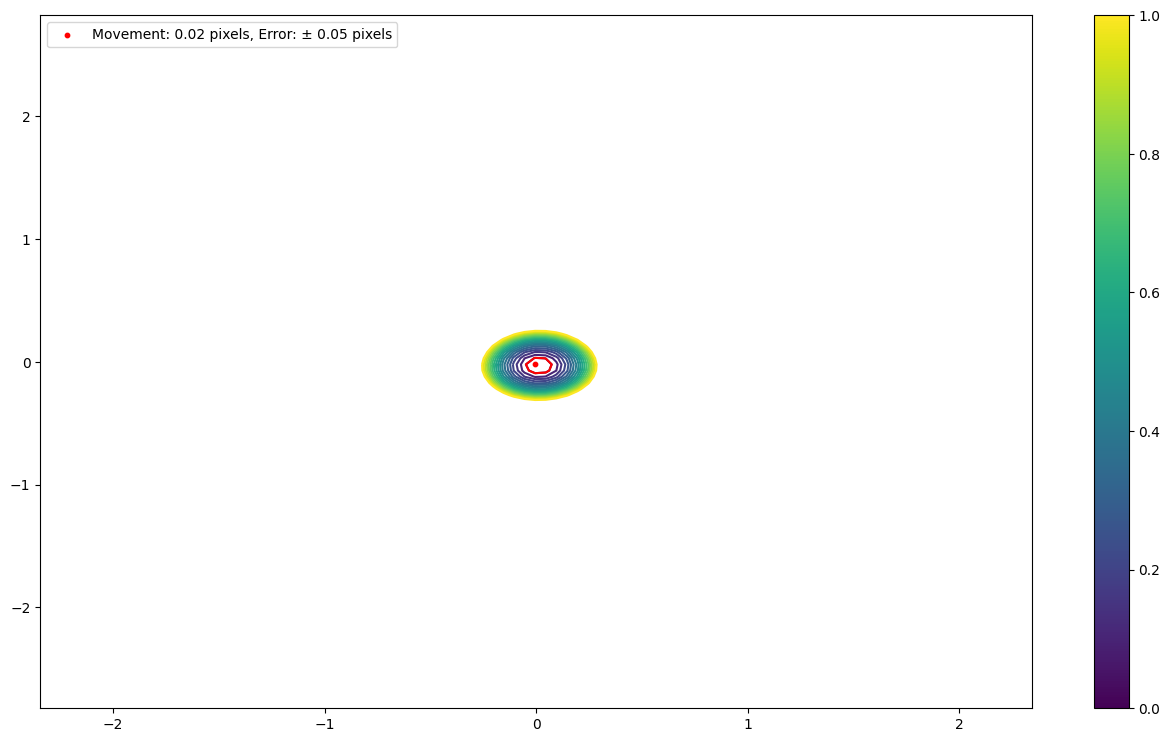

In [32]:
#6
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [682, round(682 - x_offset) -1]
cy_chi = [779, round(779 - y_offset)]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  8.14056 , X shift =  -0.031695631453123985 , Y shift =  -0.01979513120491845
Error ± 0.033928242319983246
x error ± 0.024999999999999994 y error ± 0.05
angle = 121.98635059045434
angle error ± 68.11897338821501


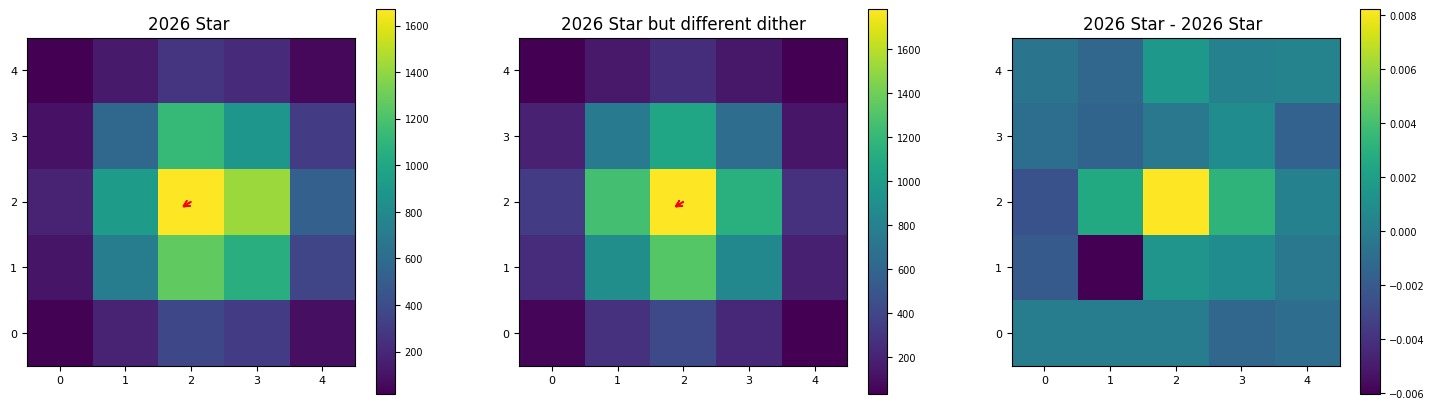

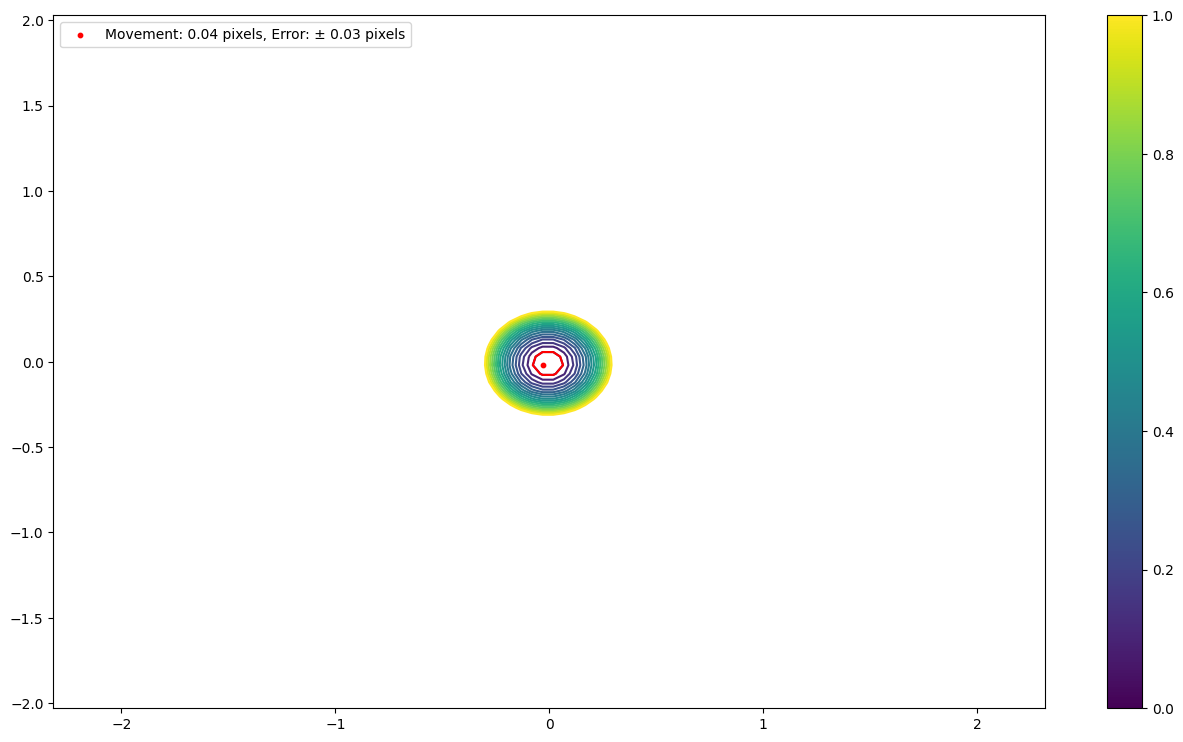

In [33]:
#7
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [1170, round(1170 - x_offset) -2]
cy_chi = [875, round(875 - y_offset)-1]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  30.918917 , X shift =  0.006763816781415244 , Y shift =  0.01415247519890106
Error ± 0.02500000000000002
x error ± 0.024999999999999994 y error ± 0.025000000000000022
angle = -25.54428530231792
angle error ± 91.31838416562202


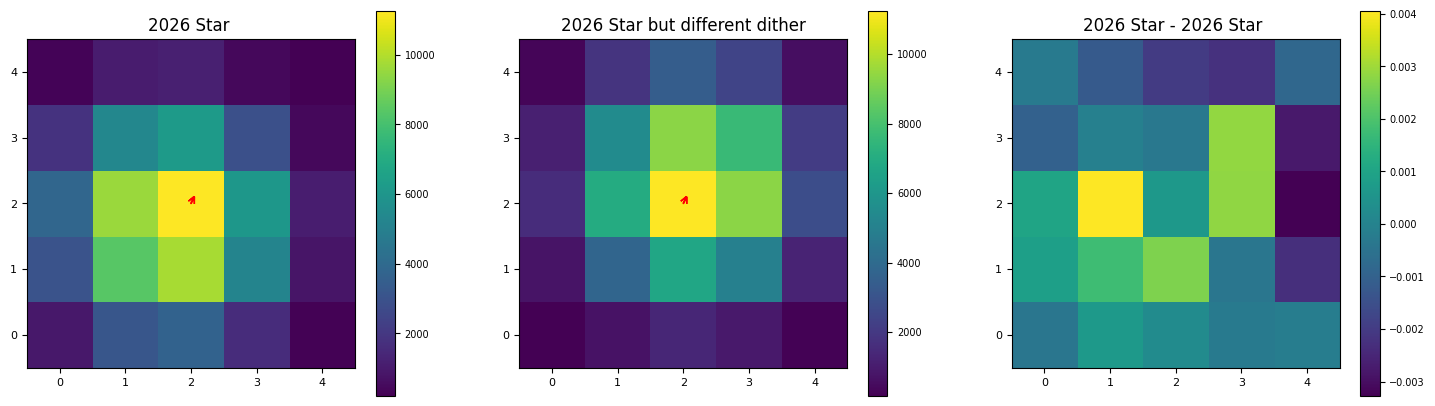

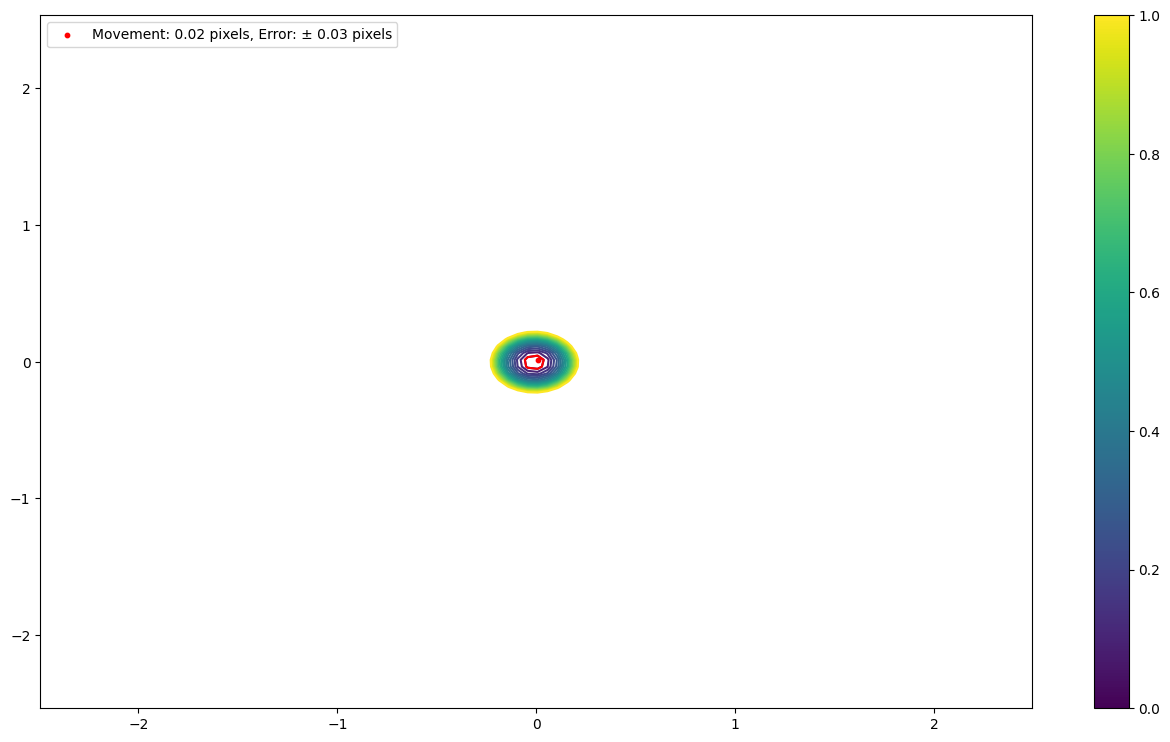

In [34]:
#8
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [51, round(51 - x_offset) -3]
cy_chi = [431, round(431 - y_offset)+3]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  13.627384 , X shift =  -0.000447353354519453 , Y shift =  -0.01091012009950143
Error ± 0.04999999999999999
x error ± 0.04999999999999999 y error ± 0.04999999999999999
angle = 177.65198652482647
angle error ± 262.36042437299363


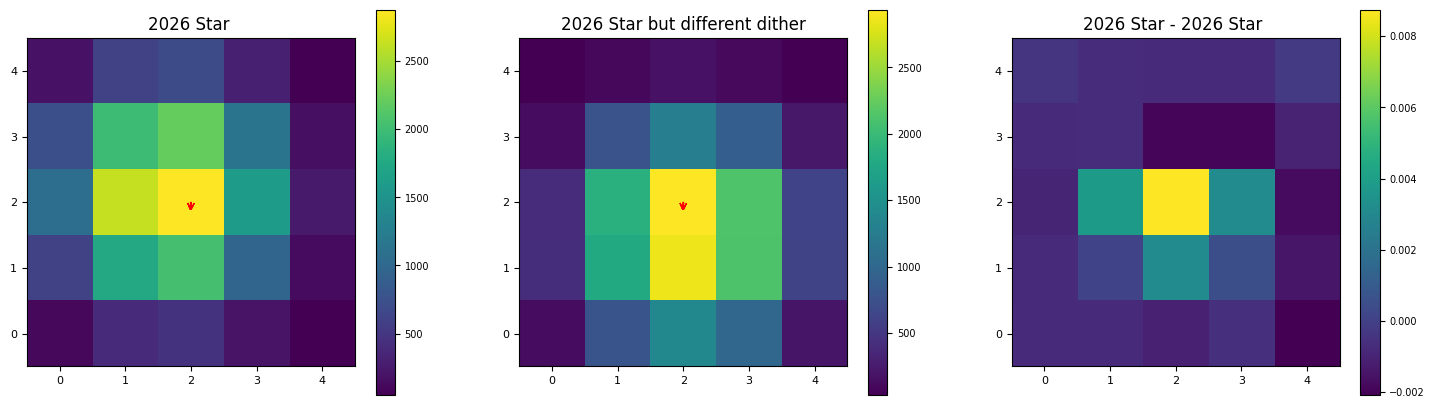

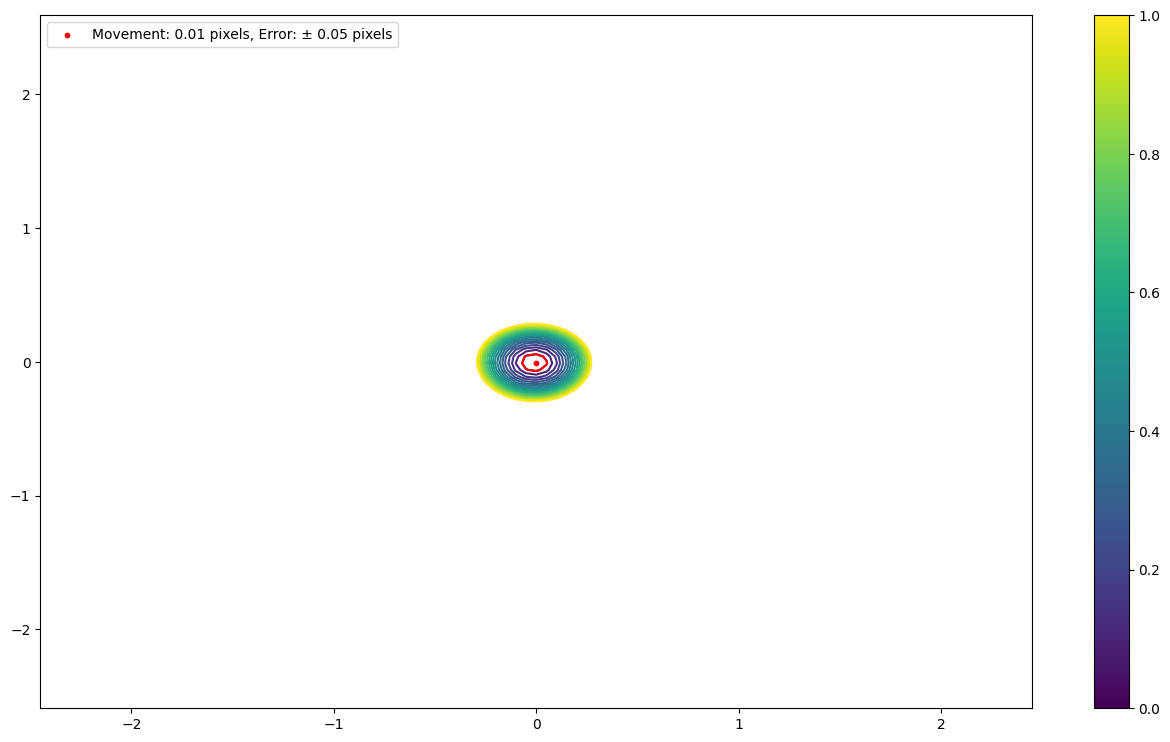

In [35]:
#9
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [98, round(98 - x_offset) -3]
cy_chi = [421, round(421 - y_offset)+4]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  0.4026288 , X shift =  0.014391516853186237 , Y shift =  -0.012623297628860553
Error ± 0.04999999999999998
x error ± 0.04999999999999999 y error ± 0.04999999999999999
angle = -131.25512177530797
angle error ± 149.650210900853


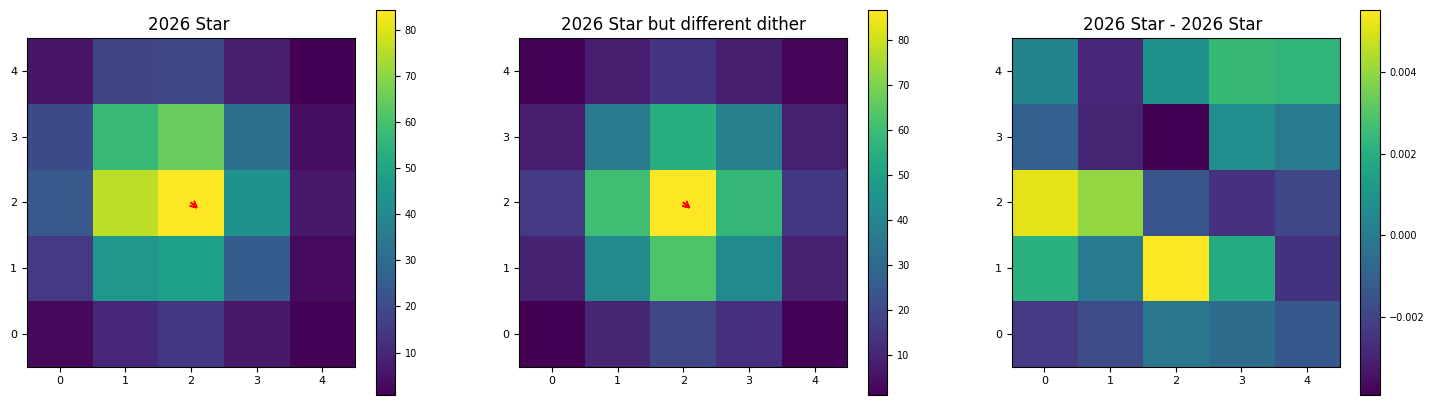

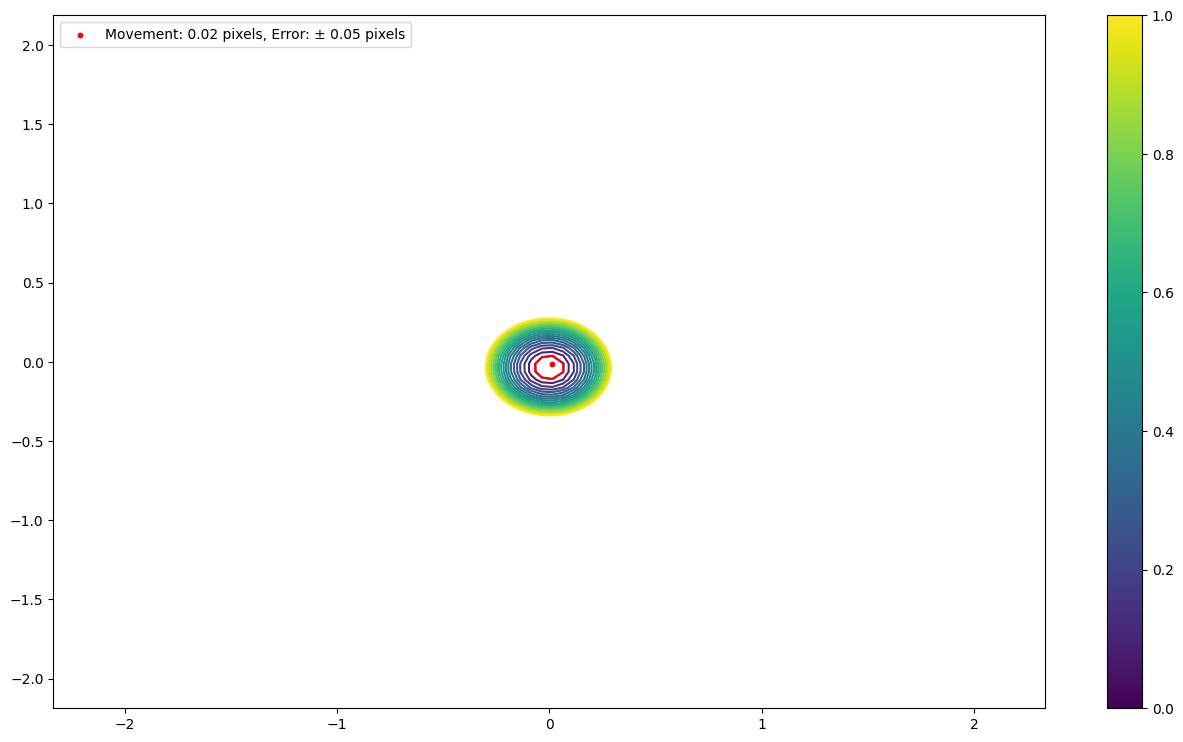

In [36]:
#10
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [324, round(324 - x_offset)-3]
cy_chi = [404, round(404 - y_offset)+3]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  0.7653025 , X shift =  0.008349061494482113 , Y shift =  0.017316660659255967
Error ± 0.07499999999999998
x error ± 0.07500000000000001 y error ± 0.07499999999999998
angle = -25.740593582808962
angle error ± 223.52877939972552


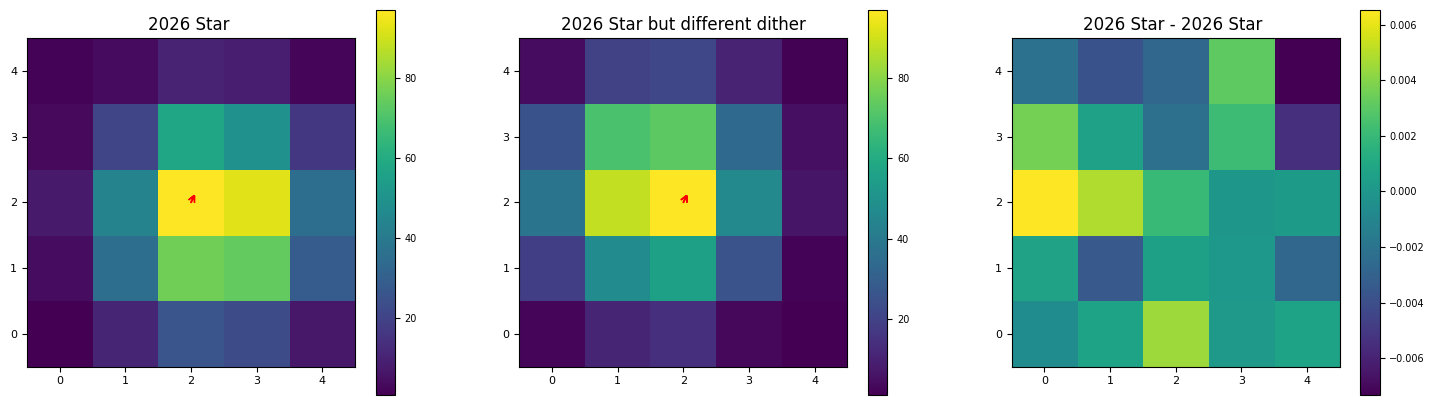

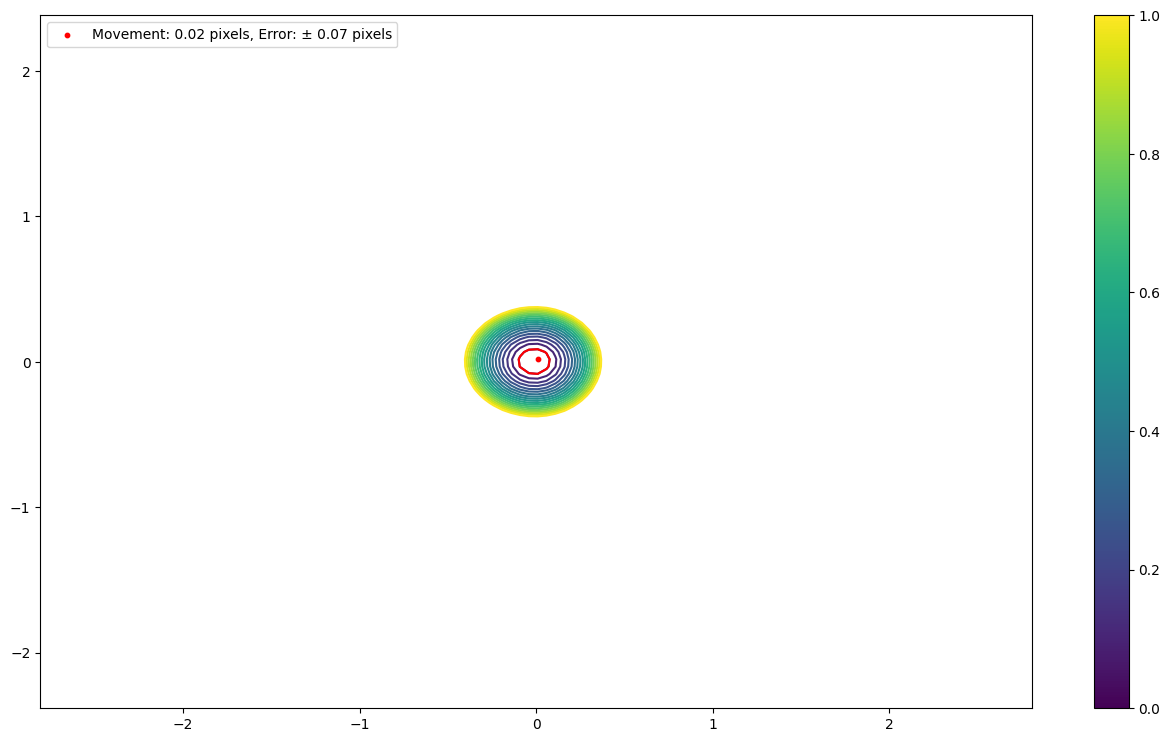

In [37]:
#11
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [480, round(480 - x_offset) -2]
cy_chi = [405, round(405 - y_offset)+2]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

In [38]:
#12
# plt.rcParams['figure.max_open_warning'] = 200
# #define the x, y position of the knot
# cx_chi = [2010, round(2010 - x_offset)-2]
# cy_chi = [482, round(482 - y_offset)+3]
# #define the size of the image
# size_chi = [2, 2]
# #how much bigger the median subtraction is from the image size
# median_factor = 2
# #sets how much each chi is offset by. should be kept small to increase how accurate it is 
# shift_amount = .05
# #sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
# width = 40
# height = 40
# direction = 1
# chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  0.6437986 , X shift =  -0.02274487881802545 , Y shift =  0.03173368319147862
Error ± 0.0
x error ± 0.0 y error ± 0.0
angle = 35.63077703670813
angle error ± 0.0


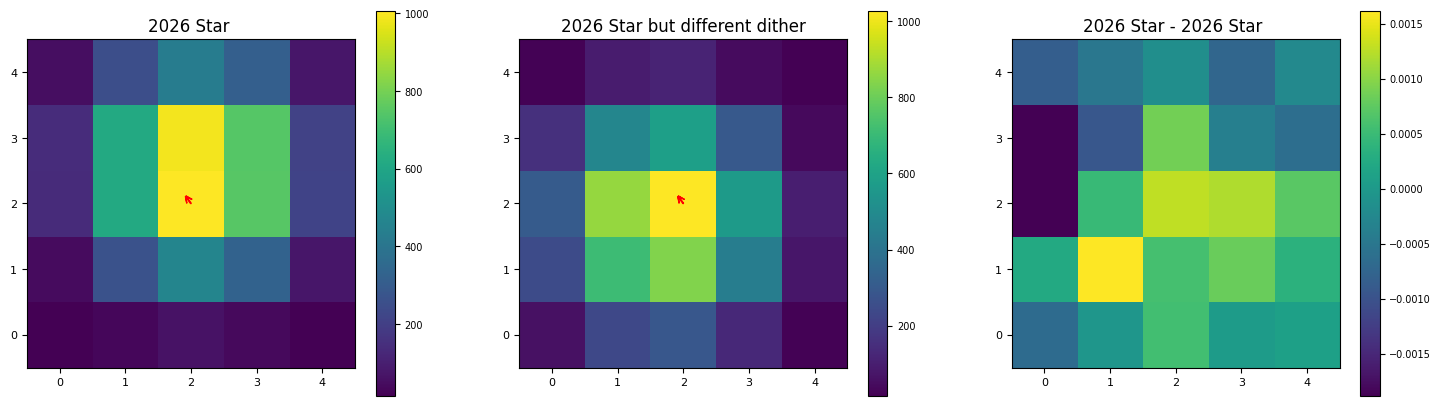

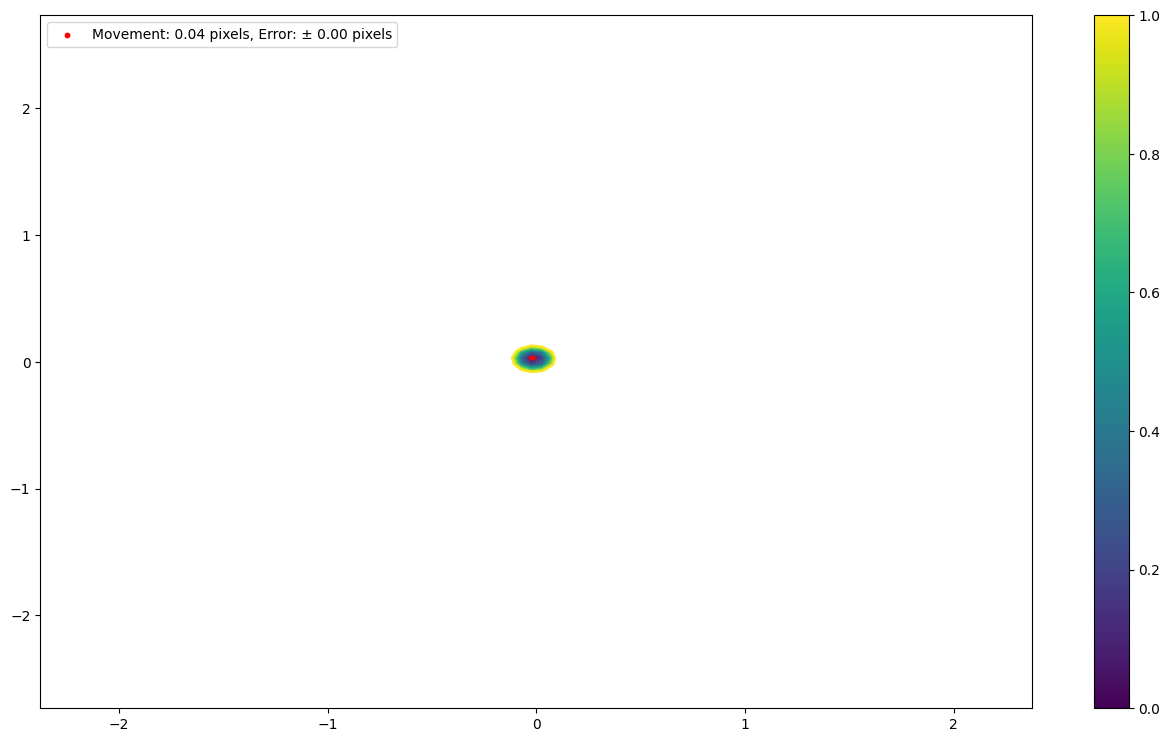

In [39]:
#13
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [442, round(442 - x_offset)-4]
cy_chi = [96, round(96 - y_offset)+4]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  1.9401025 , X shift =  0.0005058969118749701 , Y shift =  -0.0029346670506499306
Error ± 0.024636615568764085
x error ± 0.0 y error ± 0.025000000000000022
angle = -170.2191129316386
angle error ± 81.71260833168404


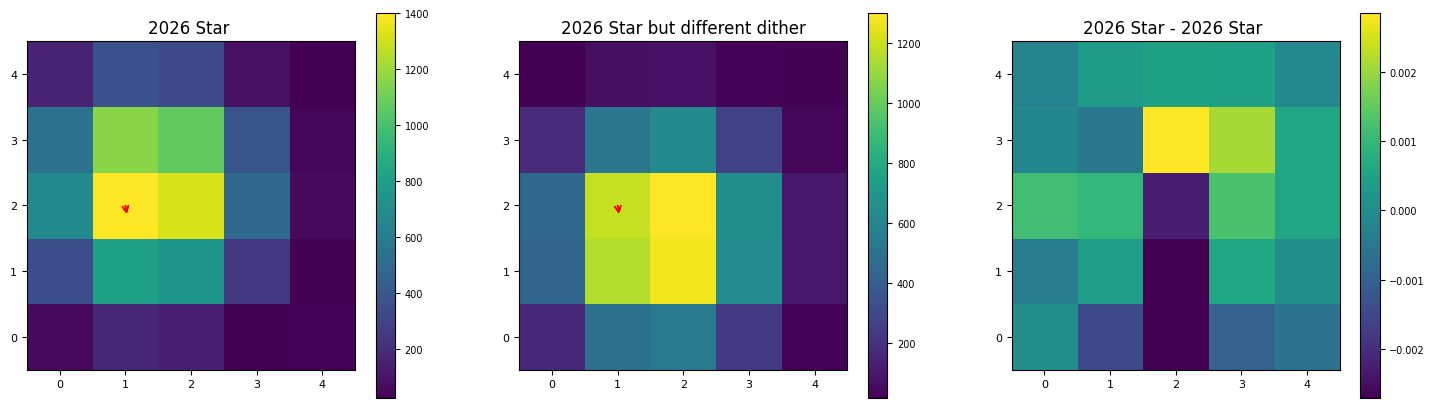

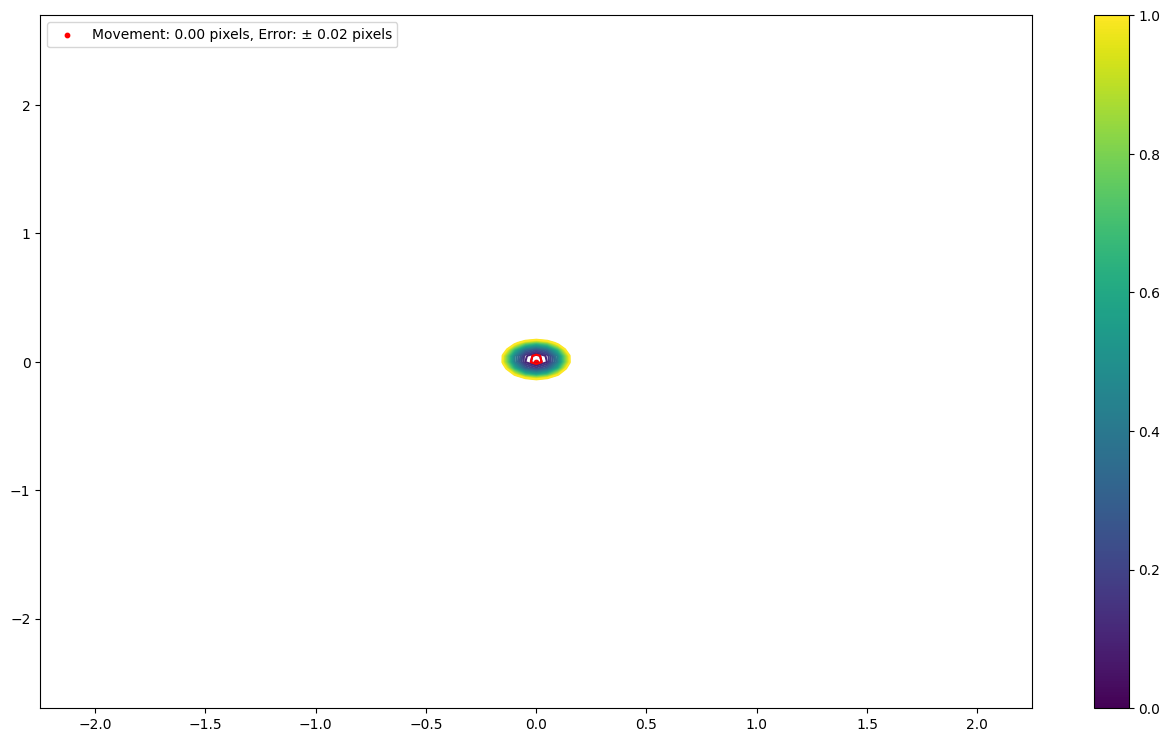

In [40]:
#14
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [794, round(794 - x_offset)-5]
cy_chi = [143, round(143 - y_offset)+3]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

In [41]:
velocity_storage_x_dither_1_3 = velocity_storage_x
velocity_storage_y_dither_1_3 = velocity_storage_y
x_error_dither_1_3 = x_error
y_error_dither_1_3 = y_error
error_bar_dither_1_3 = error_bar

# **Dither 1 to Dither 4**

In [42]:
hdu_1_A = fits.open((path_image_2 + 'nan_rm_jwst_2026_f444w_f470n_d1_frame_A.fits'))[1]
hdu_2_A = fits.open((path_image_2 + 'nan_rm_jwst_2026_f444w_f470n_d4_frame_A.fits'))[1]

In [43]:
x_offset = -774.0652020804971
y_offset  = -4.327453375424055

0.5823348 0.52804685 0.55452687


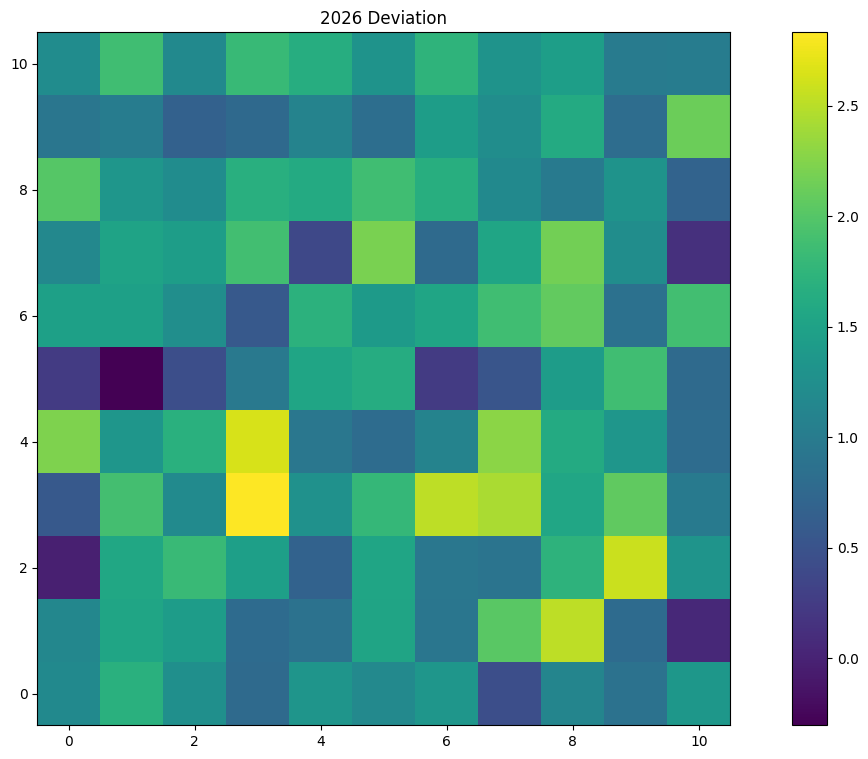

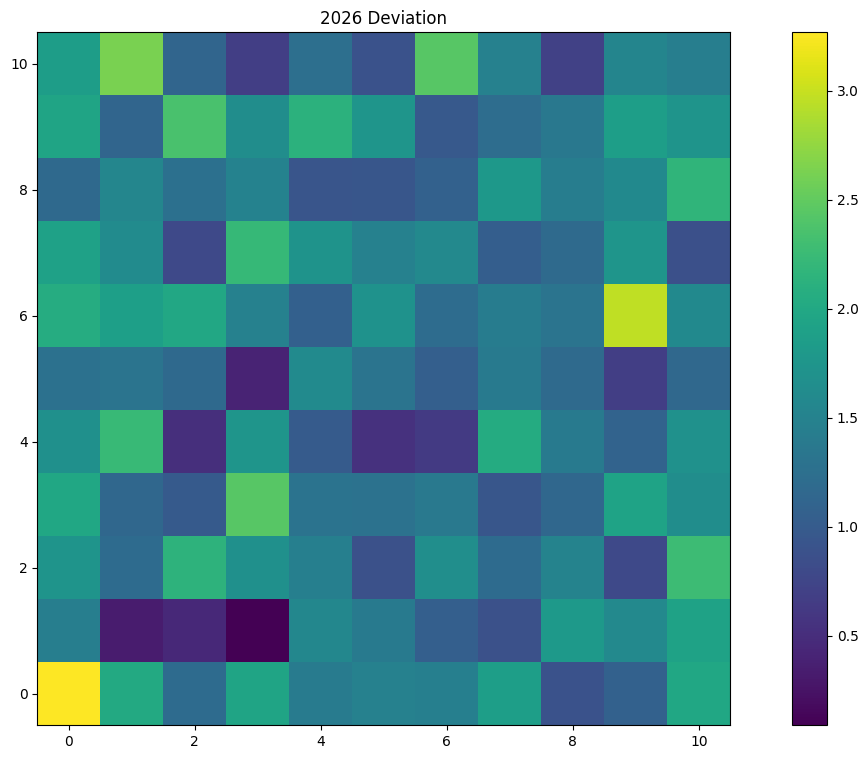

In [44]:
#define the x, y position of the knot
dev_x = [473, round(473 - x_offset)]
dev_y = [1240, round(1240 - y_offset)]
#define the size of the image
size_dev = [5, 5]
i=0
#creates the first image
std_04 = hdu_1_A.data[dev_y[i]-size_dev[i]:dev_y[i]+size_dev[i]+1, dev_x[i]-size_dev[i]:dev_x[i]+size_dev[i]+1]
#this normalizes the data to elimnate the changes in brightness and reduces error
fig, ax = plt.subplots(1, 1, figsize=(16, 9))
plt.imshow(std_04, vmin=np.min(std_04), vmax=np.max(std_04), origin="lower")
plt.colorbar()
title_1 = "2026 Deviation"
ax.set_title(title_1)
std_17 = hdu_2_A.data[dev_y[i+1]-size_dev[i+1]:dev_y[i+1]+size_dev[i+1]+1, dev_x[i+1]-size_dev[i+1]:dev_x[i+1]+size_dev[i+1]+1]
#this normalizes the data to elimnate the changes in brightness and reduces error
fig, ax = plt.subplots(1, 1, figsize=(16, 9))
plt.imshow(std_17, vmin=np.min(std_17), vmax=np.max(std_17), origin="lower")
plt.colorbar()
title_2 = "2026 Deviation"
ax.set_title(title_2)
dev_04 = np.std(std_04)
dev_17 = np.std(std_17)
deviation = np.sqrt(dev_04*dev_17)
print (dev_04, dev_17, deviation)

In [45]:
#this is where the data is stored for processing graphs at the end of calculating all of the knots
velocity_storage_x = []
velocity_storage_y = []
x_error = []
y_error = []
error_bar = []

minimum chi squared value =  4.7359066 , X shift =  0.024113374271235 , Y shift =  -0.04605342262798162
Error ± 0.025000000000000015
x error ± 0.024999999999999994 y error ± 0.025000000000000022
angle = -152.36363876080733
angle error ± 27.55434110058766


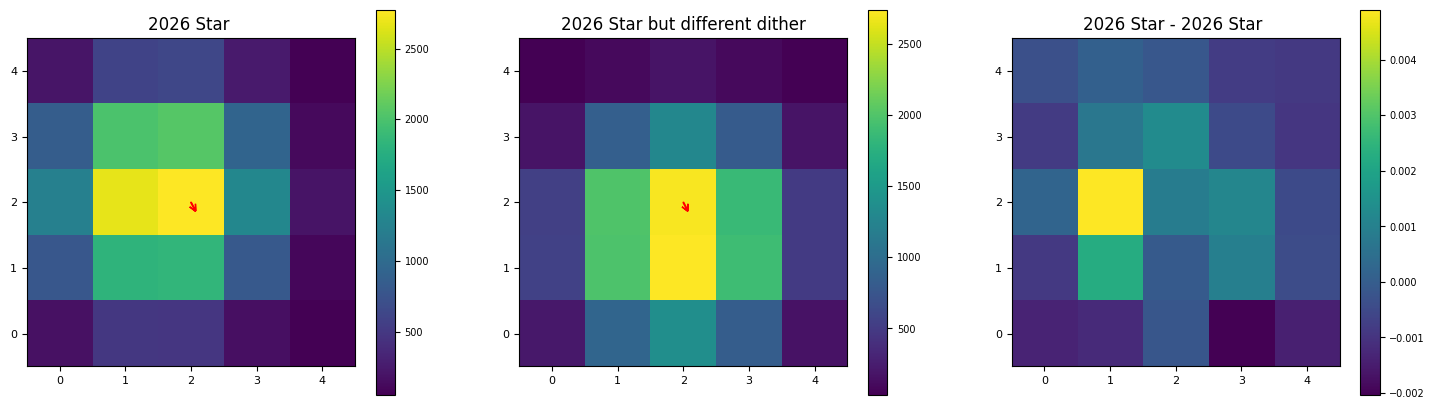

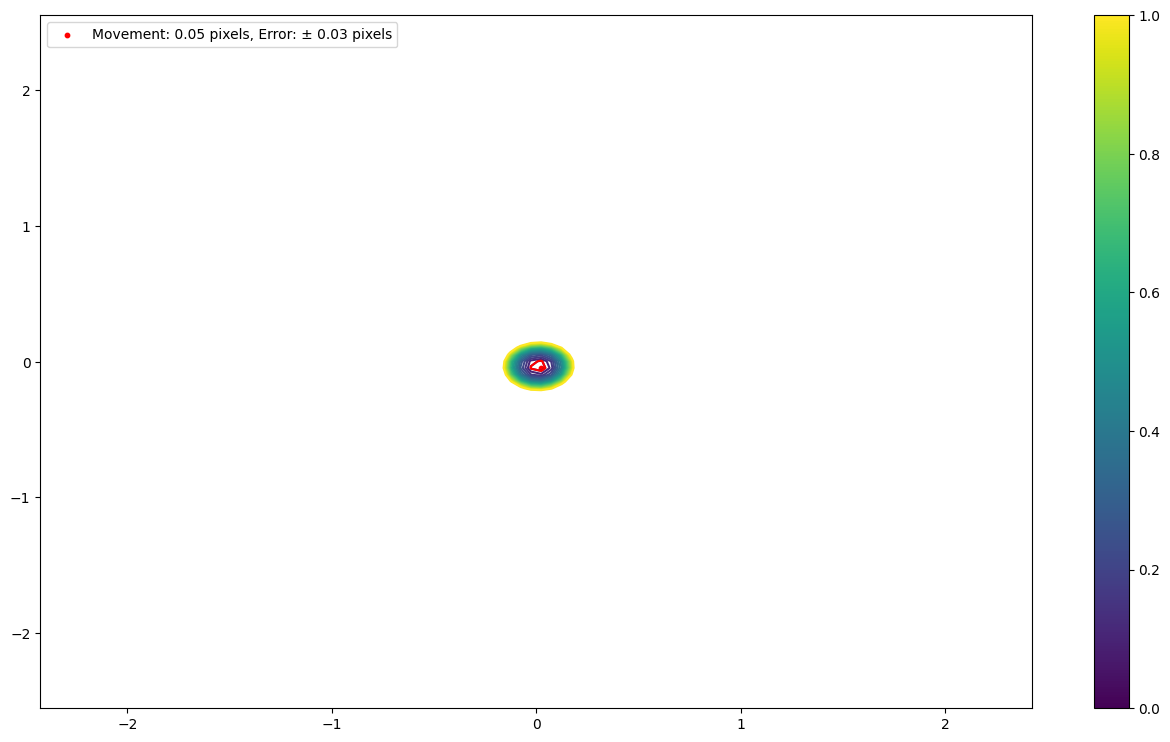

In [46]:
#1
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [185, round(185 - x_offset)+7]
cy_chi = [1910, round(1910 - y_offset)+3]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 3
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

In [47]:
# #2
# plt.rcParams['figure.max_open_warning'] = 200
# #define the x, y position of the knot
# cx_chi = [1321, round(1321 - x_offset) ]
# cy_chi = [1753, round(1753 - y_offset) -5]
# #define the size of the image
# size_chi = [2, 2]
# #how much bigger the median subtraction is from the image size
# median_factor = 2
# #sets how much each chi is offset by. should be kept small to increase how accurate it is 
# shift_amount = .05
# #sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
# width = 40
# height = 40
# direction = 1
# chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

In [48]:
#3
# plt.rcParams['figure.max_open_warning'] = 200
# #define the x, y position of the knot
# cx_chi = [1697, round(1697 - x_offset) - 1]
# cy_chi = [1091, round(1091 - y_offset) +1]
# #define the size of the image
# size_chi = [2, 2]
# #how much bigger the median subtraction is from the image size
# median_factor = 2
# #sets how much each chi is offset by. should be kept small to increase how accurate it is 
# shift_amount = .05
# #sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
# width = 40
# height = 40
# direction = 1
# chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

In [49]:
# #4
# plt.rcParams['figure.max_open_warning'] = 200
# #define the x, y position of the knot
# cx_chi = [1974, round(1974 - x_offset) -1]
# cy_chi = [1055, round(1055 - y_offset) +1]
# #define the size of the image
# size_chi = [2, 2]
# #how much bigger the median subtraction is from the image size
# median_factor = 2
# #sets how much each chi is offset by. should be kept small to increase how accurate it is 
# shift_amount = .05
# #sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
# width = 40
# height = 40
# direction = 1
# chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

In [50]:
# #5
# plt.rcParams['figure.max_open_warning'] = 200
# #define the x, y position of the knot
# cx_chi = [1786, round(1786 - x_offset) -1]
# cy_chi = [967, round(967 - y_offset)]
# #define the size of the image
# size_chi = [2, 2]
# #how much bigger the median subtraction is from the image size
# median_factor = 2
# #sets how much each chi is offset by. should be kept small to increase how accurate it is 
# shift_amount = .05
# #sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
# width = 40
# height = 40
# direction = 1
# chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  37.6916 , X shift =  0.021810731111486348 , Y shift =  -0.02728802528278995
Error ± 0.07499999999999998
x error ± 0.07500000000000004 y error ± 0.07499999999999996
angle = -141.36540829897683
angle error ± 123.01064750811653


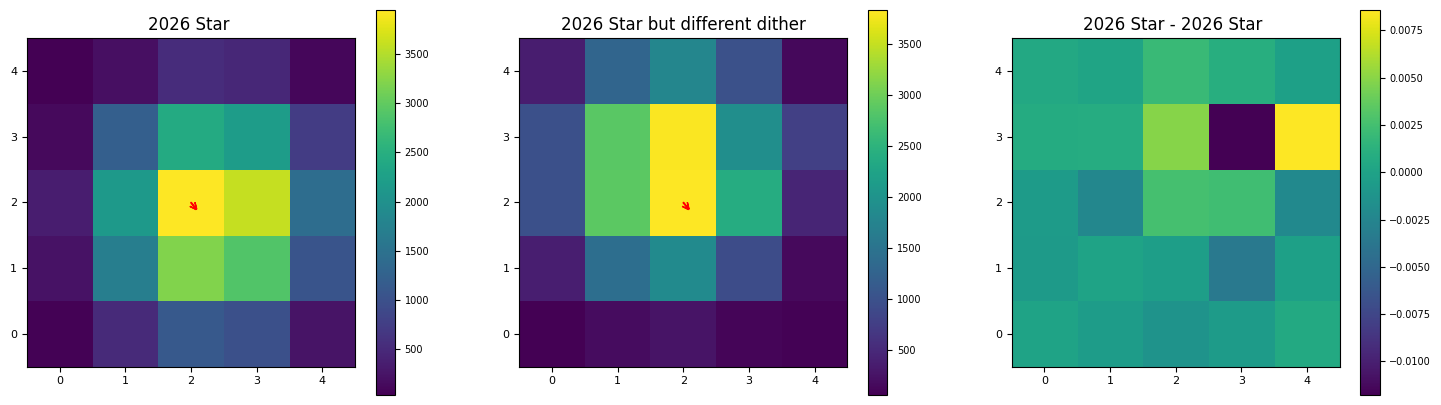

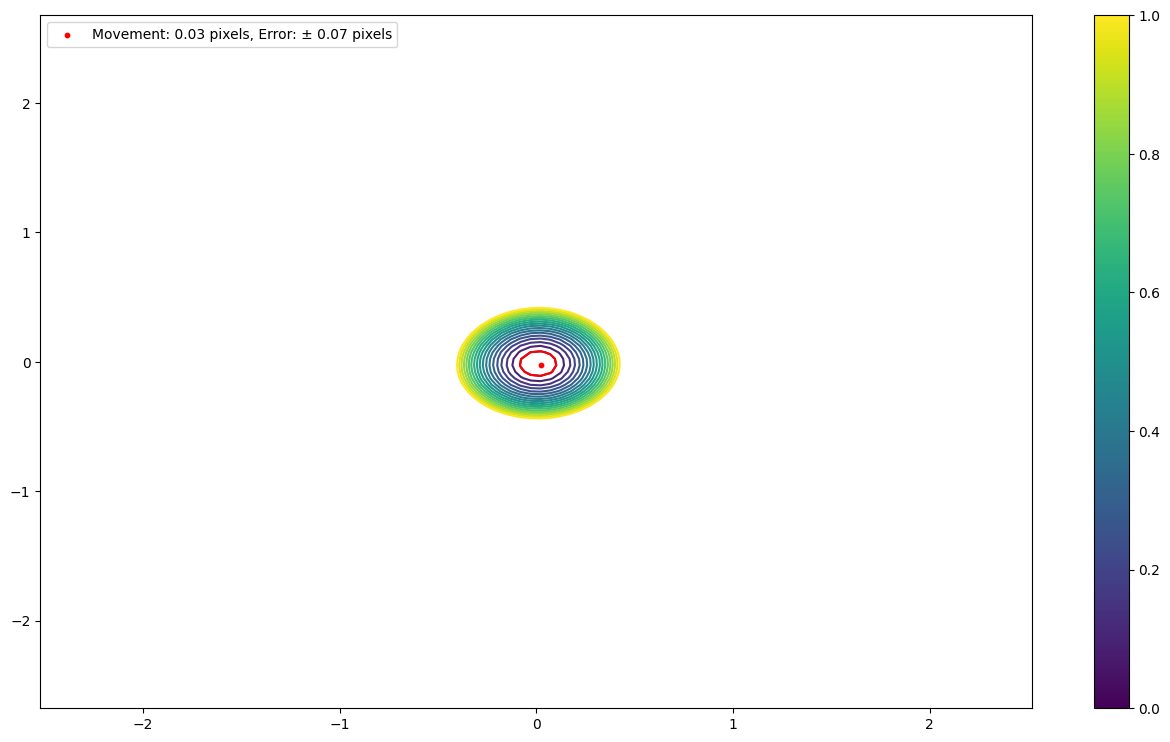

In [51]:
#6
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [682, round(682 - x_offset) -2]
cy_chi = [779, round(779 - y_offset)]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  2.5172658 , X shift =  0.04216764452708048 , Y shift =  -0.004103047499505075
Error ± 0.025
x error ± 0.025 y error ± 0.024999999999999994
angle = -95.55756824794265
angle error ± 33.809366927176384


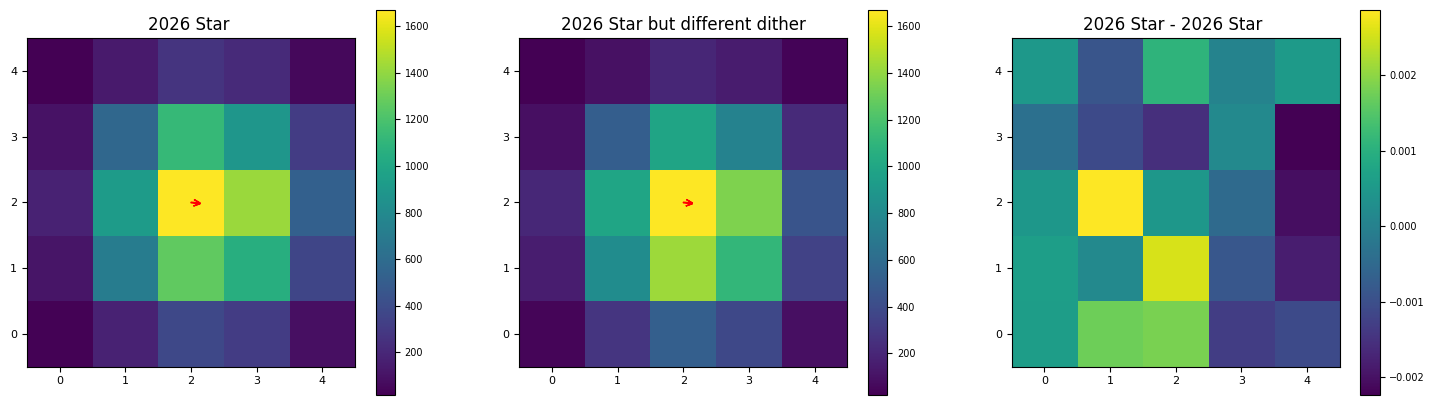

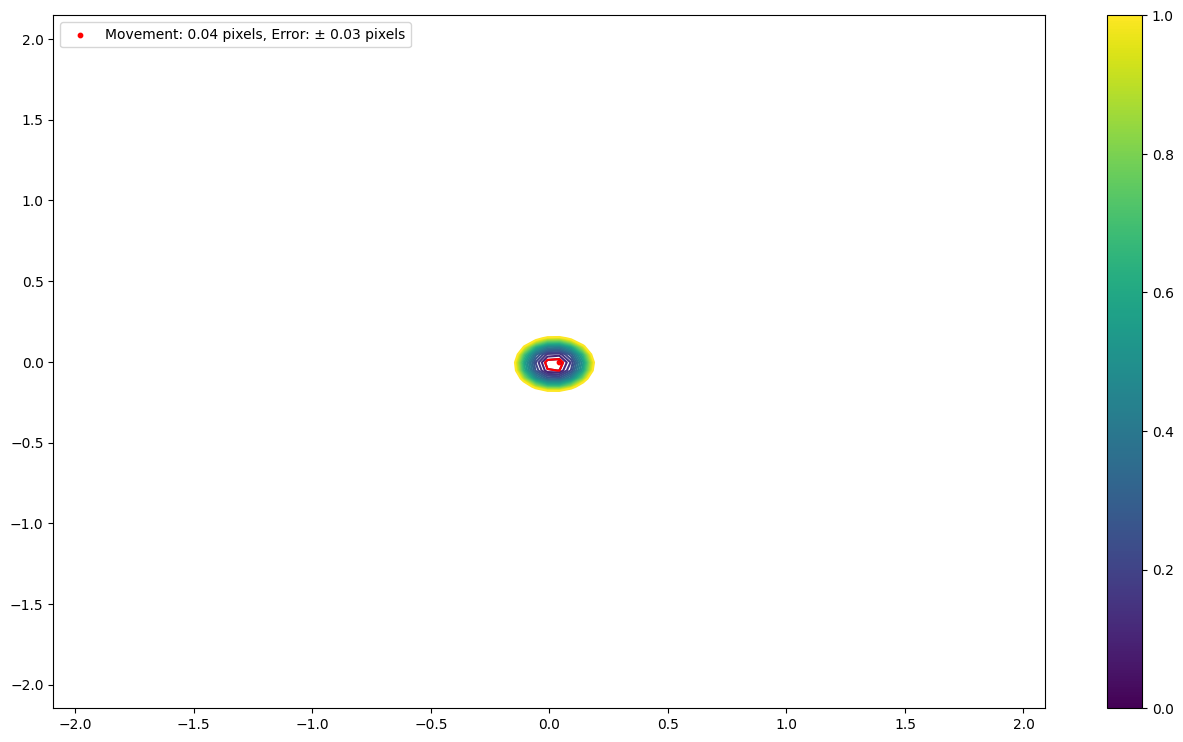

In [52]:
#7
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [1170, round(1170 - x_offset) -4]
cy_chi = [875, round(875 - y_offset)-3]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  16.546534 , X shift =  -0.049964261445313685 , Y shift =  -0.01943631715096039
Error ± 0.02329920760200496
x error ± 0.024999999999999994 y error ± 0.0
angle = 111.25625376147084
angle error ± 9.686345561704666


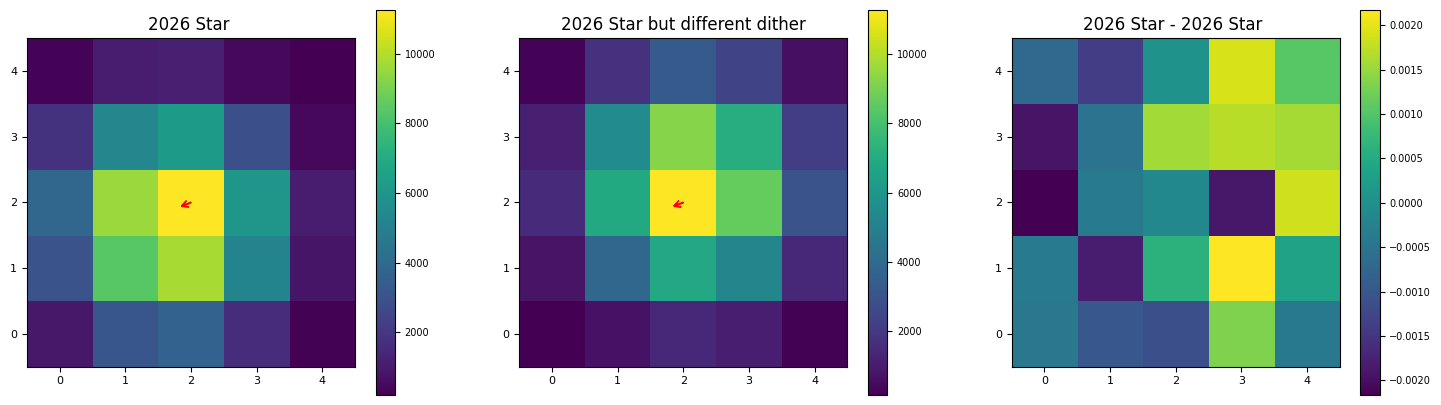

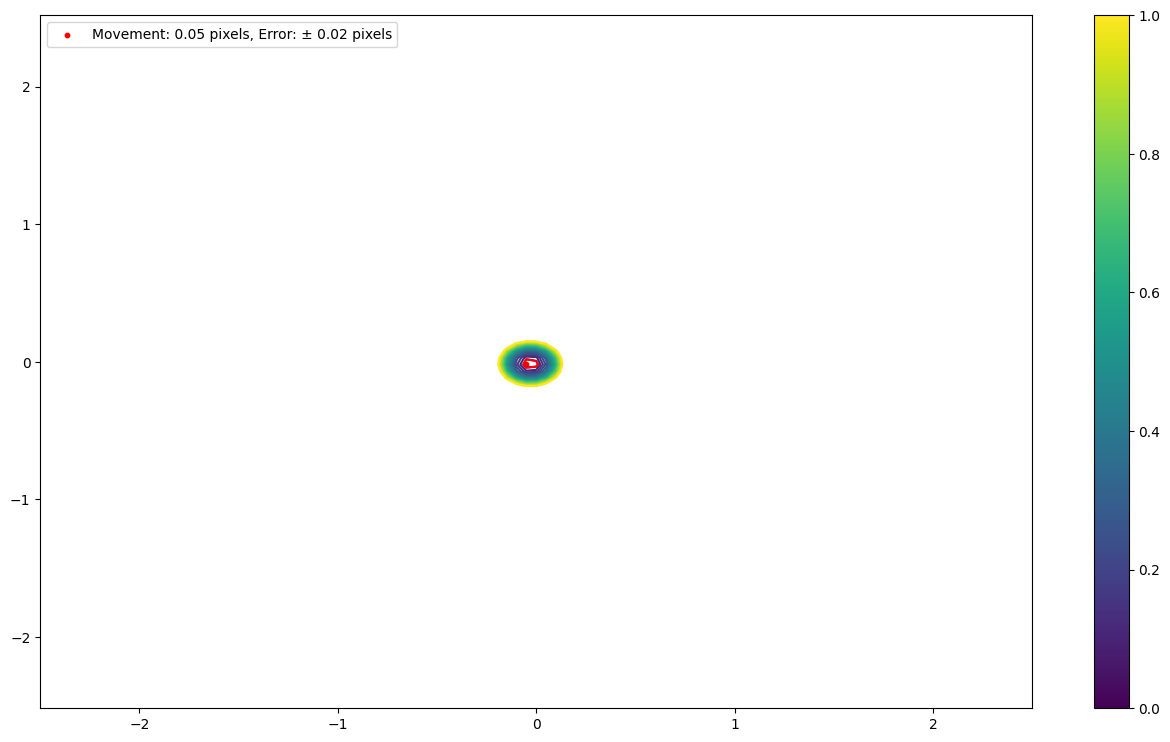

In [53]:
#8
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [51, round(51 - x_offset) -6]
cy_chi = [431, round(431 - y_offset) +5]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  12.5692215 , X shift =  -0.016059271477575965 , Y shift =  0.00604070640724963
Error ± 0.04999999999999999
x error ± 0.04999999999999999 y error ± 0.05000000000000002
angle = 69.38617416937348
angle error ± 166.96708434514036


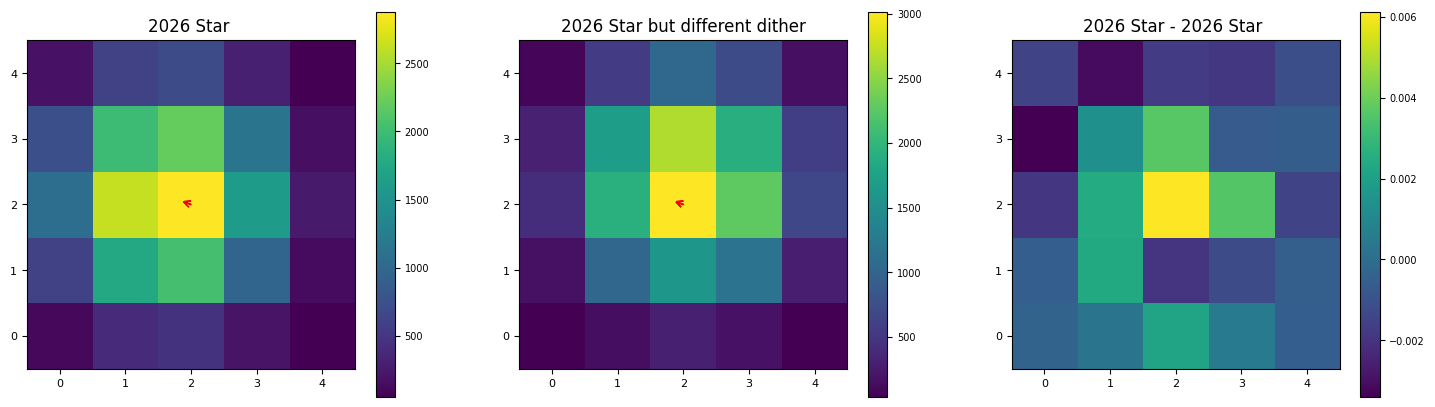

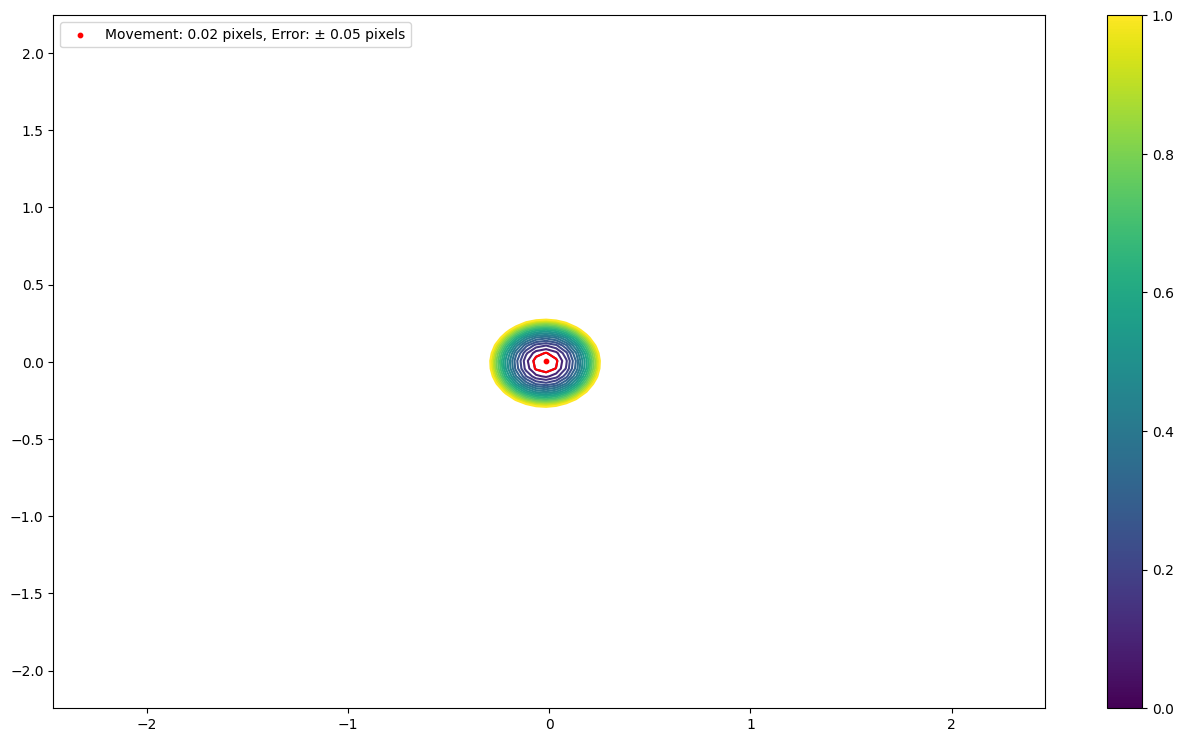

In [54]:
#9
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [98, round(98 - x_offset) -6]
cy_chi = [421, round(421 - y_offset)+5]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  0.46508706 , X shift =  0.005543205284107011 , Y shift =  0.003495006295817754
Error ± 0.05821441434162621
x error ± 0.04999999999999999 y error ± 0.07500000000000001
angle = -57.76845507702987
angle error ± 601.7140097438877


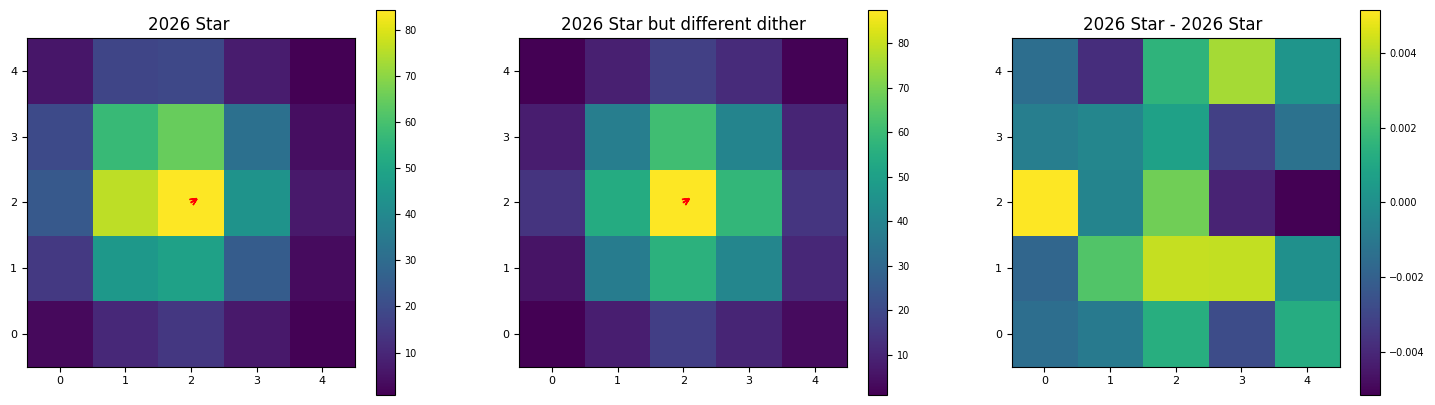

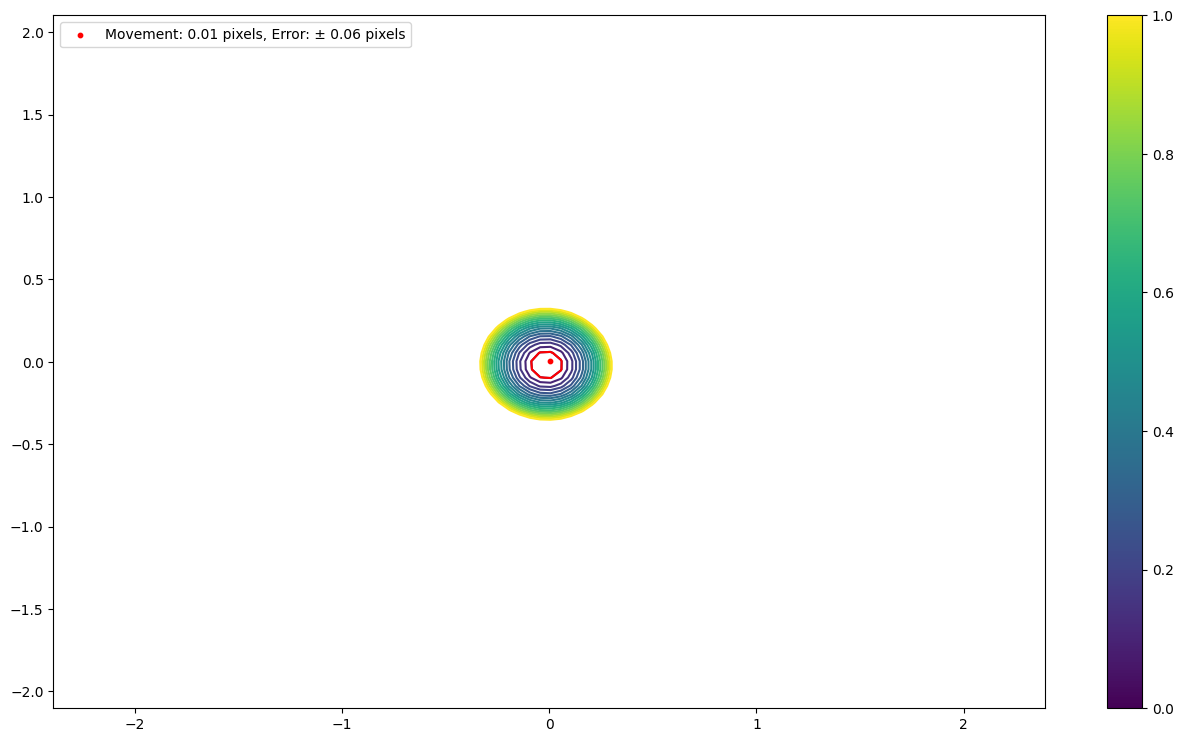

In [55]:
#10
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [324, round(324 - x_offset)-6]
cy_chi = [404, round(404 - y_offset)+4]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  0.72767 , X shift =  -0.03283251756964778 , Y shift =  0.002646440968773686
Error ± 0.07486539778795039
x error ± 0.07500000000000001 y error ± 0.05
angle = 85.39167869493781
angle error ± 87.32272983093334


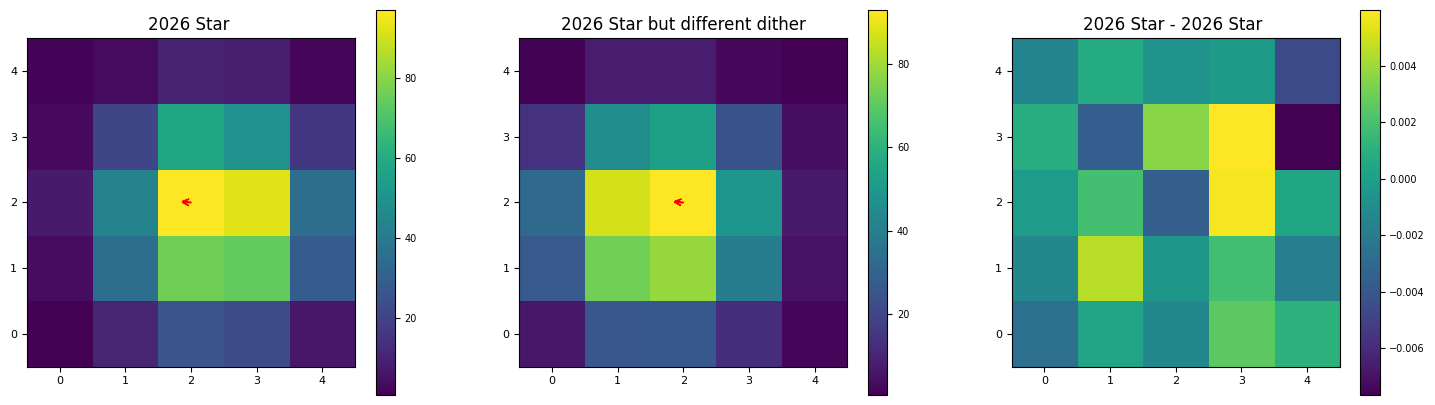

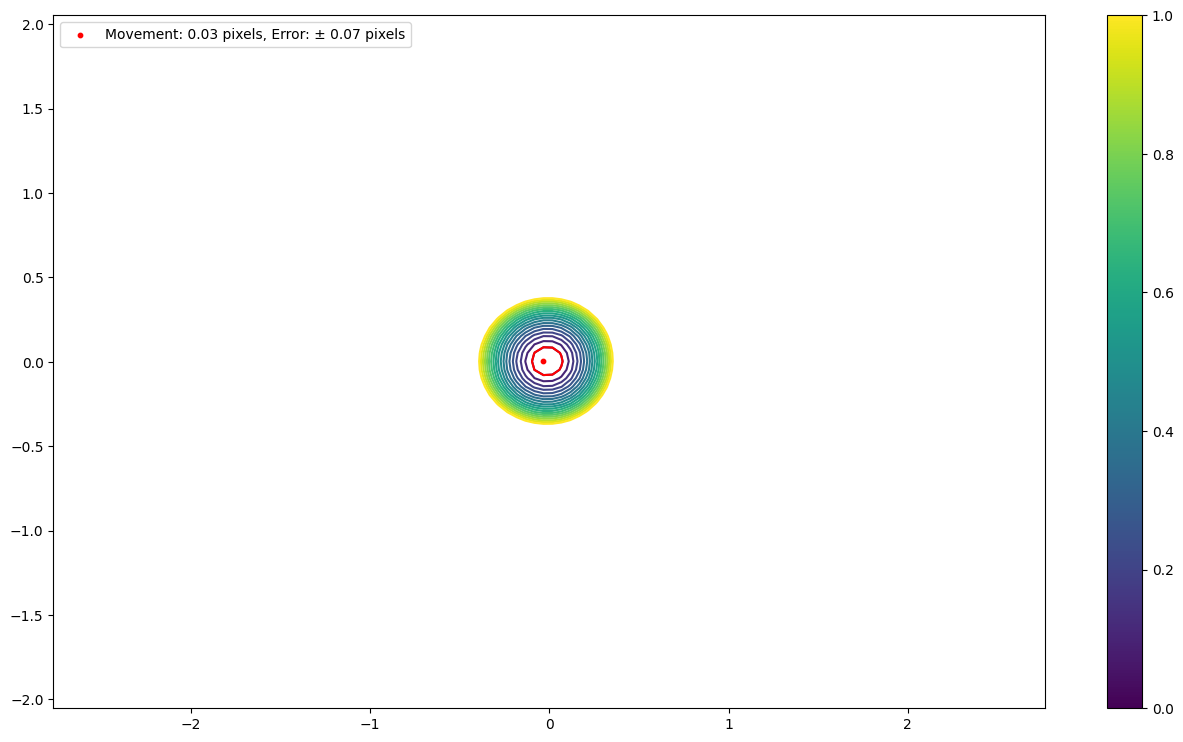

In [56]:
#11
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [480, round(480 - x_offset) -5]
cy_chi = [405, round(405 - y_offset)+3]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

In [57]:
#12
# plt.rcParams['figure.max_open_warning'] = 200
# #define the x, y position of the knot
# cx_chi = [2010, round(2010 - x_offset)-2]
# cy_chi = [482, round(482 - y_offset)+3]
# #define the size of the image
# size_chi = [2, 2]
# #how much bigger the median subtraction is from the image size
# median_factor = 2
# #sets how much each chi is offset by. should be kept small to increase how accurate it is 
# shift_amount = .05
# #sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
# width = 40
# height = 40
# direction = 1
# chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  1.1444051 , X shift =  -0.028393038113028984 , Y shift =  6.194677984189267e-05
Error ± 5.454385698368848e-05
x error ± 0.0 y error ± 0.024999999999999994
angle = 89.87499458868662
angle error ± 50.44855234769318


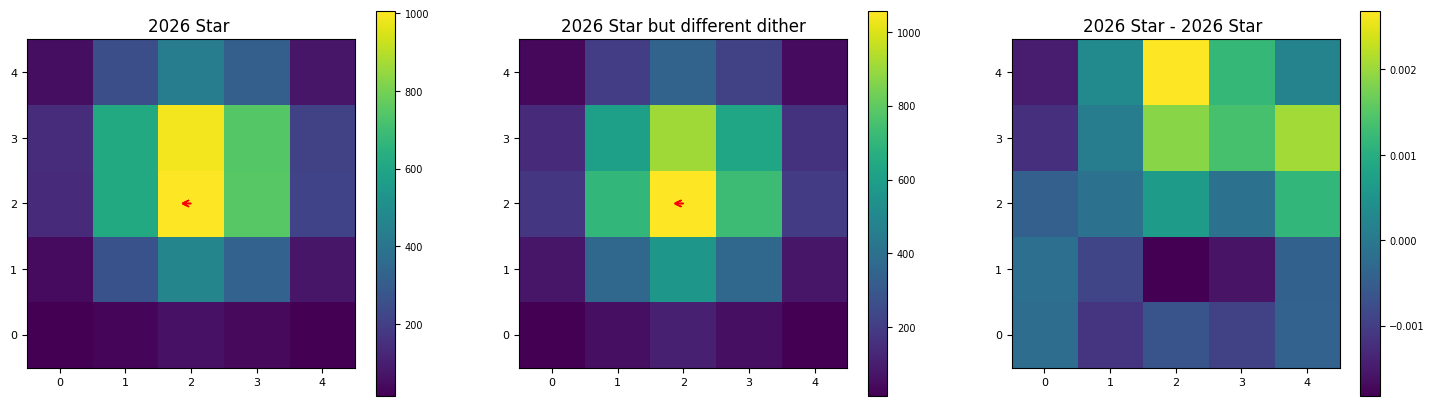

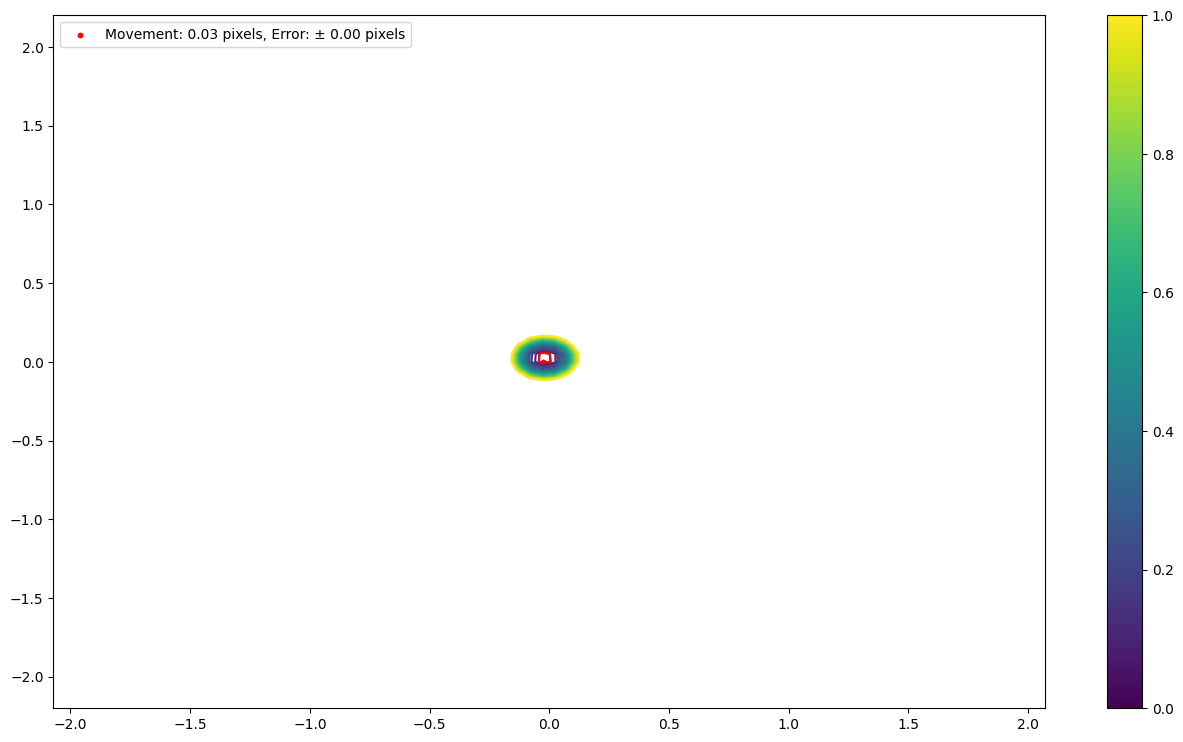

In [58]:
#13
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [442, round(442 - x_offset)-9]
cy_chi = [96, round(96 - y_offset)+4]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  3.071098 , X shift =  -0.002483982555986586 , Y shift =  0.0022842003772399755
Error ± 0.025
x error ± 0.024999999999999994 y error ± 0.02500000000000001
angle = 47.399233534538055
angle error ± 424.4669260696263


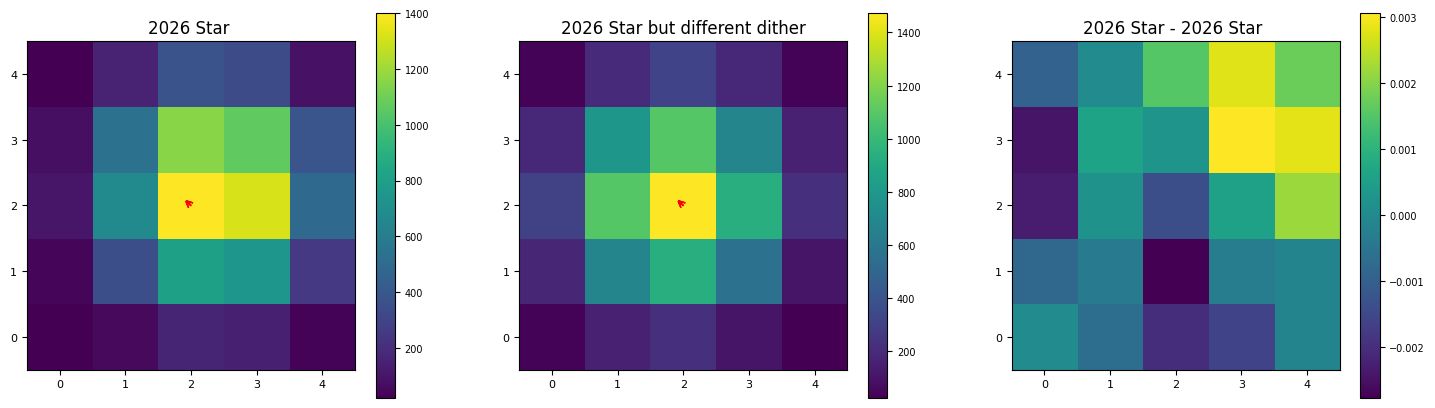

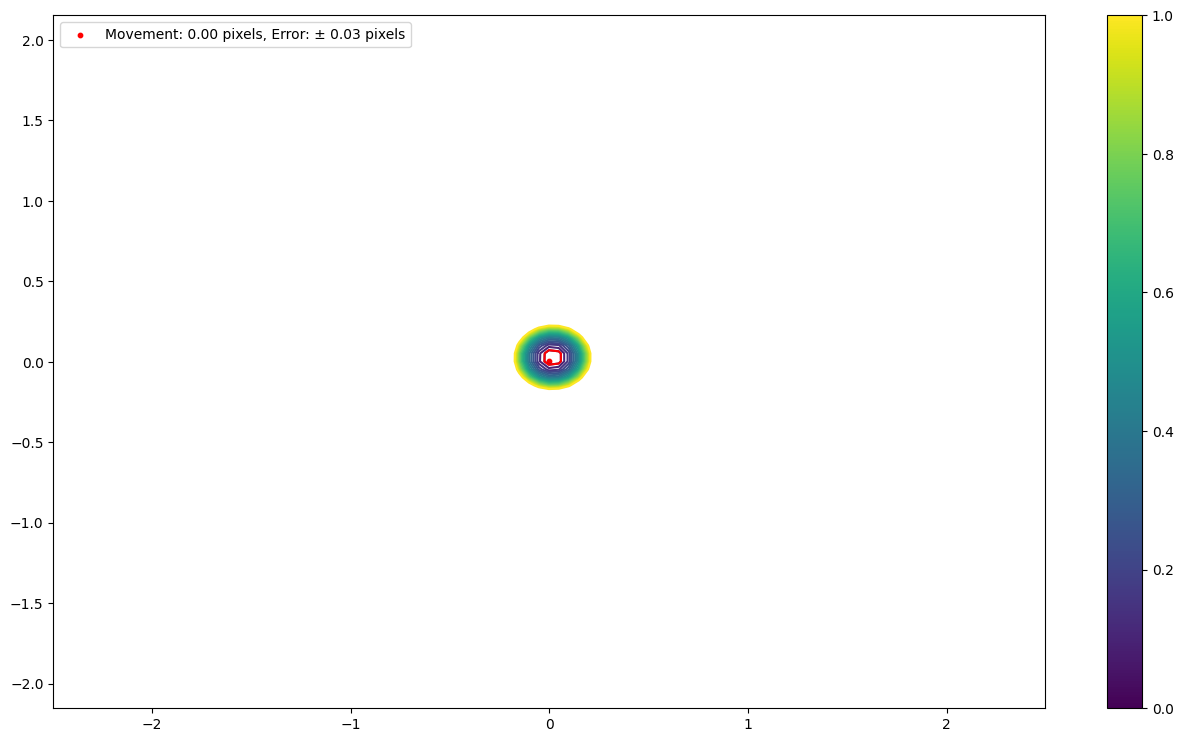

In [59]:
#14
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [793, round(793 - x_offset)-9]
cy_chi = [143, round(143 - y_offset)+2]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

In [60]:
velocity_storage_x_dither_1_4 = velocity_storage_x
velocity_storage_y_dither_1_4 = velocity_storage_y
x_error_dither_1_4 = x_error
y_error_dither_1_4 = y_error
error_bar_dither_1_4 = error_bar

# **Dither 1 to Dither 5**

In [61]:
hdu_1_A = fits.open((path_image_2 + 'nan_rm_jwst_2026_f444w_f470n_d1_frame_A.fits'))[1]
hdu_2_A = fits.open((path_image_2 + 'nan_rm_jwst_2026_f444w_f470n_d5_frame_A.fits'))[1]

In [62]:
x_offset = -777.2010105399196
y_offset  = 166.85496982162434

0.5823348 0.4837708 0.5307698


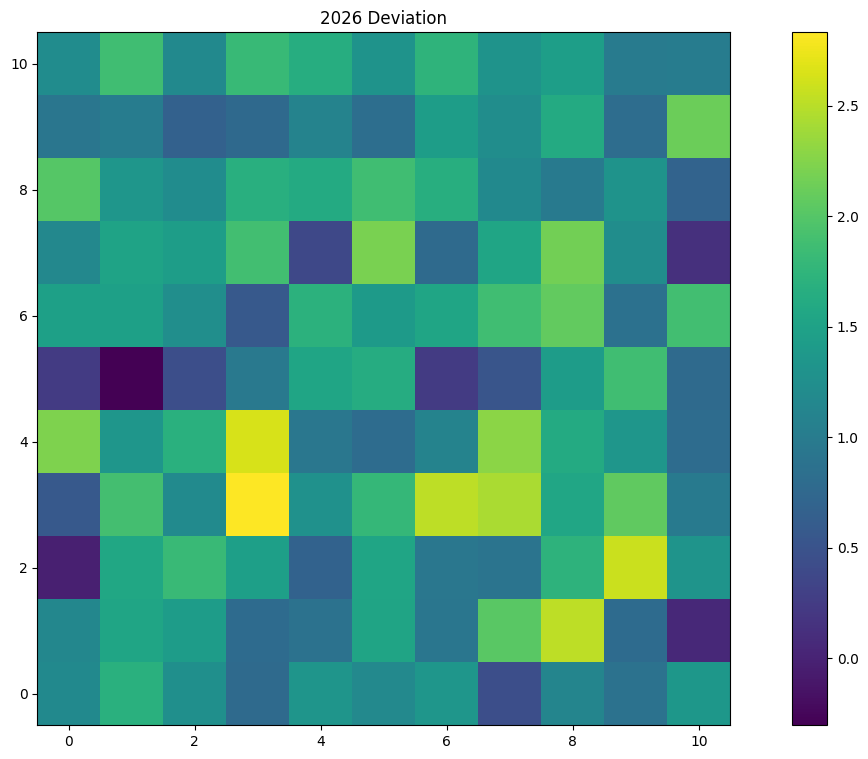

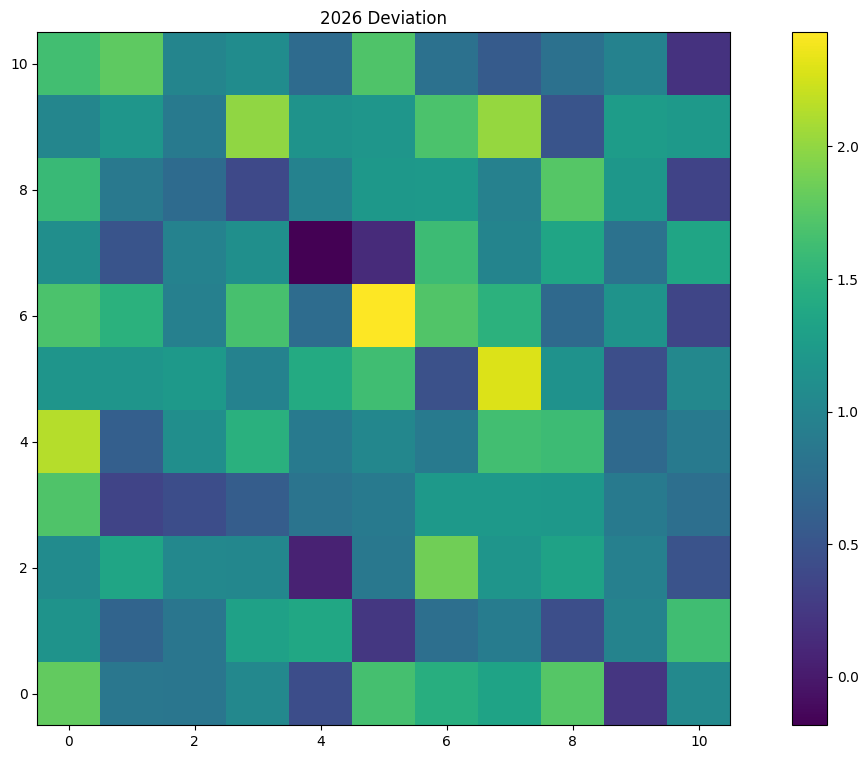

In [63]:
#define the x, y position of the knot
dev_x = [473, round(473 - x_offset)]
dev_y = [1240, round(1240 - y_offset)]
#define the size of the image
size_dev = [5, 5]
i=0
#creates the first image
std_04 = hdu_1_A.data[dev_y[i]-size_dev[i]:dev_y[i]+size_dev[i]+1, dev_x[i]-size_dev[i]:dev_x[i]+size_dev[i]+1]
#this normalizes the data to elimnate the changes in brightness and reduces error
fig, ax = plt.subplots(1, 1, figsize=(16, 9))
plt.imshow(std_04, vmin=np.min(std_04), vmax=np.max(std_04), origin="lower")
plt.colorbar()
title_1 = "2026 Deviation"
ax.set_title(title_1)
std_17 = hdu_2_A.data[dev_y[i+1]-size_dev[i+1]:dev_y[i+1]+size_dev[i+1]+1, dev_x[i+1]-size_dev[i+1]:dev_x[i+1]+size_dev[i+1]+1]
#this normalizes the data to elimnate the changes in brightness and reduces error
fig, ax = plt.subplots(1, 1, figsize=(16, 9))
plt.imshow(std_17, vmin=np.min(std_17), vmax=np.max(std_17), origin="lower")
plt.colorbar()
title_2 = "2026 Deviation"
ax.set_title(title_2)
dev_04 = np.std(std_04)
dev_17 = np.std(std_17)
deviation = np.sqrt(dev_04*dev_17)
print (dev_04, dev_17, deviation)

In [64]:
#this is where the data is stored for processing graphs at the end of calculating all of the knots
velocity_storage_x = []
velocity_storage_y = []
x_error = []
y_error = []
error_bar = []

minimum chi squared value =  2.42152 , X shift =  -0.0019502107680295921 , Y shift =  -0.02875460759934756
Error ± 0.0
x error ± 0.0 y error ± 0.0
angle = 176.1199961435081
angle error ± 0.0


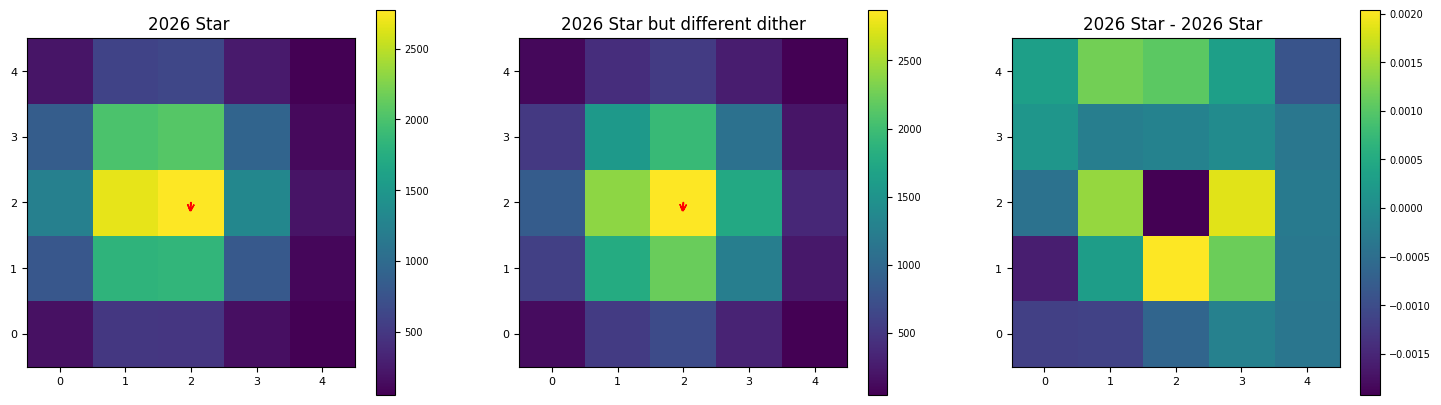

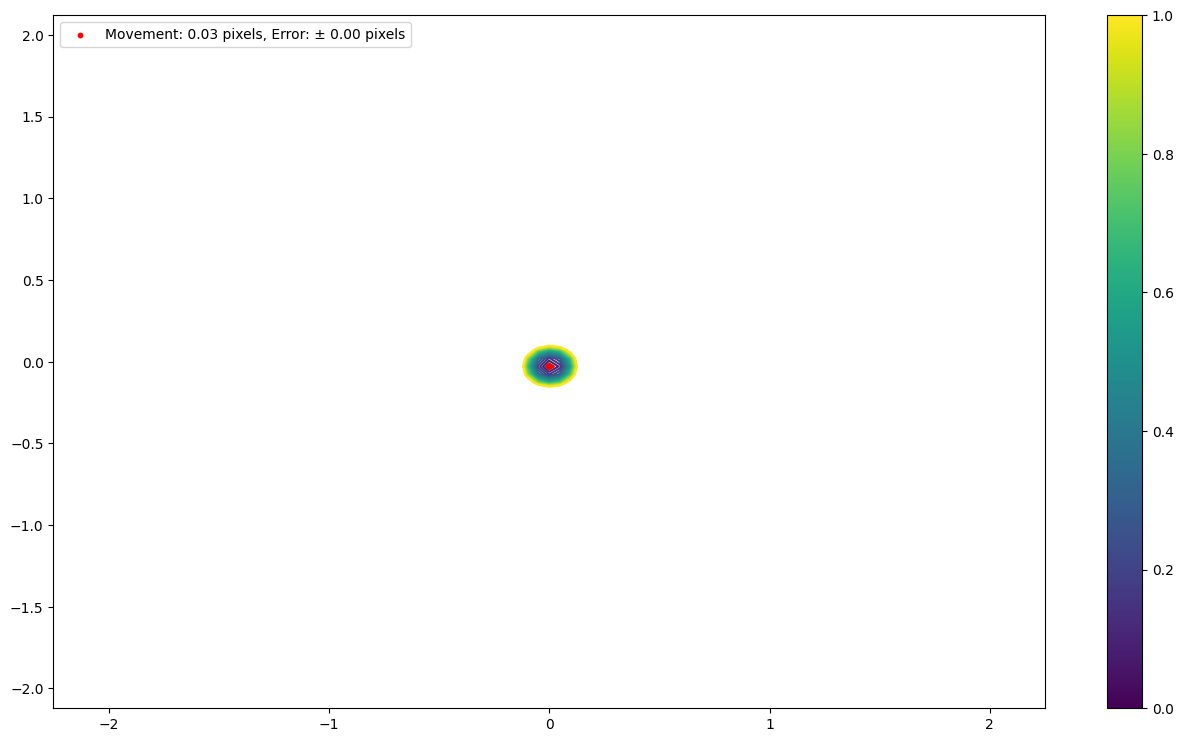

In [65]:
#1
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [185, round(185 - x_offset)+7]
cy_chi = [1910, round(1910 - y_offset)+1]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 3
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

In [66]:
# #2
# plt.rcParams['figure.max_open_warning'] = 200
# #define the x, y position of the knot
# cx_chi = [1321, round(1321 - x_offset) ]
# cy_chi = [1753, round(1753 - y_offset) -5]
# #define the size of the image
# size_chi = [2, 2]
# #how much bigger the median subtraction is from the image size
# median_factor = 2
# #sets how much each chi is offset by. should be kept small to increase how accurate it is 
# shift_amount = .05
# #sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
# width = 40
# height = 40
# direction = 1
# chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

In [67]:
#3
# plt.rcParams['figure.max_open_warning'] = 200
# #define the x, y position of the knot
# cx_chi = [1697, round(1697 - x_offset) - 1]
# cy_chi = [1091, round(1091 - y_offset) +1]
# #define the size of the image
# size_chi = [2, 2]
# #how much bigger the median subtraction is from the image size
# median_factor = 2
# #sets how much each chi is offset by. should be kept small to increase how accurate it is 
# shift_amount = .05
# #sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
# width = 40
# height = 40
# direction = 1
# chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

In [68]:
# #4
# plt.rcParams['figure.max_open_warning'] = 200
# #define the x, y position of the knot
# cx_chi = [1974, round(1974 - x_offset) -1]
# cy_chi = [1055, round(1055 - y_offset) +1]
# #define the size of the image
# size_chi = [2, 2]
# #how much bigger the median subtraction is from the image size
# median_factor = 2
# #sets how much each chi is offset by. should be kept small to increase how accurate it is 
# shift_amount = .05
# #sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
# width = 40
# height = 40
# direction = 1
# chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

In [69]:
# #5
# plt.rcParams['figure.max_open_warning'] = 200
# #define the x, y position of the knot
# cx_chi = [1786, round(1786 - x_offset) -1]
# cy_chi = [967, round(967 - y_offset)]
# #define the size of the image
# size_chi = [2, 2]
# #how much bigger the median subtraction is from the image size
# median_factor = 2
# #sets how much each chi is offset by. should be kept small to increase how accurate it is 
# shift_amount = .05
# #sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
# width = 40
# height = 40
# direction = 1
# chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  4.884372 , X shift =  0.013288030254989258 , Y shift =  0.009170087006219796
Error ± 0.0
x error ± 0.0 y error ± 0.0
angle = -55.39039245504903
angle error ± 0.0


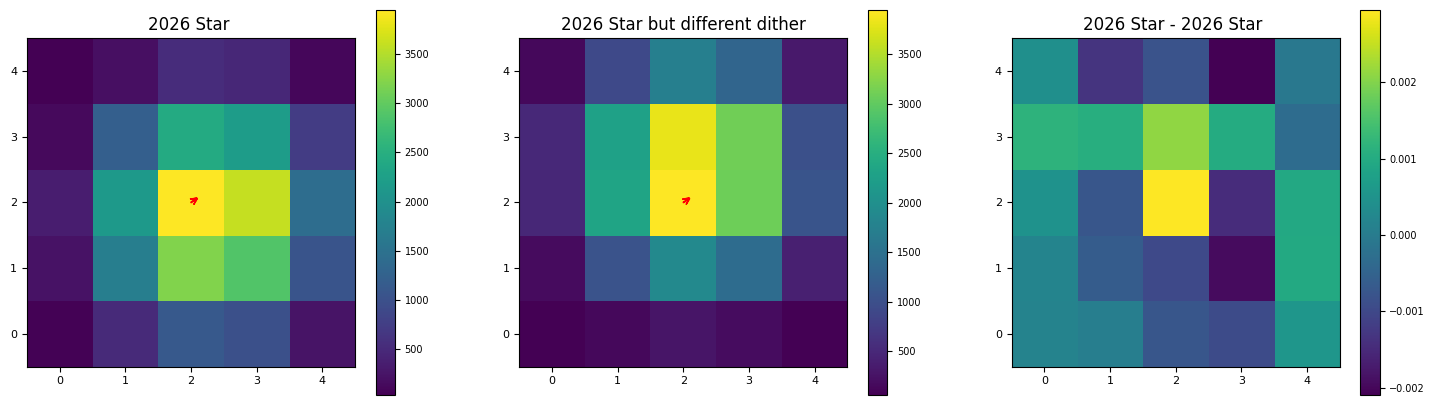

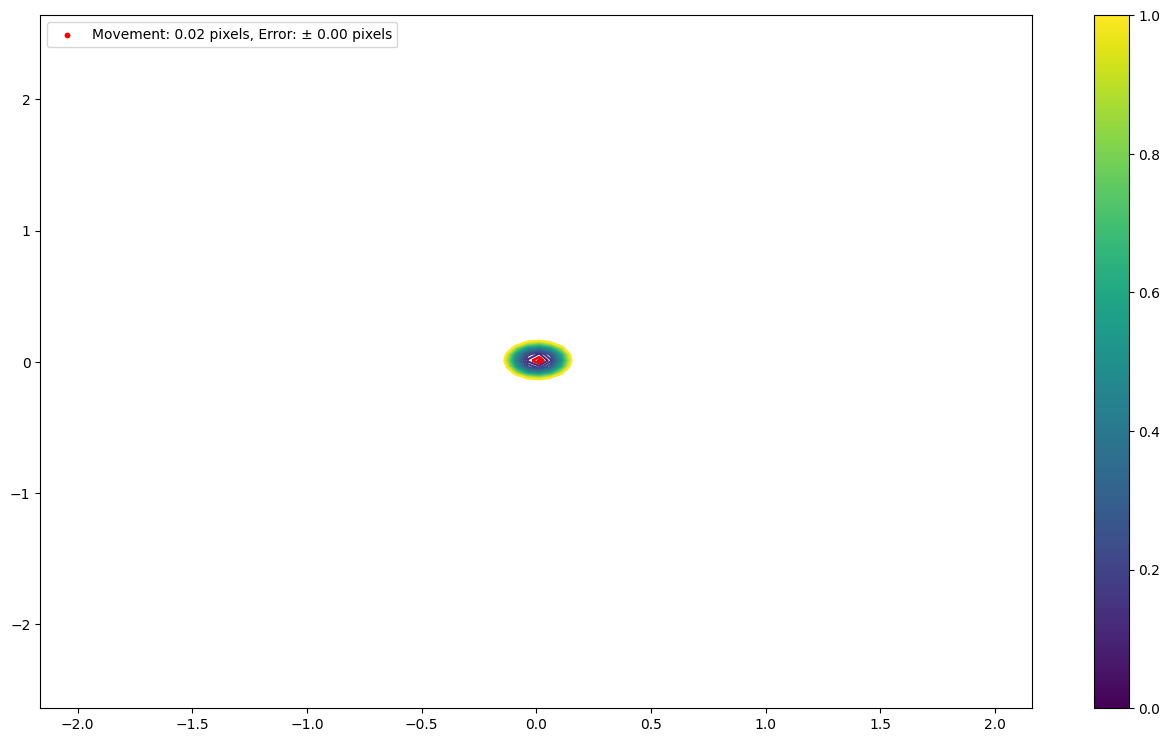

In [70]:
#6
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [682, round(682 - x_offset) -3]
cy_chi = [779, round(779 - y_offset)+1]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  3.5148122 , X shift =  -0.00295821098000032 , Y shift =  0.012570298316364872
Error ± 0.025
x error ± 0.024999999999999994 y error ± 0.025
angle = 13.242652272427385
angle error ± 110.92061145870973


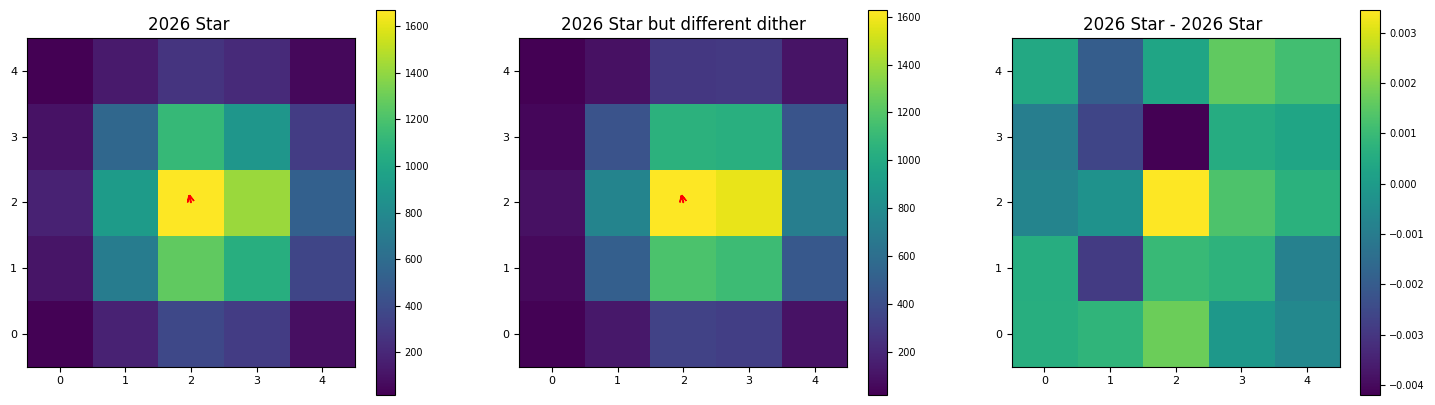

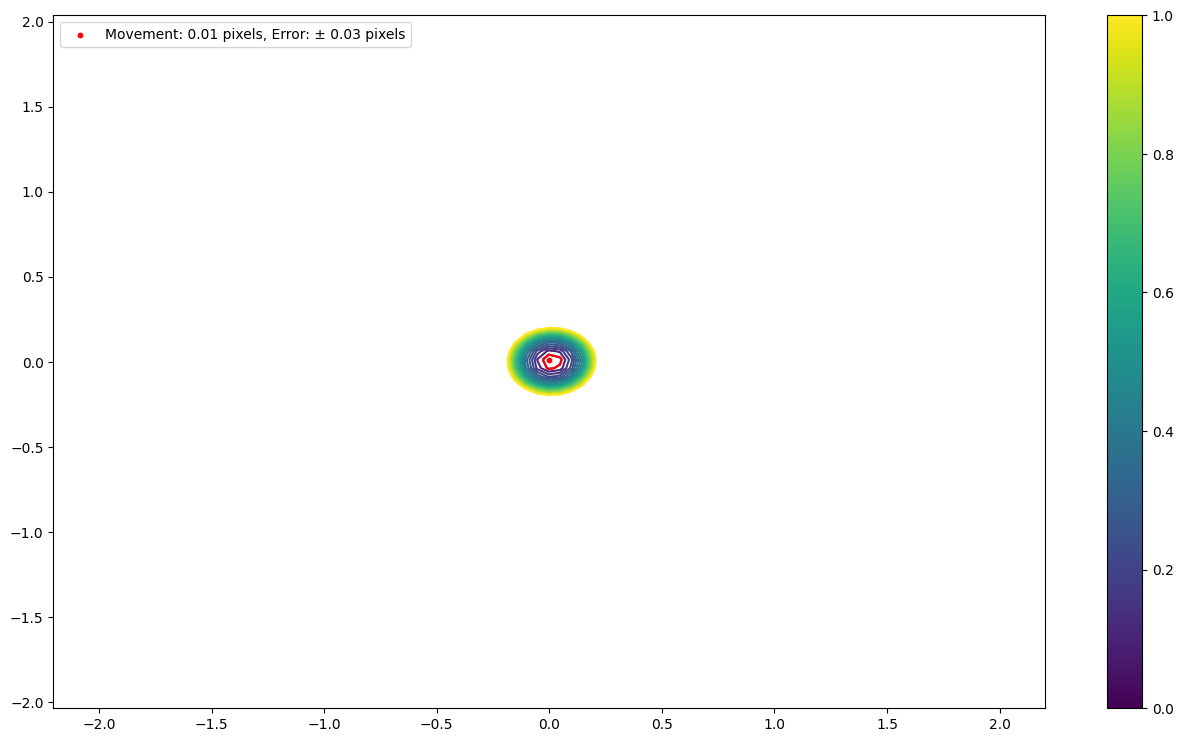

In [71]:
#7
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [1170, round(1170 - x_offset) -6]
cy_chi = [875, round(875 - y_offset)-2]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  12.997461 , X shift =  -0.031211232861244276 , Y shift =  0.004343485721614138
Error ± 0.0034458968120756827
x error ± 0.0 y error ± 0.02500000000000001
angle = 82.07736319561391
angle error ± 45.02163760012438


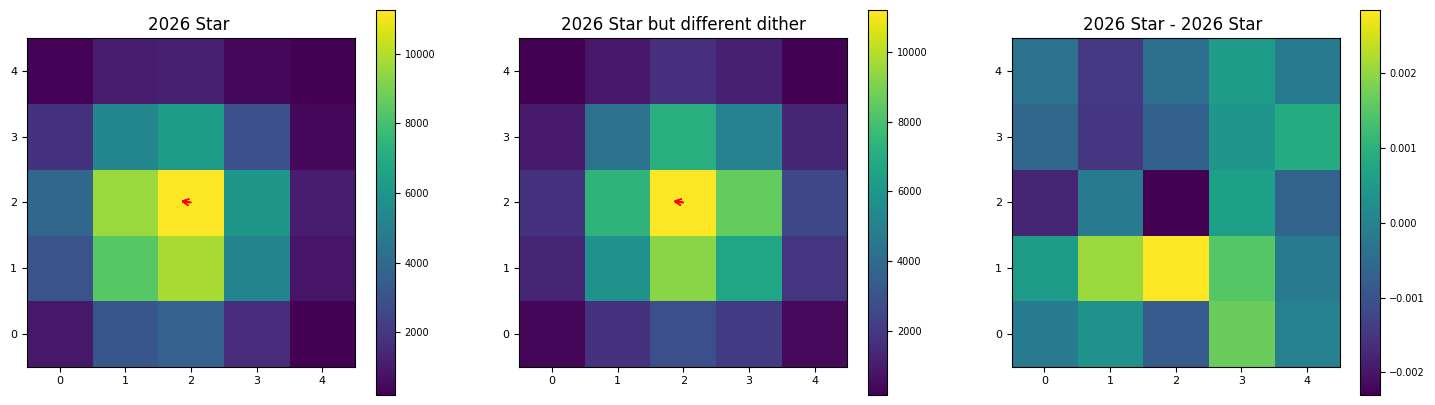

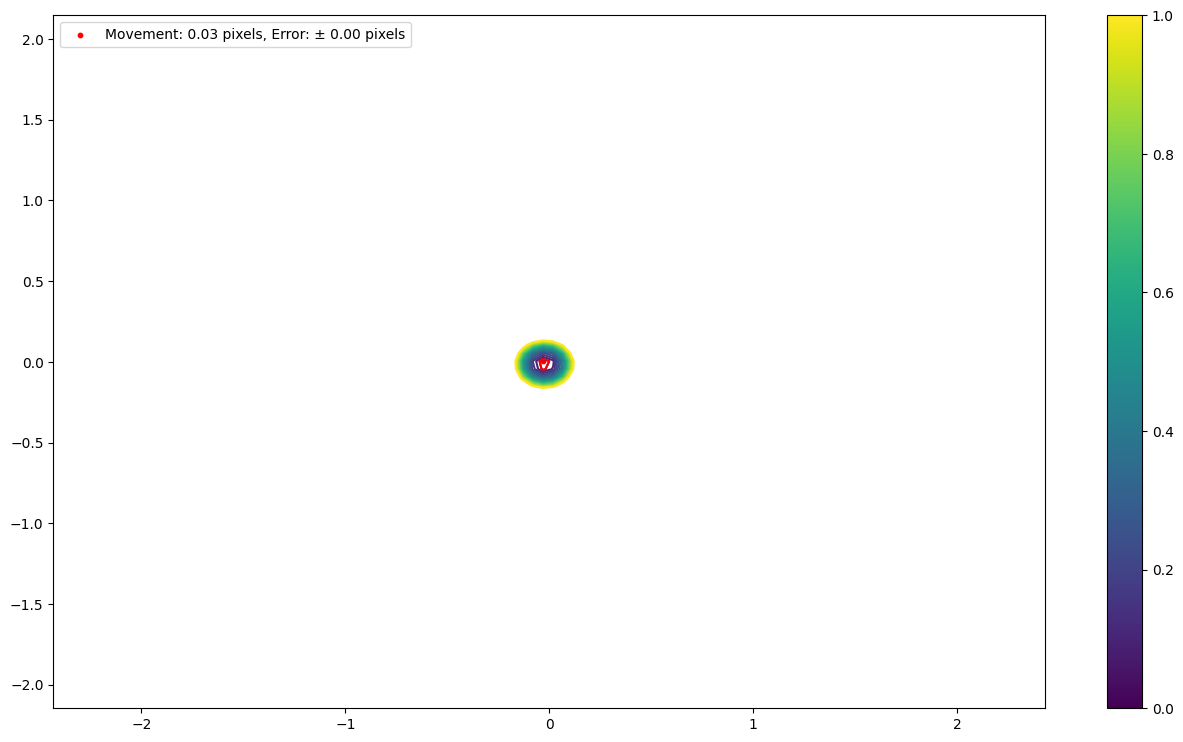

In [72]:
#8
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [51, round(51 - x_offset) -5]
cy_chi = [431, round(431 - y_offset) +7]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  21.603237 , X shift =  -0.04202797079418019 , Y shift =  -0.027377515870233543
Error ± 0.058574715167652204
x error ± 0.05000000000000002 y error ± 0.07500000000000001
angle = 123.08069545412023
angle error ± 78.26173153636392


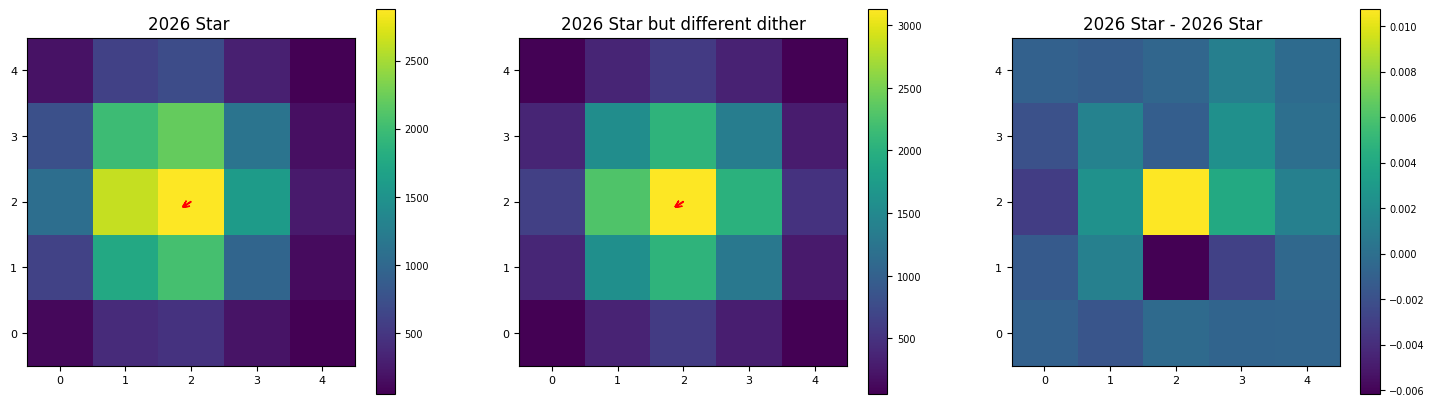

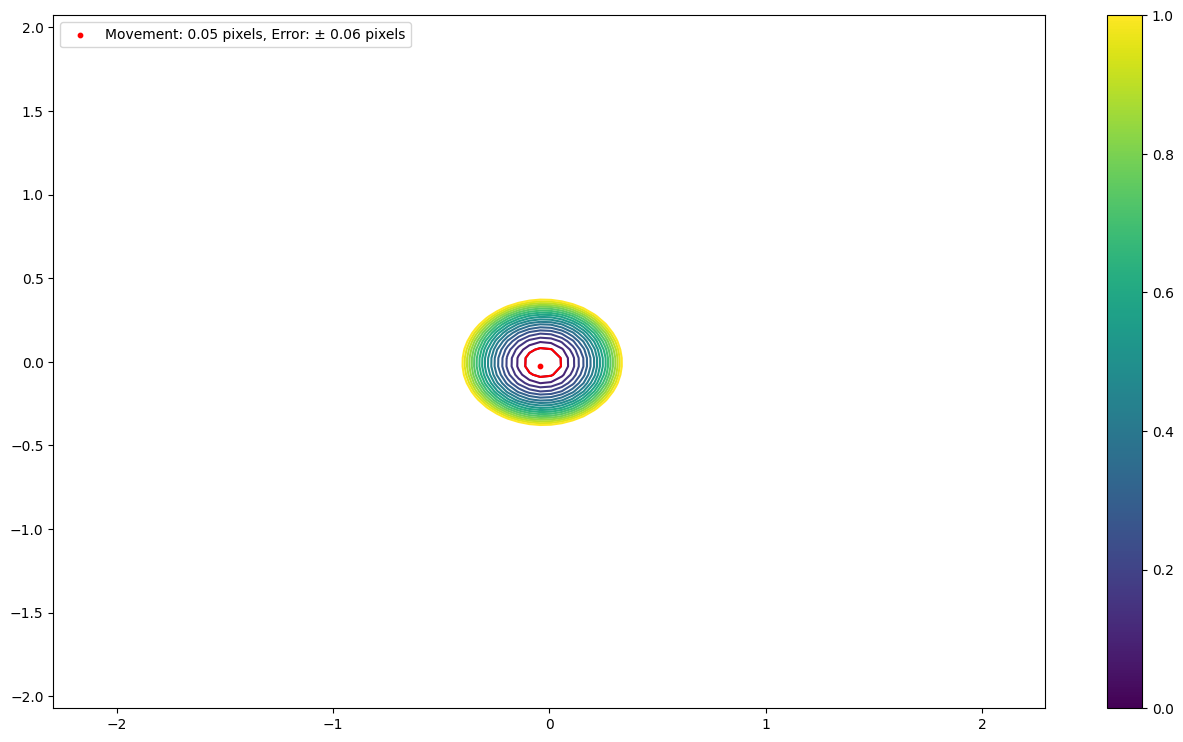

In [73]:
#9
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [98, round(98 - x_offset) -5]
cy_chi = [421, round(421 - y_offset)+7]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  0.44599107 , X shift =  -0.0025157864050014966 , Y shift =  -0.016785260427184312
Error ± 0.05000000000000002
x error ± 0.04999999999999999 y error ± 0.05000000000000002
angle = 171.47592007418794
angle error ± 168.7875825456529


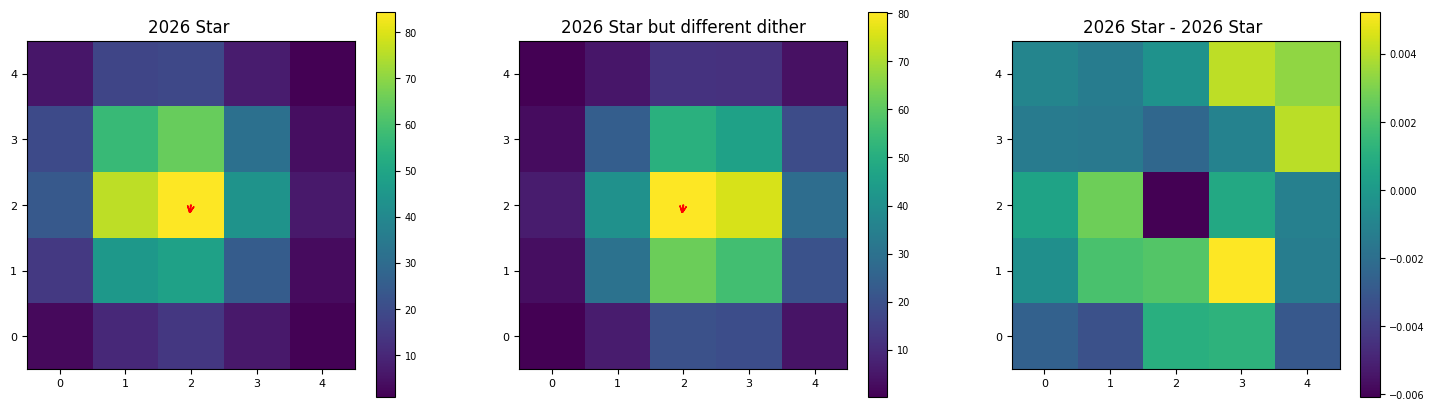

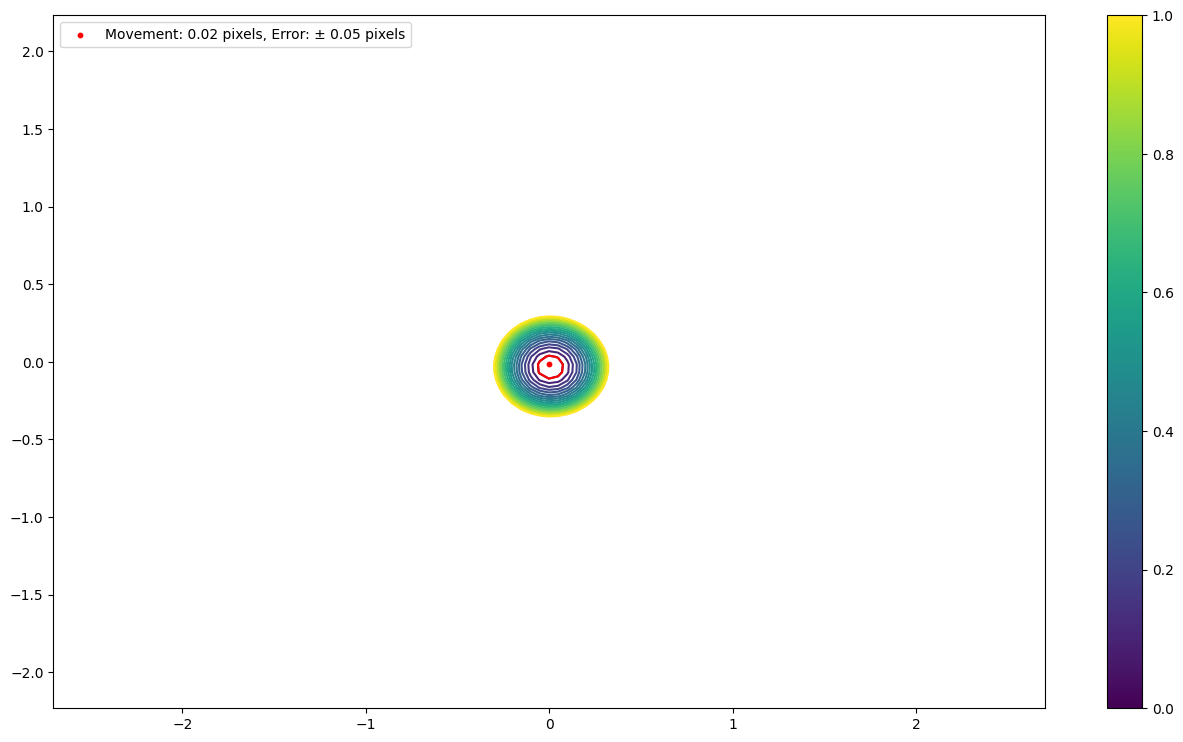

In [74]:
#10
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [324, round(324 - x_offset)-6]
cy_chi = [404, round(404 - y_offset)+6]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

minimum chi squared value =  0.8198052 , X shift =  -0.01553657047307988 , Y shift =  -0.024461607234263744
Error ± 0.07500000000000001
x error ± 0.07500000000000001 y error ± 0.07500000000000001
angle = 147.57869447317975
angle error ± 148.2885203841275


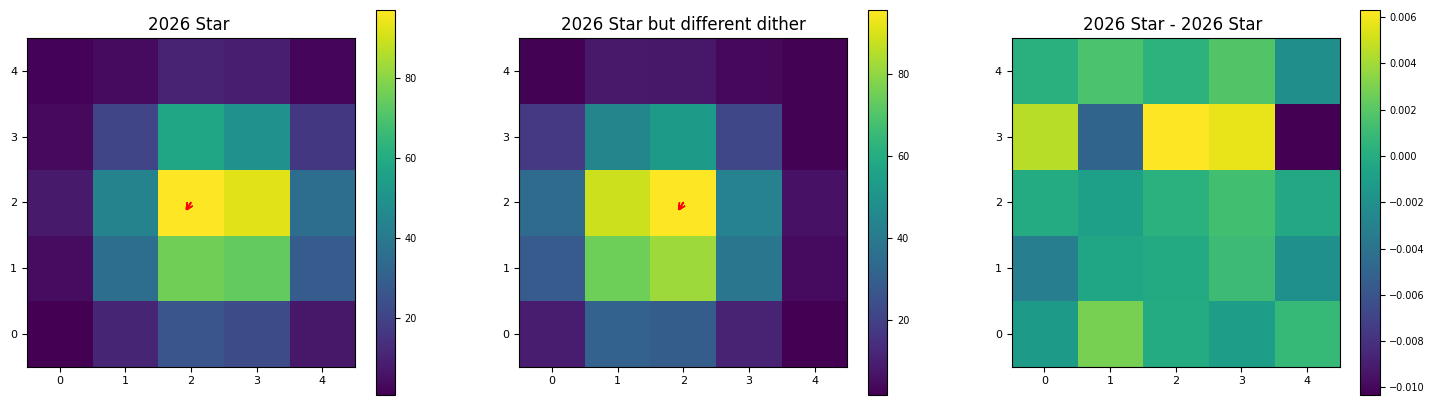

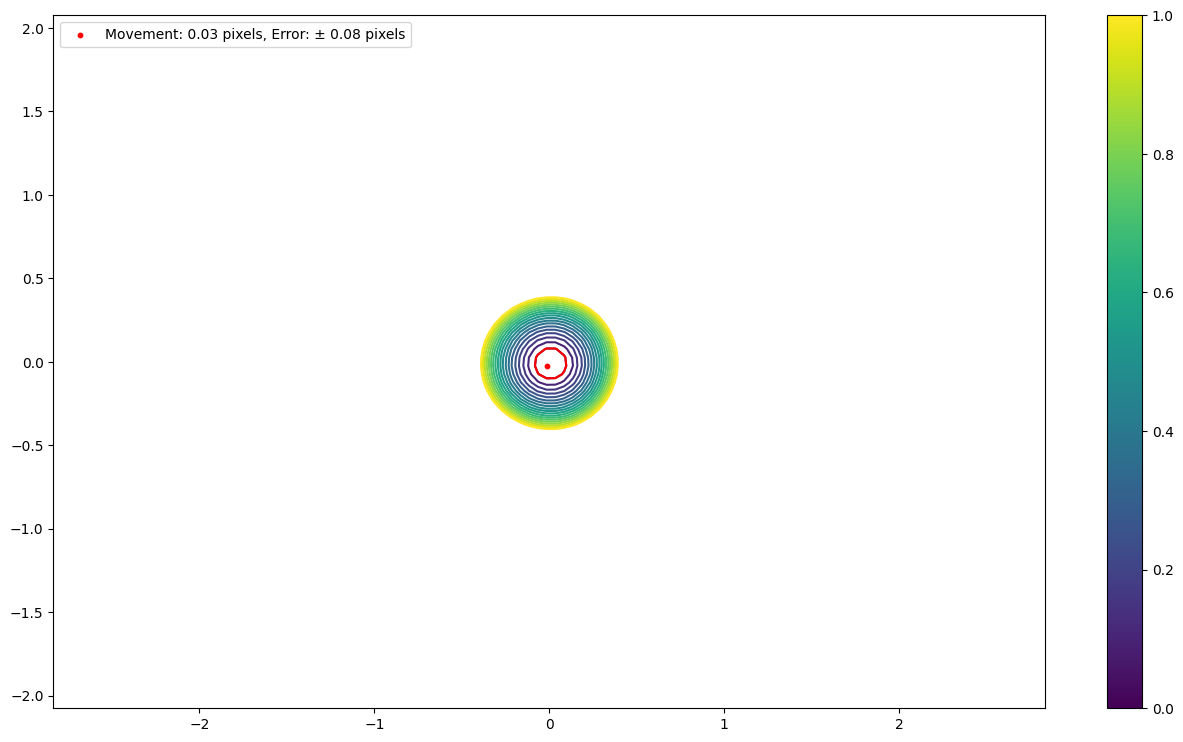

In [75]:
#11
plt.rcParams['figure.max_open_warning'] = 200
#define the x, y position of the knot
cx_chi = [480, round(480 - x_offset) -5]
cy_chi = [405, round(405 - y_offset)+5]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 2
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

In [76]:
#12
# plt.rcParams['figure.max_open_warning'] = 200
# #define the x, y position of the knot
# cx_chi = [2010, round(2010 - x_offset)-2]
# cy_chi = [482, round(482 - y_offset)+3]
# #define the size of the image
# size_chi = [2, 2]
# #how much bigger the median subtraction is from the image size
# median_factor = 2
# #sets how much each chi is offset by. should be kept small to increase how accurate it is 
# shift_amount = .05
# #sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
# width = 40
# height = 40
# direction = 1
# chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

In [77]:
# #13
# plt.rcParams['figure.max_open_warning'] = 200
# #define the x, y position of the knot
# cx_chi = [442, round(442 - x_offset)-9]
# cy_chi = [96, round(96 - y_offset)+4]
# #define the size of the image
# size_chi = [2, 2]
# #how much bigger the median subtraction is from the image size
# median_factor = 2
# #sets how much each chi is offset by. should be kept small to increase how accurate it is 
# shift_amount = .05
# #sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
# width = 40
# height = 40
# direction = 1
# chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

In [78]:
# #14
# plt.rcParams['figure.max_open_warning'] = 200
# #define the x, y position of the knot
# cx_chi = [793, round(793 - x_offset)-9]
# cy_chi = [143, round(143 - y_offset)+2]
# #define the size of the image
# size_chi = [2, 2]
# #how much bigger the median subtraction is from the image size
# median_factor = 2
# #sets how much each chi is offset by. should be kept small to increase how accurate it is 
# shift_amount = .05
# #sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
# width = 40
# height = 40
# direction = 1
# chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, hdu_1_A.data, hdu_2_A.data, hdu_1_A.header, hdu_2_A.header)

In [79]:
velocity_storage_x_dither_1_5 = velocity_storage_x
velocity_storage_y_dither_1_5 = velocity_storage_y
x_error_dither_1_5 = x_error
y_error_dither_1_5 = y_error
error_bar_dither_1_5 = error_bar

# **Data**

<ErrorbarContainer object of 3 artists>

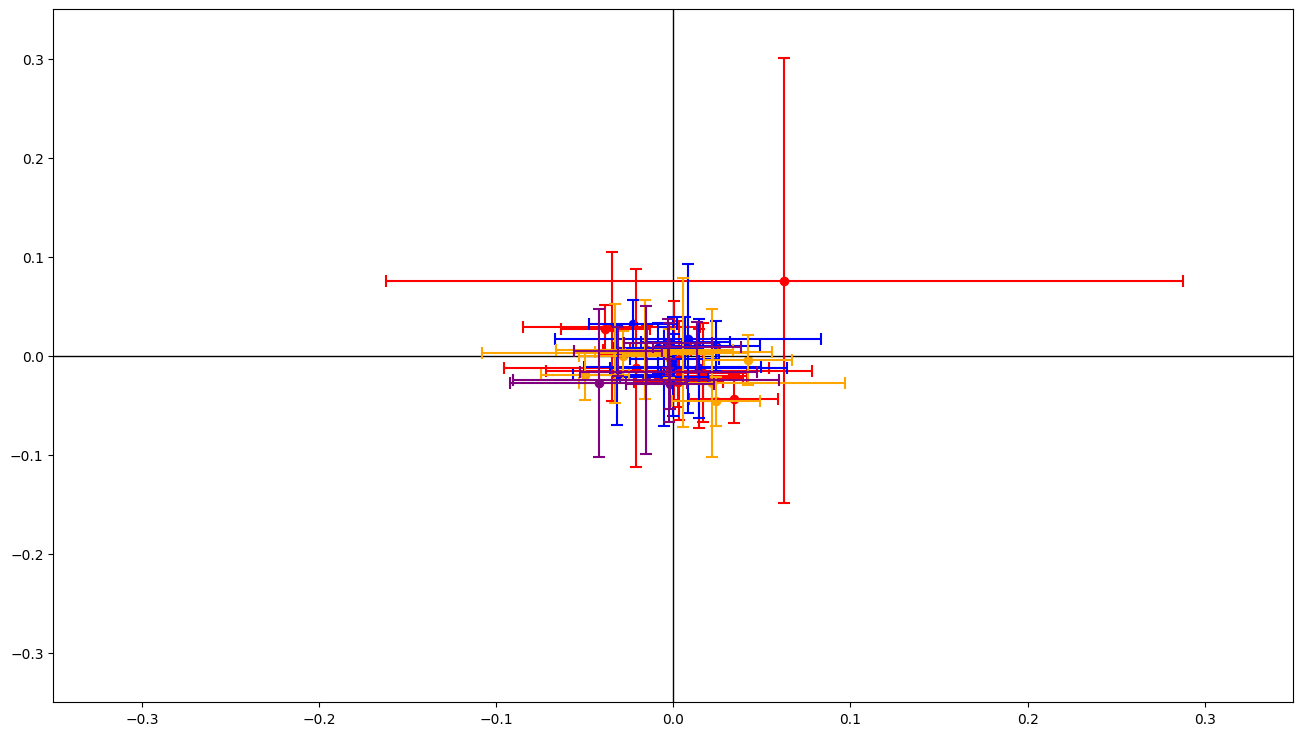

In [80]:
fig, ax = plt.subplots(1, 1, figsize=(16, 9))

ax.axhline(0, color='black', linewidth=1)
ax.axvline(0, color='black', linewidth=1)

ax.set_xlim([-.35, .35])
ax.set_ylim([-.35, .35])

ax.scatter(velocity_storage_x_dither_1_2, velocity_storage_y_dither_1_2, color='red',s=35)
ax.errorbar(velocity_storage_x_dither_1_2, velocity_storage_y_dither_1_2, xerr=x_error_dither_1_2, yerr=y_error_dither_1_2, fmt='none', ecolor='red', elinewidth=1.5, capsize=4, capthick=1.5)

ax.scatter(velocity_storage_x_dither_1_3, velocity_storage_y_dither_1_3, color='blue',s=35)
ax.errorbar(velocity_storage_x_dither_1_3, velocity_storage_y_dither_1_3, xerr=x_error_dither_1_3, yerr=y_error_dither_1_3, fmt='none', ecolor='blue', elinewidth=1.5, capsize=4, capthick=1.5)

ax.scatter(velocity_storage_x_dither_1_4, velocity_storage_y_dither_1_4, color='orange',s=35)
ax.errorbar(velocity_storage_x_dither_1_4, velocity_storage_y_dither_1_4, xerr=x_error_dither_1_4, yerr=y_error_dither_1_4, fmt='none', ecolor='orange', elinewidth=1.5, capsize=4, capthick=1.5)

ax.scatter(velocity_storage_x_dither_1_5, velocity_storage_y_dither_1_5, color='purple',s=35)
ax.errorbar(velocity_storage_x_dither_1_5, velocity_storage_y_dither_1_5, xerr=x_error_dither_1_5, yerr=y_error_dither_1_5, fmt='none', ecolor='purple', elinewidth=1.5, capsize=4, capthick=1.5)

In [89]:
def sigma_clip(x, *arrays, threshold=2):
    x = np.asarray(x, dtype=float)
    arrays = [np.asarray(arr) for arr in arrays]

    mask = np.ones(len(x), dtype=bool)

    while True:
        current = x[mask]
        z_scores = np.abs((current - np.mean(current)) / np.std(current))

        outliers = z_scores > threshold

        if not np.any(outliers):
            break

        mask[np.where(mask)[0][outliers]] = False

    return x[mask], *[arr[mask] for arr in arrays]

In [90]:
clip_velocity_storage_x_dither_1_2, clip_velocity_storage_y_dither_1_2, clip_x_error_dither_1_2, clip_y_error_dither_1_2 = sigma_clip(velocity_storage_x_dither_1_2, velocity_storage_y_dither_1_2, x_error_dither_1_2, y_error_dither_1_2)
clip_velocity_storage_y_dither_1_2, clip_velocity_storage_x_dither_1_2, clip_y_error_dither_1_2, clip_x_error_dither_1_2 = sigma_clip(clip_velocity_storage_y_dither_1_2, clip_velocity_storage_x_dither_1_2, clip_y_error_dither_1_2, clip_x_error_dither_1_2)

clip_velocity_storage_x_dither_1_3, clip_velocity_storage_y_dither_1_3, clip_x_error_dither_1_3, clip_y_error_dither_1_3 = sigma_clip(
    velocity_storage_x_dither_1_3,
    velocity_storage_y_dither_1_3,
    x_error_dither_1_3,
    y_error_dither_1_3
)
clip_velocity_storage_y_dither_1_3, clip_velocity_storage_x_dither_1_3, clip_y_error_dither_1_3, clip_x_error_dither_1_3 = sigma_clip(
    clip_velocity_storage_y_dither_1_3,
    clip_velocity_storage_x_dither_1_3,
    clip_y_error_dither_1_3,
    clip_x_error_dither_1_3
)

clip_velocity_storage_x_dither_1_4, clip_velocity_storage_y_dither_1_4, clip_x_error_dither_1_4, clip_y_error_dither_1_4 = sigma_clip(
    velocity_storage_x_dither_1_4,
    velocity_storage_y_dither_1_4,
    x_error_dither_1_4,
    y_error_dither_1_4
)
clip_velocity_storage_y_dither_1_4, clip_velocity_storage_x_dither_1_4, clip_y_error_dither_1_4, clip_x_error_dither_1_4 = sigma_clip(
    clip_velocity_storage_y_dither_1_4,
    clip_velocity_storage_x_dither_1_4,
    clip_y_error_dither_1_4,
    clip_x_error_dither_1_4
)

clip_velocity_storage_x_dither_1_5, clip_velocity_storage_y_dither_1_5, clip_x_error_dither_1_5, clip_y_error_dither_1_5 = sigma_clip(
    velocity_storage_x_dither_1_5,
    velocity_storage_y_dither_1_5,
    x_error_dither_1_5,
    y_error_dither_1_5
)
clip_velocity_storage_y_dither_1_5, clip_velocity_storage_x_dither_1_5, clip_y_error_dither_1_5, clip_x_error_dither_1_5 = sigma_clip(
    clip_velocity_storage_y_dither_1_5,
    clip_velocity_storage_x_dither_1_5,
    clip_y_error_dither_1_5,
    clip_x_error_dither_1_5
)

<ErrorbarContainer object of 3 artists>

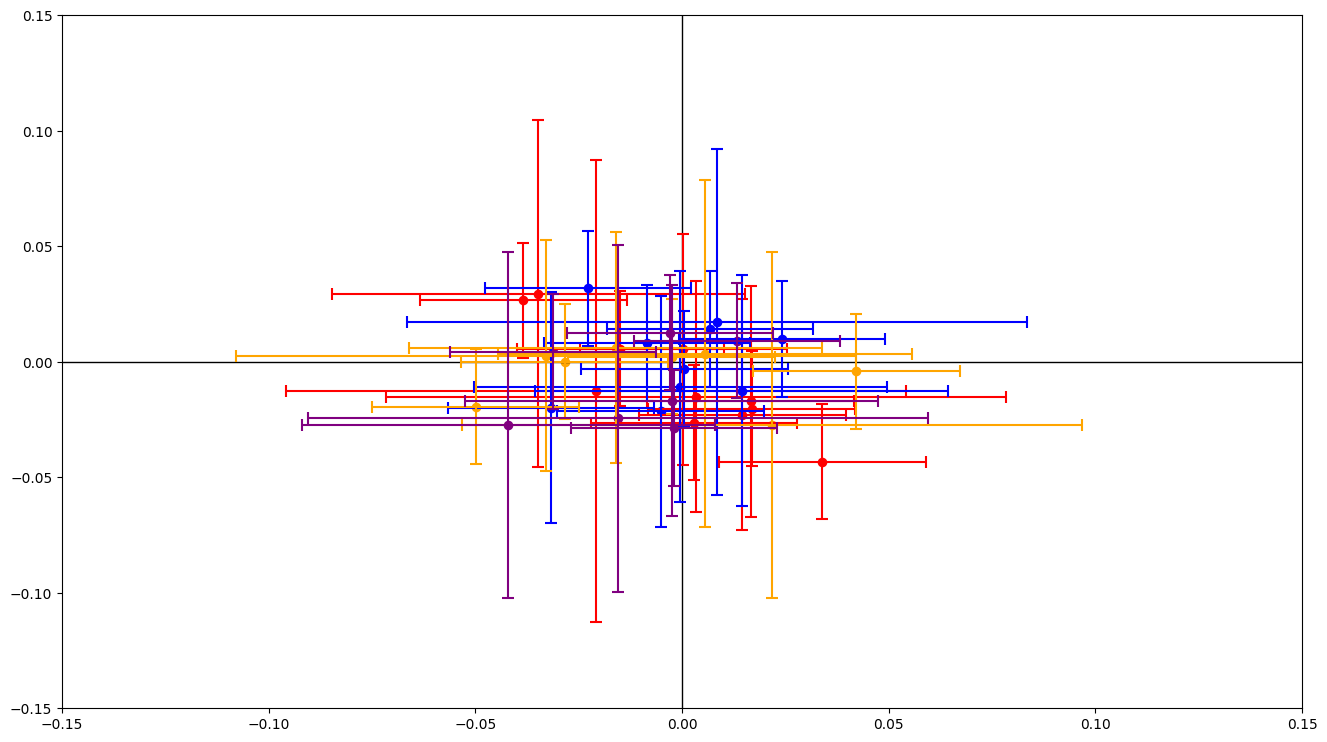

In [91]:
fig, ax = plt.subplots(1, 1, figsize=(16, 9))


ax.axhline(0, color='black', linewidth=1)
ax.axvline(0, color='black', linewidth=1)


ax.set_xlim([-.15, .15])
ax.set_ylim([-.15, .15])


ax.scatter(clip_velocity_storage_x_dither_1_2, clip_velocity_storage_y_dither_1_2, color='red',s=35)
ax.errorbar(clip_velocity_storage_x_dither_1_2, clip_velocity_storage_y_dither_1_2, xerr=clip_x_error_dither_1_2, yerr=clip_y_error_dither_1_2, fmt='none', ecolor='red', elinewidth=1.5, capsize=4, capthick=1.5)


ax.scatter(clip_velocity_storage_x_dither_1_3, clip_velocity_storage_y_dither_1_3, color='blue',s=35)
ax.errorbar(clip_velocity_storage_x_dither_1_3, clip_velocity_storage_y_dither_1_3, xerr=clip_x_error_dither_1_3, yerr=clip_y_error_dither_1_3, fmt='none', ecolor='blue', elinewidth=1.5, capsize=4, capthick=1.5)


ax.scatter(clip_velocity_storage_x_dither_1_4, clip_velocity_storage_y_dither_1_4, color='orange',s=35)
ax.errorbar(clip_velocity_storage_x_dither_1_4, clip_velocity_storage_y_dither_1_4, xerr=clip_x_error_dither_1_4, yerr=clip_y_error_dither_1_4, fmt='none', ecolor='orange', elinewidth=1.5, capsize=4, capthick=1.5)


ax.scatter(clip_velocity_storage_x_dither_1_5, clip_velocity_storage_y_dither_1_5, color='purple',s=35)
ax.errorbar(clip_velocity_storage_x_dither_1_5, clip_velocity_storage_y_dither_1_5, xerr=clip_x_error_dither_1_5, yerr=clip_y_error_dither_1_5, fmt='none', ecolor='purple', elinewidth=1.5, capsize=4, capthick=1.5)

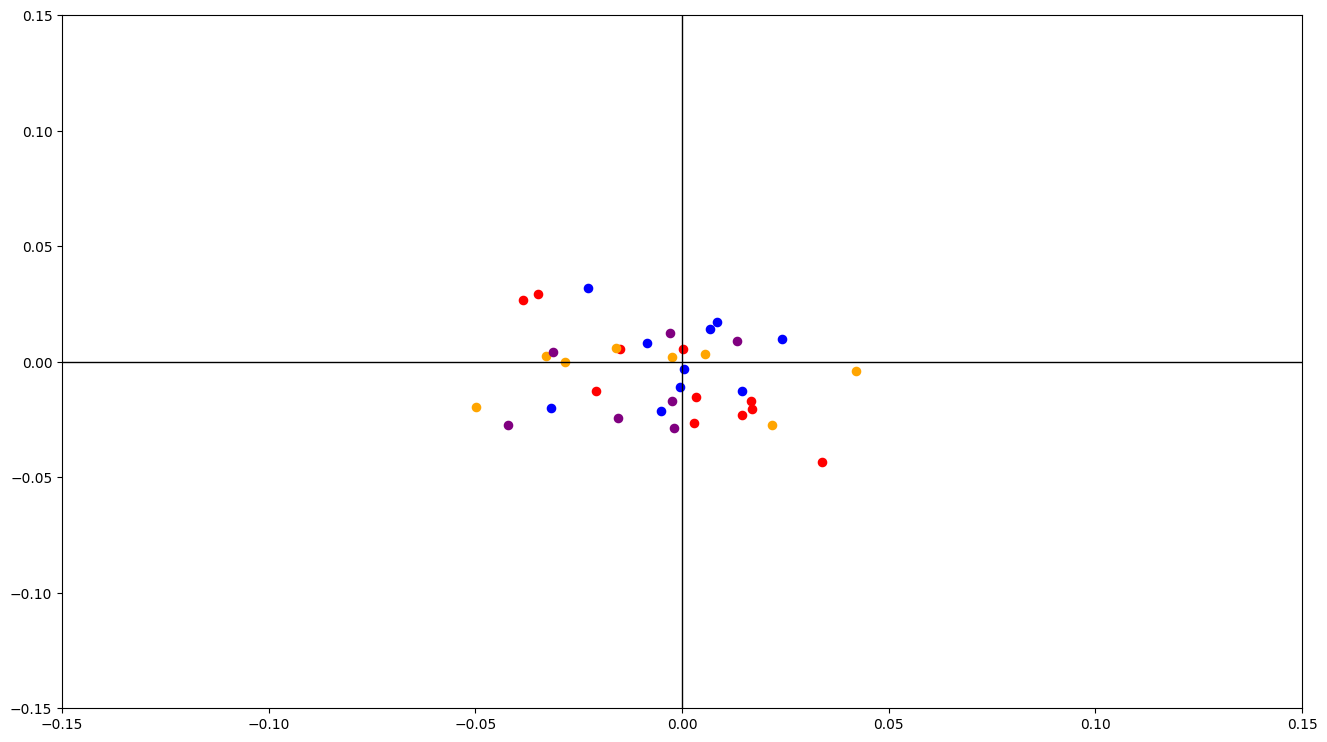

In [93]:
fig, ax = plt.subplots(1, 1, figsize=(16, 9))

ax.axhline(0, color='black', linewidth=1)
ax.axvline(0, color='black', linewidth=1)

ax.set_xlim([-.15, .15])
ax.set_ylim([-.15, .15])

ax.scatter(clip_velocity_storage_x_dither_1_2, clip_velocity_storage_y_dither_1_2, color='red',s=35)

ax.scatter(clip_velocity_storage_x_dither_1_3, clip_velocity_storage_y_dither_1_3, color='blue',s=35)

ax.scatter(clip_velocity_storage_x_dither_1_4, clip_velocity_storage_y_dither_1_4, color='orange',s=35)

ax.scatter(clip_velocity_storage_x_dither_1_5, clip_velocity_storage_y_dither_1_5, color='purple',s=35)

In [95]:
all_x = np.concatenate((clip_velocity_storage_x_dither_1_2, clip_velocity_storage_x_dither_1_3, clip_velocity_storage_x_dither_1_4, clip_velocity_storage_x_dither_1_5)) 
all_y = np.concatenate((clip_velocity_storage_y_dither_1_2, clip_velocity_storage_y_dither_1_3, clip_velocity_storage_y_dither_1_4, clip_velocity_storage_y_dither_1_5))

In [103]:
std_x = np.std(all_x)
std_y = np.std(all_y)

mean_x = np.mean(all_x)
mean_y = np.mean(all_y)

std_of_mean_x = np.std(all_x)/ np.sqrt(len(all_x))
std_of_mean_y = np.std(all_y)/ np.sqrt(len(all_y))



print (f"Standard Deviation = ({std_x:.4f},{std_y:.4f}) (pixels)")
print ()
print (f"Standard Deviation of the Mean = ({std_of_mean_x:.4f},{std_of_mean_y:.4f}) (pixels)")
print ()
print (f"Mean = ({mean_x:.4f},{mean_y:.4f}) (pixels)")


Standard Deviation = (0.0218,0.0179) (pixels)

Standard Deviation of the Mean = (0.0036,0.0030) (pixels)

Mean = (-0.0049,-0.0051) (pixels)
